# WiDS Datathon 2025

The goal is to build a model to predict both an individual’s sex and their ADHD diagnosis using functional brain imaging data of children and adolescents and their socio-demographic, emotions, and parenting information. https://www.kaggle.com/competitions/widsdatathon2025/overview

**Dataset Folders**\
(1) the training folder train_new_tsv consists of three types of information about the 1,200+ subjects. They are:

a) the targets (ADHD diagnosis and sex)\
b) functional MRI connectome matrices\
c) socio-demographic information, e.g., subject’s “handedness” or “parent’s education level”, emotions (“Strength and Difficulties Questionnaire”), and parenting information (“Alabama Parenting Questionnaire”). These include both quantitative and categorical metadata.

**Friendly hint**: Participants will need to process the categorical data (perhaps create dummy variables) and then combine this processed dataset with the functional connectome dataset to create a final training dataset to use in their models.

(2) the test folder test_tsv consists of unseen data frames for 300+ subjects. These data frames are as follows:

a) functional MRI connectome matrices\
b) socio-demographic, emotions, and parenting information

**Target Variables**\
ADHD_Outcome: Type of Diagnosis (0=Other/None, 1=ADHD)\
Sex_F: Sex of participant (0=Male, 1=Female)

##### imports

In [140]:
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn.preprocessing as prep
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots 

import sklearn
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, accuracy_score

##### Helper Functions

In [142]:
def get_messing(df,drop=False):
    missing_data = pd.DataFrame({'Count': df.isnull().sum(),
                            '%':(df.isnull().sum()/df.shape[0]*100 ).round(2)
                            })
    if (missing_data[missing_data != 0].dropna().sum().sum() == 0) :
        print("No Messing Data")
    else : 
        if drop :
            return(missing_data[missing_data != 0].dropna())
        else: return(missing_data)

In [143]:
def handel_Outliers(df,Outlier_columns,handel = True):
    for col in Outlier_columns:
        print(col," : \n")
        # first get the IQR value then apply the rule
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        print(f"IQR = {IQR}")
        # Anything above the upper limit or lower than the lower limit is an outlier
        cut_off = IQR * 1.5
        lower = Q1 - cut_off
        upper =  Q3 + cut_off
        print(f"lower,upper bounds [{lower},{upper}]")
        
        u = df[df[col]> upper]
        l = df[df[col] < lower]
        print(F'Total number of outliers in {col} are {u.shape[0]+ l.shape[0]}')
        if handel:
            df.loc[df[col] < lower, col] = df[col].median()
            df.loc[df[col] > upper, col] = df[col].median()
        print("===========================================")   
    if handel:
        print("All ouliers Handeled successfully")

    return df

In [144]:
def multi_output_accuracy(y_true, y_pred):
    # Ensure y_true and y_pred are NumPy arrays
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    # Compute accuracy for each target variable and return the mean
    return np.mean([accuracy_score(y_true[:, i], y_pred[:, i]) for i in range(y_true.shape[1])])

# Create a scorer using scikit-learn's make_scorer
multi_output_scorer = make_scorer(multi_output_accuracy, greater_is_better=True)

# Load Data

In [146]:
# Train data
TRAIN_CATEGORICAL = pd.read_excel("TRAIN_NEW/TRAIN_CATEGORICAL_METADATA_new.xlsx")
TRAIN_FUNCTIONAL_CONNECTOME_MATRICES = pd.read_csv("TRAIN_NEW/TRAIN_FUNCTIONAL_CONNECTOME_MATRICES_new_36P_Pearson.csv")
TRAIN_QUANTITATIVE = pd.read_excel("TRAIN_NEW/TRAIN_QUANTITATIVE_METADATA_new.xlsx")
TRAINING_SOLUTIONS = pd.read_excel("TRAIN_NEW/TRAINING_SOLUTIONS.xlsx")

In [147]:
# Test data
TEST_CATEGORICAL = pd.read_excel("TEST/TEST_CATEGORICAL.xlsx")
TEST_FUNCTIONAL_CONNECTOME_MATRICES = pd.read_csv("TEST/TEST_FUNCTIONAL_CONNECTOME_MATRICES.csv")
TEST_QUANTITATIVE_METADATA = pd.read_excel("TEST/TEST_QUANTITATIVE_METADATA.xlsx")

# EDA

In [149]:
id1 = TRAIN_CATEGORICAL.participant_id.sort_values().reset_index(drop=True)
id2 = TRAIN_FUNCTIONAL_CONNECTOME_MATRICES.participant_id.sort_values().reset_index(drop=True)
id3 = TRAIN_QUANTITATIVE.participant_id.sort_values().reset_index(drop=True)

(id1.equals(id2)) and (id1.equals(id3))


True

All ids refer to the same persons

In [151]:
TRAIN_CATEGORICAL = TRAIN_CATEGORICAL.sort_values('participant_id').reset_index(drop=True)
TRAIN_FUNCTIONAL_CONNECTOME_MATRICES = TRAIN_FUNCTIONAL_CONNECTOME_MATRICES.sort_values('participant_id').reset_index(drop=True)
TRAIN_QUANTITATIVE = TRAIN_QUANTITATIVE.sort_values('participant_id').reset_index(drop=True)
TRAINING_SOLUTIONS = TRAINING_SOLUTIONS.sort_values('participant_id').reset_index(drop=True)

## TRAINING_SOLUTIONS

In [153]:
TRAINING_SOLUTIONS.head()

,participant_id,ADHD_Outcome,Sex_F
0,00aIpNTbG5uh,1,0
1,00fV0OyyoLfw,1,0
2,04X1eiS79T4B,0,1
3,05ocQutkURd6,0,1
4,06YUNBA9ZRLq,1,0


In [154]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px

# Create the subplot figure
fig = make_subplots(
    rows=1, cols=2,
    column_widths=[0.5, 0.5],
    specs=[[{"type": "domain"}, {"type": "domain"}]],
    subplot_titles=["Distribution of ADHD_Outcome", "Sex Distribution"]
)

df = TRAINING_SOLUTIONS.select_dtypes(include=['float64', 'int64'])

# Pie chart for ADHD_Outcome (1 = Has, 0 = No ADHD)
counts = df['ADHD_Outcome'].value_counts()
labels = ['Has ADHD' if val == 1 else 'No ADHD' for val in counts.index]
percentages = counts / counts.sum() * 100
label_with_pct = [f'{label} ({pct:.1f}%)' for label, pct in zip(labels, percentages)]

fig.add_trace(
    go.Pie(
        labels=label_with_pct,
        values=counts.values,
    ),
    row=1, col=1
)

# Pie chart for Sex_F (1 = Female, 0 = Male)
counts = df['Sex_F'].value_counts()
labels = ['Female' if val == 1 else 'Male' for val in counts.index]
percentages = counts / counts.sum() * 100
label_with_pct = [f'{label} ({pct:.1f}%)' for label, pct in zip(labels, percentages)]

fig.add_trace(
    go.Pie(
        labels=label_with_pct,
        values=counts.values,
    ),
    row=1, col=2
)

# Update layout
fig.update_layout(
    title_text="ADHD Outcome Distribution and Sex Breakdown",
    height=400
)

fig.show()

## TRAIN_CATEGORICAL

In [156]:
TRAIN_CATEGORICAL.head()

,participant_id,Basic_Demos_Enroll_Year,Basic_Demos_Study_Site,PreInt_Demos_Fam_Child_Ethnicity,PreInt_Demos_Fam_Child_Race,MRI_Track_Scan_Location,Barratt_Barratt_P1_Edu,Barratt_Barratt_P1_Occ,Barratt_Barratt_P2_Edu,Barratt_Barratt_P2_Occ
0,00aIpNTbG5uh,2019,4,1.0,0.0,3.0,21.0,45.0,NaN,NaN
1,00fV0OyyoLfw,2017,1,0.0,9.0,2.0,21.0,0.0,21.0,45.0
2,04X1eiS79T4B,2017,1,1.0,2.0,2.0,9.0,0.0,NaN,NaN
3,05ocQutkURd6,2018,1,3.0,8.0,2.0,18.0,10.0,18.0,0.0
4,06YUNBA9ZRLq,2018,1,0.0,1.0,2.0,12.0,0.0,NaN,NaN


In [157]:
TRAIN_CATEGORICAL.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1213 entries, 0 to 1212
Data columns (total 10 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   participant_id                    1213 non-null   object 
 1   Basic_Demos_Enroll_Year           1213 non-null   int64  
 2   Basic_Demos_Study_Site            1213 non-null   int64  
 3   PreInt_Demos_Fam_Child_Ethnicity  1170 non-null   float64
 4   PreInt_Demos_Fam_Child_Race       1159 non-null   float64
 5   MRI_Track_Scan_Location           1210 non-null   float64
 6   Barratt_Barratt_P1_Edu            1198 non-null   float64
 7   Barratt_Barratt_P1_Occ            1182 non-null   float64
 8   Barratt_Barratt_P2_Edu            1015 non-null   float64
 9   Barratt_Barratt_P2_Occ            991 non-null    float64
dtypes: float64(7), int64(2), object(1)
memory usage: 94.9+ KB


In [158]:
TRAIN_CATEGORICAL.describe()

,Basic_Demos_Enroll_Year,Basic_Demos_Study_Site,PreInt_Demos_Fam_Child_Ethnicity,PreInt_Demos_Fam_Child_Race,MRI_Track_Scan_Location,Barratt_Barratt_P1_Edu,Barratt_Barratt_P1_Occ,Barratt_Barratt_P2_Edu,Barratt_Barratt_P2_Occ
count,1213.000000,1213.000000,1170.000000,1159.000000,1210.000000,1198.000000,1182.000000,1015.000000,991.000000
mean,2017.652102,2.014839,0.435897,2.177739,2.294215,17.862270,25.545685,16.876847,30.257316
std,1.122522,1.135147,0.693174,3.204782,0.750660,3.505608,16.757043,3.929558,13.901144
min,2015.000000,1.000000,0.000000,0.000000,1.000000,3.000000,0.000000,3.000000,0.000000
25%,2017.000000,1.000000,0.000000,0.000000,2.000000,15.000000,5.000000,15.000000,20.000000
50%,2018.000000,1.000000,0.000000,1.000000,2.000000,18.000000,30.000000,18.000000,35.000000
75%,2019.000000,3.000000,1.000000,2.000000,3.000000,21.000000,40.000000,21.000000,40.000000
max,2020.000000,4.000000,3.000000,11.000000,4.000000,21.000000,45.000000,21.000000,45.000000


In [159]:
for col in TRAIN_CATEGORICAL.columns:
    print(f"{col}: {TRAIN_CATEGORICAL[col].unique()}")

participant_id: ['00aIpNTbG5uh' '00fV0OyyoLfw' '04X1eiS79T4B' ... 'zwBG0rZ05Mcb'
 'zwXD5v17Rx01' 'zwjJWCRzKhDz']
Basic_Demos_Enroll_Year: [2019 2017 2018 2016 2015 2020]
Basic_Demos_Study_Site: [4 1 2 3]
PreInt_Demos_Fam_Child_Ethnicity: [ 1.  0.  3.  2. nan]
PreInt_Demos_Fam_Child_Race: [ 0.  9.  2.  8.  1. 10.  4. nan  3. 11.  7.]
MRI_Track_Scan_Location: [ 3.  2.  1.  4. nan]
Barratt_Barratt_P1_Edu: [21.  9. 18. 12. 15.  3. nan  6.]
Barratt_Barratt_P1_Occ: [45.  0. 10. 35. 40. 25. nan 30. 15.  5. 20.]
Barratt_Barratt_P2_Edu: [nan 21. 18. 15. 12.  9.  6.  3.]
Barratt_Barratt_P2_Occ: [nan 45.  0. 30. 40. 15. 35.  5. 10. 20. 25.]


In [160]:
get_messing(TRAIN_CATEGORICAL)

,Count,%
participant_id,0,0.00
Basic_Demos_Enroll_Year,0,0.00
Basic_Demos_Study_Site,0,0.00
PreInt_Demos_Fam_Child_Ethnicity,43,3.54
PreInt_Demos_Fam_Child_Race,54,4.45
MRI_Track_Scan_Location,3,0.25
Barratt_Barratt_P1_Edu,15,1.24
Barratt_Barratt_P1_Occ,31,2.56
Barratt_Barratt_P2_Edu,198,16.32
Barratt_Barratt_P2_Occ,222,18.30


In [161]:
merged_df = pd.merge(TRAIN_CATEGORICAL, TRAINING_SOLUTIONS, on='participant_id', how='inner')
merged_df.head()

,participant_id,Basic_Demos_Enroll_Year,Basic_Demos_Study_Site,PreInt_Demos_Fam_Child_Ethnicity,PreInt_Demos_Fam_Child_Race,MRI_Track_Scan_Location,Barratt_Barratt_P1_Edu,Barratt_Barratt_P1_Occ,Barratt_Barratt_P2_Edu,Barratt_Barratt_P2_Occ,ADHD_Outcome,Sex_F
0,00aIpNTbG5uh,2019,4,1.0,0.0,3.0,21.0,45.0,NaN,NaN,1,0
1,00fV0OyyoLfw,2017,1,0.0,9.0,2.0,21.0,0.0,21.0,45.0,1,0
2,04X1eiS79T4B,2017,1,1.0,2.0,2.0,9.0,0.0,NaN,NaN,0,1
3,05ocQutkURd6,2018,1,3.0,8.0,2.0,18.0,10.0,18.0,0.0,0,1
4,06YUNBA9ZRLq,2018,1,0.0,1.0,2.0,12.0,0.0,NaN,NaN,1,0


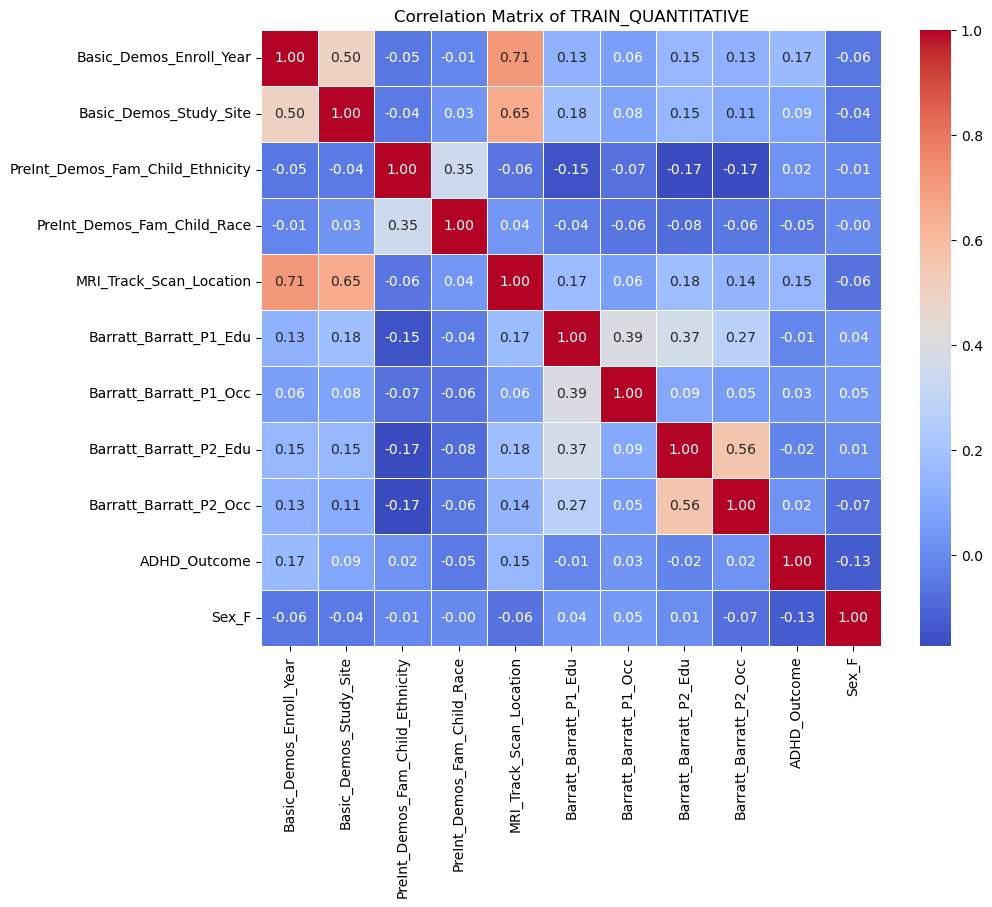

In [162]:
corr=merged_df.drop(['participant_id'],axis=1).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of TRAIN_QUANTITATIVE")
plt.show()

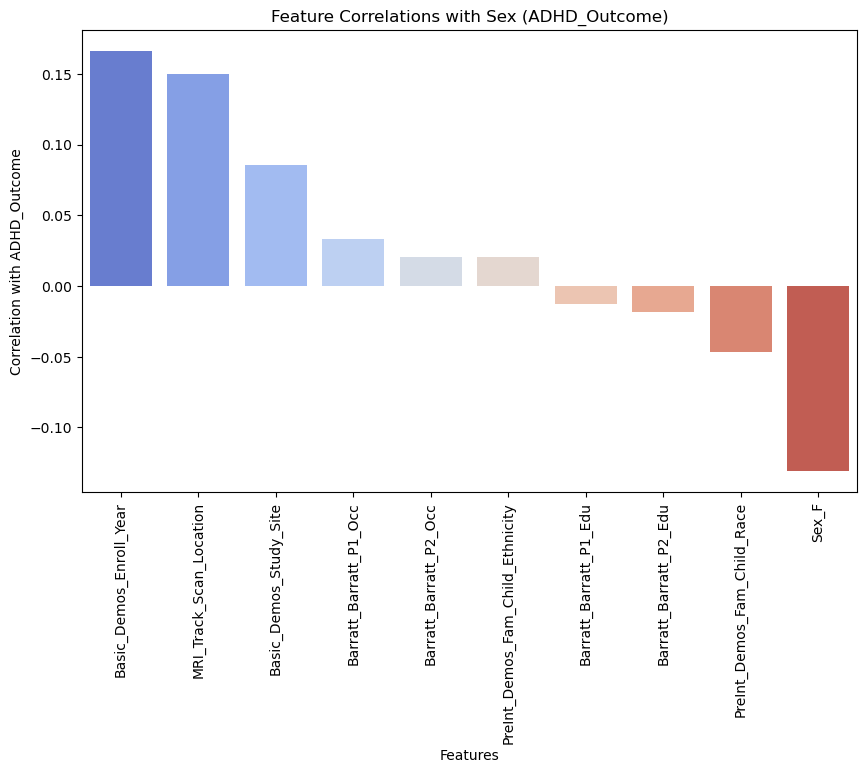

In [163]:
# Extract correlations of features with respect to 'ADHD_Outcome'
correlation_with_sex = corr['ADHD_Outcome'].drop('ADHD_Outcome').sort_values(ascending=False)

# Plot the correlations
plt.figure(figsize=(10, 6))
sns.barplot(x=correlation_with_sex.index, y=correlation_with_sex.values, palette="coolwarm")
plt.xticks(rotation=90)
plt.xlabel("Features")
plt.ylabel("Correlation with ADHD_Outcome")
plt.title("Feature Correlations with Sex (ADHD_Outcome)")
plt.show()

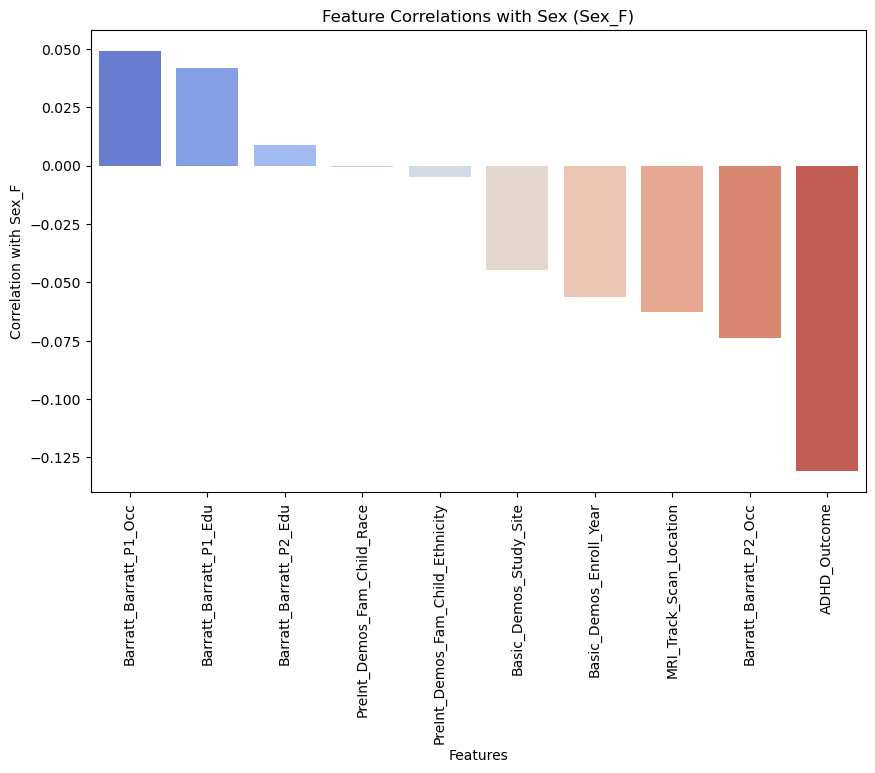

In [164]:
# Extract correlations of features with respect to 'Sex_F'
correlation_with_sex = corr['Sex_F'].drop('Sex_F').sort_values(ascending=False)

# Plot the correlations
plt.figure(figsize=(10, 6))
sns.barplot(x=correlation_with_sex.index, y=correlation_with_sex.values, palette="coolwarm")
plt.xticks(rotation=90)
plt.xlabel("Features")
plt.ylabel("Correlation with Sex_F")
plt.title("Feature Correlations with Sex (Sex_F)")
plt.show()

### Distribution of columns

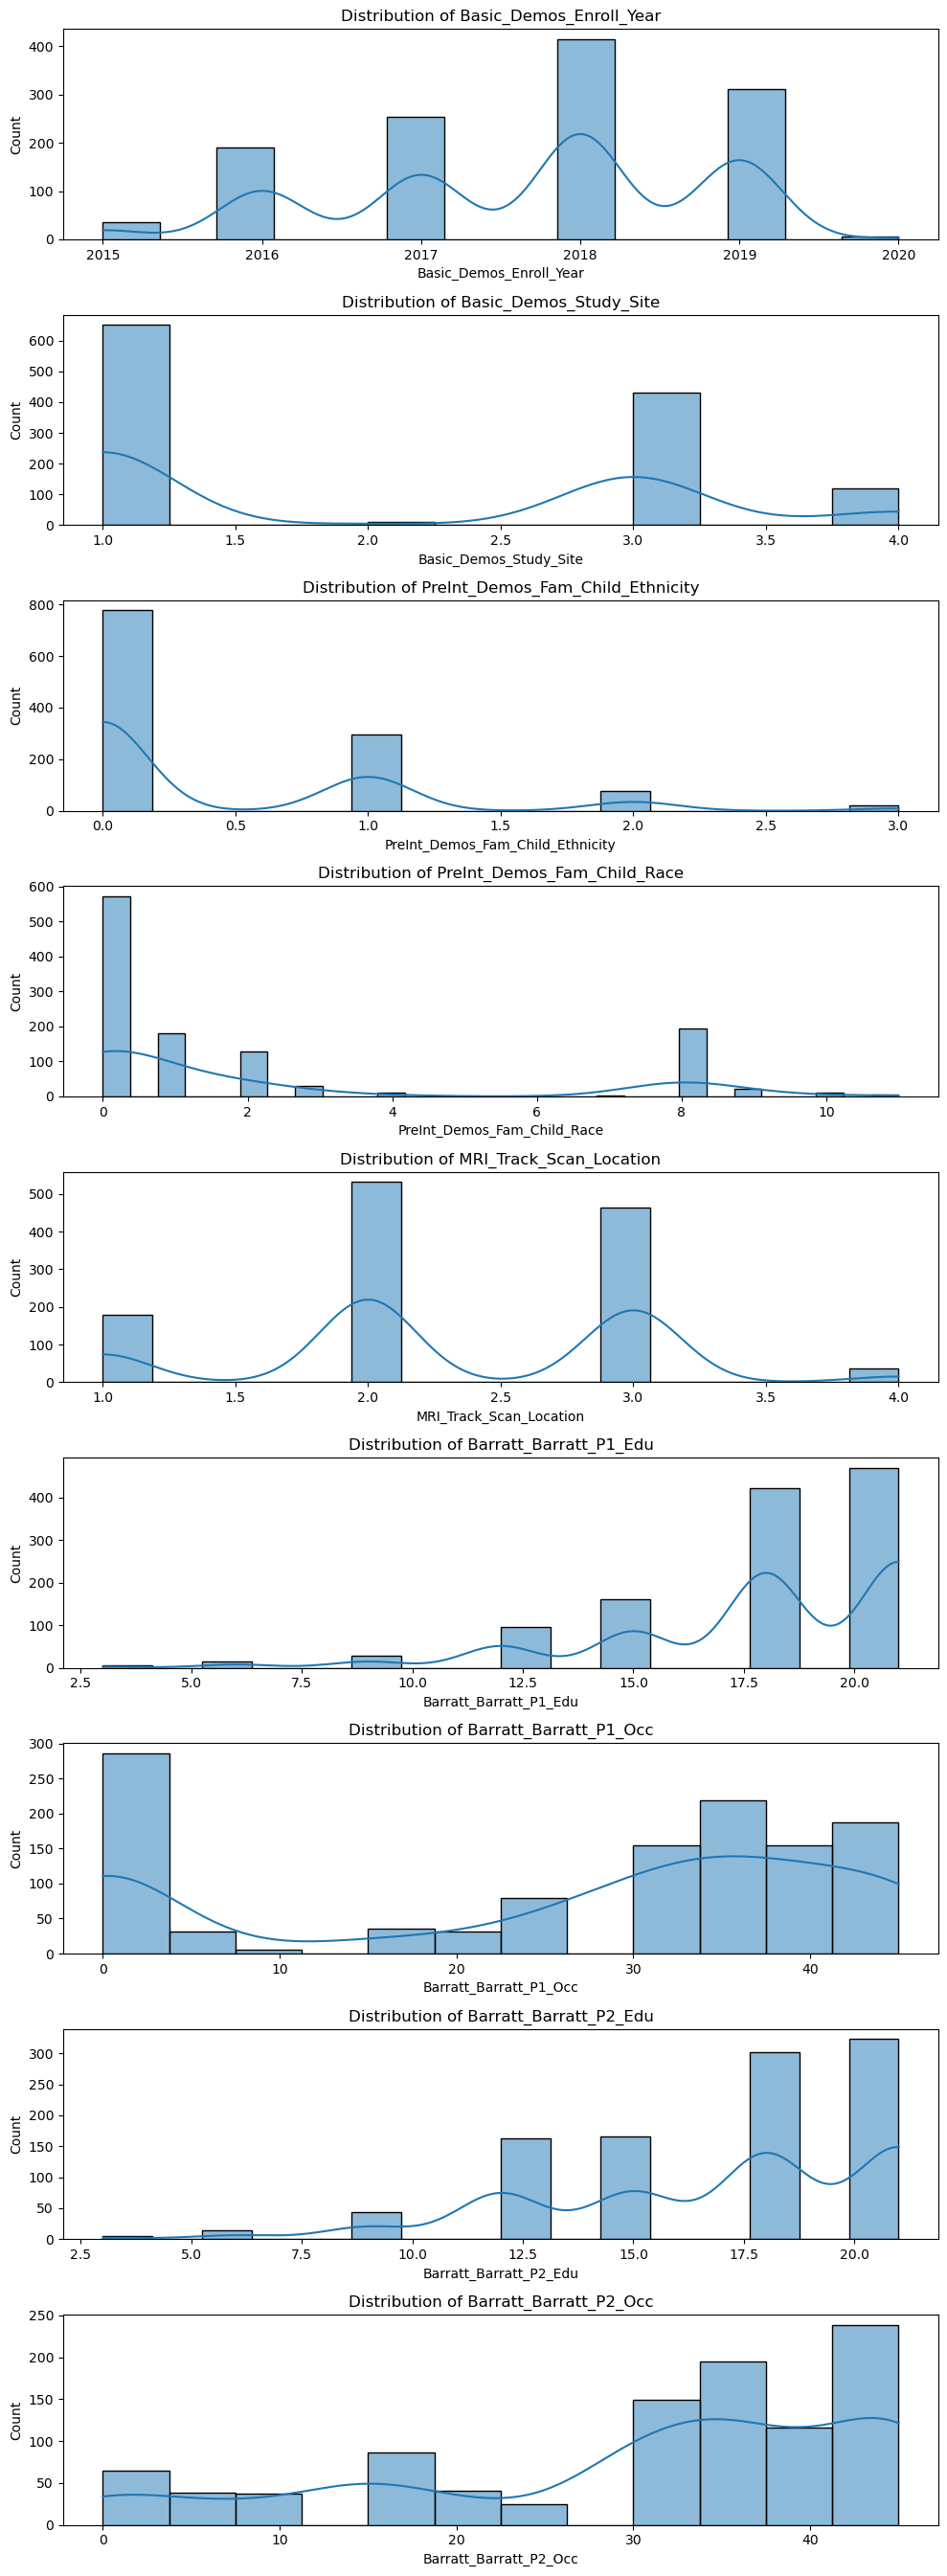

In [166]:
numeric_df = TRAIN_CATEGORICAL.select_dtypes(include=['float64', 'int64'])
num_columns = len(numeric_df.columns)

# Create one subplot per numeric column
fig, axes = plt.subplots(num_columns, 1, figsize=(10, num_columns * 3))

for i, column in enumerate(numeric_df.columns):
    sns.histplot(numeric_df[column], ax=axes[i], kde=True)
    axes[i].set_title(f'Distribution of {column}')

plt.tight_layout()
plt.show()

## TRAIN_FUNCTIONAL_CONNECTOME_MATRICES

Functional connectivity matrices are always square and symmetric, corresponding to the
number of regions of interest being used in a given anatomical atlas. For instance, using a 100
region atlas, the functional connectivity matrix would have a shape of 100x100, where each
value corresponds to the connectivity among that individual pair. For this challenge, you will be
provided with 200 x 200 connectivity matrices.

In [168]:
TRAIN_FUNCTIONAL_CONNECTOME_MATRICES.sort_values('participant_id').head()

,participant_id,0throw_1thcolumn,0throw_2thcolumn,0throw_3thcolumn,0throw_4thcolumn,0throw_5thcolumn,0throw_6thcolumn,0throw_7thcolumn,0throw_8thcolumn,0throw_9thcolumn,...,195throw_196thcolumn,195throw_197thcolumn,195throw_198thcolumn,195throw_199thcolumn,196throw_197thcolumn,196throw_198thcolumn,196throw_199thcolumn,197throw_198thcolumn,197throw_199thcolumn,198throw_199thcolumn
0,00aIpNTbG5uh,0.361339,0.791402,0.530706,0.623133,0.845830,0.680234,0.537144,0.387455,0.498571,...,-0.047477,-0.096450,-0.280312,0.037560,0.423037,0.242453,0.336213,0.402338,0.327915,0.539032
1,00fV0OyyoLfw,0.051430,0.613198,0.635255,0.391237,0.451225,0.600475,0.420935,0.234825,0.322048,...,-0.143218,-0.276464,-0.332783,-0.332711,0.556939,0.475578,0.429196,0.457970,0.312571,0.595978
2,04X1eiS79T4B,-0.305747,0.750316,-0.005342,0.458421,0.757530,0.756288,0.799046,0.622567,0.659165,...,-0.133778,-0.108588,-0.002132,-0.175586,0.679183,0.290292,0.486680,0.255208,0.575017,0.605182
3,05ocQutkURd6,0.450442,0.731530,0.799147,0.701688,0.747468,0.523304,0.575033,0.187189,0.441150,...,-0.096647,-0.041420,-0.199576,-0.216457,0.519074,0.298586,0.415466,0.511607,0.361204,0.446613
4,06YUNBA9ZRLq,0.415220,0.585700,0.355835,0.664142,0.683491,0.380201,0.375091,0.212314,0.445294,...,-0.158995,-0.274017,-0.141012,-0.002865,0.515169,0.336139,0.316430,0.442230,0.177079,0.378278


In [169]:
TRAIN_FUNCTIONAL_CONNECTOME_MATRICES.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1213 entries, 0 to 1212
Columns: 19901 entries, participant_id to 198throw_199thcolumn
dtypes: float64(19900), object(1)
memory usage: 184.2+ MB


In [170]:
TRAIN_FUNCTIONAL_CONNECTOME_MATRICES.drop('participant_id', axis=1).min().min()

-0.8753956628213888

In [171]:
TRAIN_FUNCTIONAL_CONNECTOME_MATRICES.drop('participant_id', axis=1).max().max()

0.9590231760120752

In [172]:
get_messing(TRAIN_FUNCTIONAL_CONNECTOME_MATRICES)

No Messing Data


- values ranges from -1 to 1 so no scaling will be needed.
- Will obviously need some feature reduction later on (PCA).

## TRAIN_QUANTITATIVE

In [175]:
TRAIN_QUANTITATIVE.head()

,participant_id,EHQ_EHQ_Total,ColorVision_CV_Score,APQ_P_APQ_P_CP,APQ_P_APQ_P_ID,APQ_P_APQ_P_INV,APQ_P_APQ_P_OPD,APQ_P_APQ_P_PM,APQ_P_APQ_P_PP,SDQ_SDQ_Conduct_Problems,SDQ_SDQ_Difficulties_Total,SDQ_SDQ_Emotional_Problems,SDQ_SDQ_Externalizing,SDQ_SDQ_Generating_Impact,SDQ_SDQ_Hyperactivity,SDQ_SDQ_Internalizing,SDQ_SDQ_Peer_Problems,SDQ_SDQ_Prosocial,MRI_Track_Age_at_Scan
0,00aIpNTbG5uh,100.00,13.0,3.0,15.0,44.0,14.0,20.0,27.0,3.0,17.0,4.0,11.0,5.0,8.0,6.0,2.0,9.0,14.274127
1,00fV0OyyoLfw,92.27,14.0,3.0,12.0,35.0,25.0,28.0,30.0,5.0,20.0,4.0,13.0,5.0,8.0,7.0,3.0,8.0,NaN
2,04X1eiS79T4B,86.67,14.0,3.0,21.0,37.0,18.0,26.0,28.0,3.0,24.0,7.0,10.0,10.0,7.0,14.0,7.0,7.0,13.463381
3,05ocQutkURd6,93.34,14.0,3.0,11.0,42.0,15.0,20.0,28.0,0.0,5.0,0.0,3.0,0.0,3.0,2.0,2.0,6.0,9.572553
4,06YUNBA9ZRLq,0.00,14.0,8.0,12.0,35.0,22.0,12.0,24.0,6.0,23.0,7.0,15.0,8.0,9.0,8.0,1.0,4.0,6.654574


In [176]:
TRAIN_QUANTITATIVE.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1213 entries, 0 to 1212
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   participant_id              1213 non-null   object 
 1   EHQ_EHQ_Total               1200 non-null   float64
 2   ColorVision_CV_Score        1190 non-null   float64
 3   APQ_P_APQ_P_CP              1201 non-null   float64
 4   APQ_P_APQ_P_ID              1201 non-null   float64
 5   APQ_P_APQ_P_INV             1201 non-null   float64
 6   APQ_P_APQ_P_OPD             1201 non-null   float64
 7   APQ_P_APQ_P_PM              1201 non-null   float64
 8   APQ_P_APQ_P_PP              1201 non-null   float64
 9   SDQ_SDQ_Conduct_Problems    1204 non-null   float64
 10  SDQ_SDQ_Difficulties_Total  1204 non-null   float64
 11  SDQ_SDQ_Emotional_Problems  1204 non-null   float64
 12  SDQ_SDQ_Externalizing       1204 non-null   float64
 13  SDQ_SDQ_Generating_Impact   1204 

In [177]:
TRAIN_QUANTITATIVE.describe()

,EHQ_EHQ_Total,ColorVision_CV_Score,APQ_P_APQ_P_CP,APQ_P_APQ_P_ID,APQ_P_APQ_P_INV,APQ_P_APQ_P_OPD,APQ_P_APQ_P_PM,APQ_P_APQ_P_PP,SDQ_SDQ_Conduct_Problems,SDQ_SDQ_Difficulties_Total,SDQ_SDQ_Emotional_Problems,SDQ_SDQ_Externalizing,SDQ_SDQ_Generating_Impact,SDQ_SDQ_Hyperactivity,SDQ_SDQ_Internalizing,SDQ_SDQ_Peer_Problems,SDQ_SDQ_Prosocial,MRI_Track_Age_at_Scan
count,1200.000000,1190.000000,1201.000000,1201.000000,1201.000000,1201.000000,1201.000000,1201.000000,1204.000000,1204.000000,1204.000000,1204.000000,1204.000000,1204.000000,1204.000000,1204.000000,1204.000000,853.000000
mean,59.514750,13.419328,3.819317,13.337219,39.767694,17.963364,16.557036,25.498751,2.074751,12.213455,2.324751,7.613787,4.103821,5.539037,4.599668,2.274917,7.740864,11.245678
std,49.744631,2.112830,1.330348,3.593562,4.872729,3.333965,5.146548,3.053720,2.022992,6.517330,2.166399,4.130399,2.808079,2.807063,3.510469,2.089041,2.094832,3.234372
min,-100.000000,0.000000,2.000000,5.000000,23.000000,7.000000,5.000000,13.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,46.670000,14.000000,3.000000,11.000000,36.000000,16.000000,13.000000,23.000000,0.000000,7.000000,1.000000,5.000000,2.000000,4.000000,2.000000,0.000000,6.000000,8.803901
50%,77.800000,14.000000,3.000000,13.000000,40.000000,18.000000,16.000000,26.000000,2.000000,12.000000,2.000000,8.000000,4.000000,6.000000,4.000000,2.000000,8.000000,10.739219
75%,94.470000,14.000000,4.000000,16.000000,43.000000,20.000000,19.000000,28.000000,3.000000,17.000000,4.000000,10.000000,6.000000,8.000000,7.000000,4.000000,10.000000,13.460871
max,100.000000,14.000000,12.000000,28.000000,50.000000,28.000000,37.000000,30.000000,10.000000,34.000000,10.000000,20.000000,10.000000,10.000000,17.000000,9.000000,10.000000,21.564453


In [178]:
get_messing(TRAIN_QUANTITATIVE)

,Count,%
participant_id,0,0.00
EHQ_EHQ_Total,13,1.07
ColorVision_CV_Score,23,1.90
APQ_P_APQ_P_CP,12,0.99
APQ_P_APQ_P_ID,12,0.99
APQ_P_APQ_P_INV,12,0.99
APQ_P_APQ_P_OPD,12,0.99
APQ_P_APQ_P_PM,12,0.99
APQ_P_APQ_P_PP,12,0.99
SDQ_SDQ_Conduct_Problems,9,0.74


In [179]:
merged_df = pd.merge(TRAIN_QUANTITATIVE, TRAINING_SOLUTIONS, on='participant_id', how='inner')
merged_df

,participant_id,EHQ_EHQ_Total,ColorVision_CV_Score,APQ_P_APQ_P_CP,APQ_P_APQ_P_ID,APQ_P_APQ_P_INV,APQ_P_APQ_P_OPD,APQ_P_APQ_P_PM,APQ_P_APQ_P_PP,SDQ_SDQ_Conduct_Problems,...,SDQ_SDQ_Emotional_Problems,SDQ_SDQ_Externalizing,SDQ_SDQ_Generating_Impact,SDQ_SDQ_Hyperactivity,SDQ_SDQ_Internalizing,SDQ_SDQ_Peer_Problems,SDQ_SDQ_Prosocial,MRI_Track_Age_at_Scan,ADHD_Outcome,Sex_F
0,00aIpNTbG5uh,100.00,13.0,3.0,15.0,44.0,14.0,20.0,27.0,3.0,...,4.0,11.0,5.0,8.0,6.0,2.0,9.0,14.274127,1,0
1,00fV0OyyoLfw,92.27,14.0,3.0,12.0,35.0,25.0,28.0,30.0,5.0,...,4.0,13.0,5.0,8.0,7.0,3.0,8.0,NaN,1,0
2,04X1eiS79T4B,86.67,14.0,3.0,21.0,37.0,18.0,26.0,28.0,3.0,...,7.0,10.0,10.0,7.0,14.0,7.0,7.0,13.463381,0,1
3,05ocQutkURd6,93.34,14.0,3.0,11.0,42.0,15.0,20.0,28.0,0.0,...,0.0,3.0,0.0,3.0,2.0,2.0,6.0,9.572553,0,1
4,06YUNBA9ZRLq,0.00,14.0,8.0,12.0,35.0,22.0,12.0,24.0,6.0,...,7.0,15.0,8.0,9.0,8.0,1.0,4.0,6.654574,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1208,zpU7rEseBMH8,100.00,14.0,3.0,11.0,41.0,16.0,23.0,24.0,0.0,...,0.0,6.0,6.0,6.0,2.0,2.0,8.0,12.669860,1,0
1209,zpr8w4jCfVPe,100.00,14.0,3.0,9.0,41.0,22.0,10.0,29.0,1.0,...,3.0,8.0,3.0,7.0,7.0,4.0,7.0,NaN,1,0
1210,zwBG0rZ05Mcb,46.67,13.0,3.0,12.0,30.0,18.0,14.0,24.0,0.0,...,3.0,5.0,3.0,5.0,5.0,2.0,8.0,8.155258,0,0
1211,zwXD5v17Rx01,46.67,14.0,3.0,18.0,42.0,21.0,15.0,25.0,2.0,...,0.0,5.0,0.0,3.0,0.0,0.0,7.0,7.364020,1,0


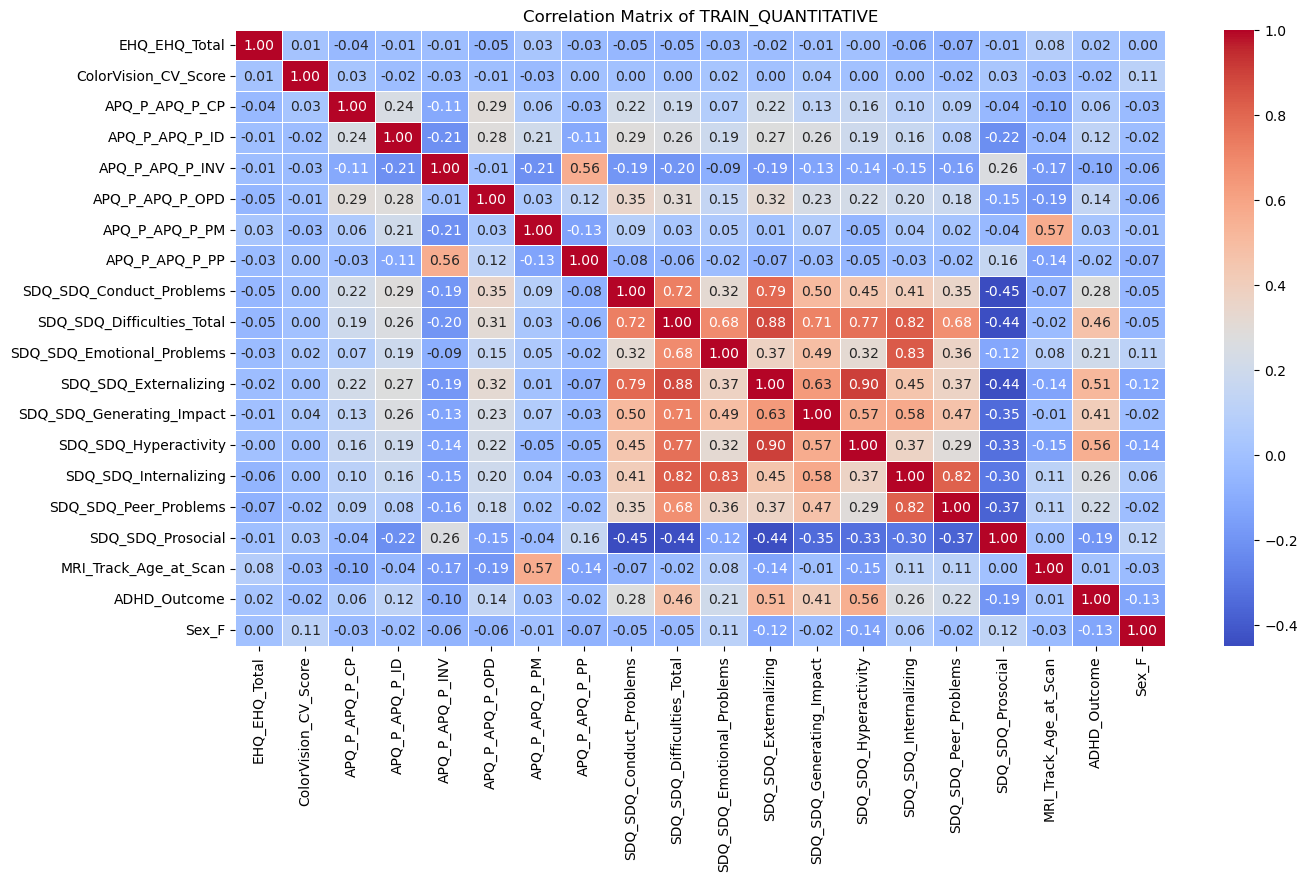

In [180]:
corr = merged_df.drop(['participant_id'],axis=1).corr()
plt.figure(figsize=(15, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of TRAIN_QUANTITATIVE")
plt.show()

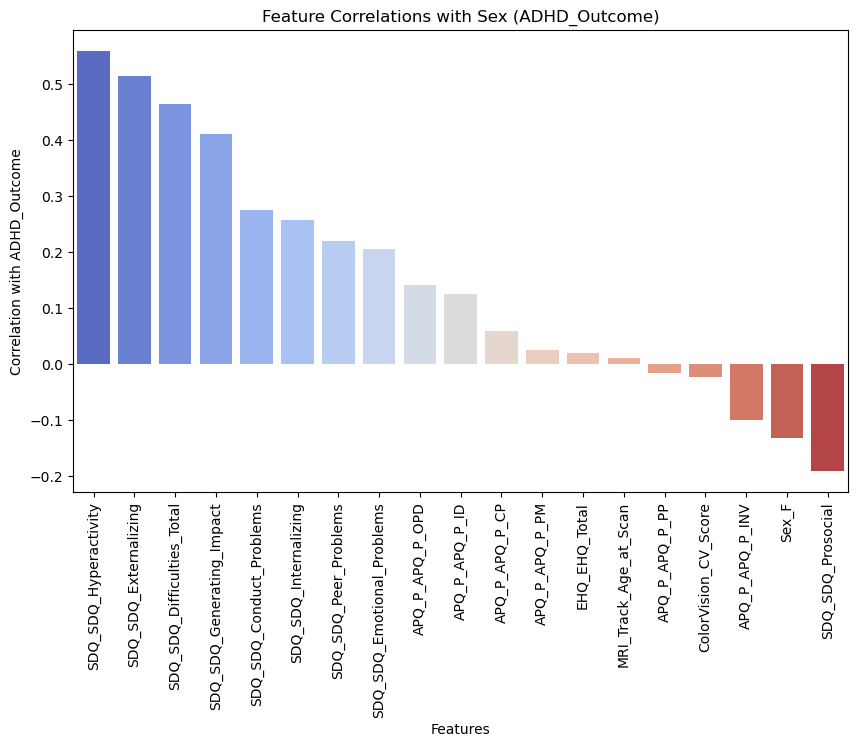

In [181]:
# Extract correlations of features with respect to 'ADHD_Outcome'
correlation_with_sex = corr['ADHD_Outcome'].drop('ADHD_Outcome').sort_values(ascending=False)

# Plot the correlations
plt.figure(figsize=(10, 6))
sns.barplot(x=correlation_with_sex.index, y=correlation_with_sex.values, palette="coolwarm")
plt.xticks(rotation=90)
plt.xlabel("Features")
plt.ylabel("Correlation with ADHD_Outcome")
plt.title("Feature Correlations with Sex (ADHD_Outcome)")
plt.show()

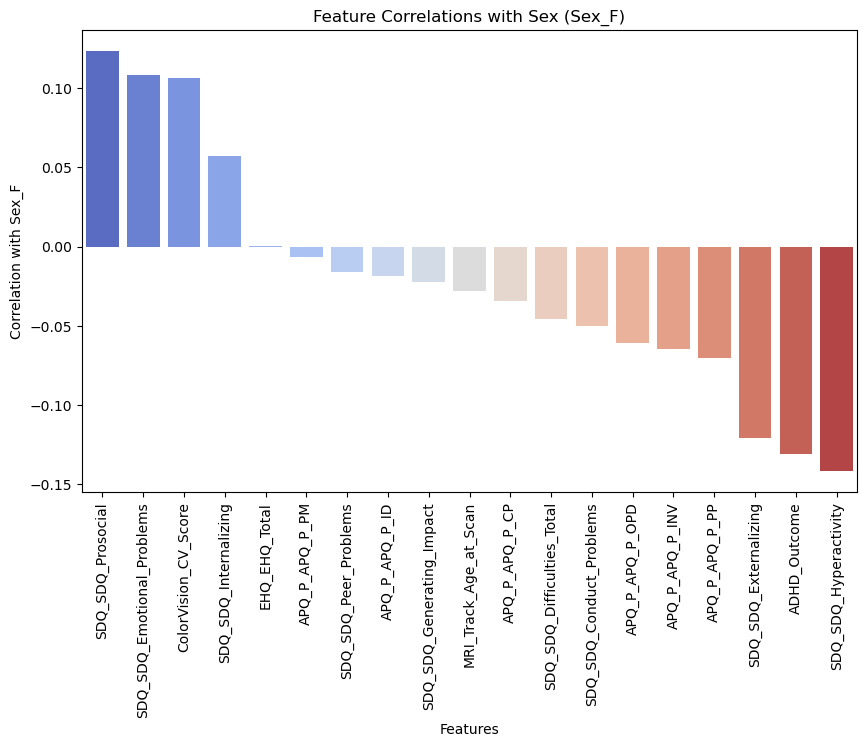

In [182]:
# Extract correlations of features with respect to 'Sex_F'
correlation_with_sex = corr['Sex_F'].drop('Sex_F').sort_values(ascending=False)

# Plot the correlations
plt.figure(figsize=(10, 6))
sns.barplot(x=correlation_with_sex.index, y=correlation_with_sex.values, palette="coolwarm")
plt.xticks(rotation=90)
plt.xlabel("Features")
plt.ylabel("Correlation with Sex_F")
plt.title("Feature Correlations with Sex (Sex_F)")
plt.show()

### Distribution of Numeric column

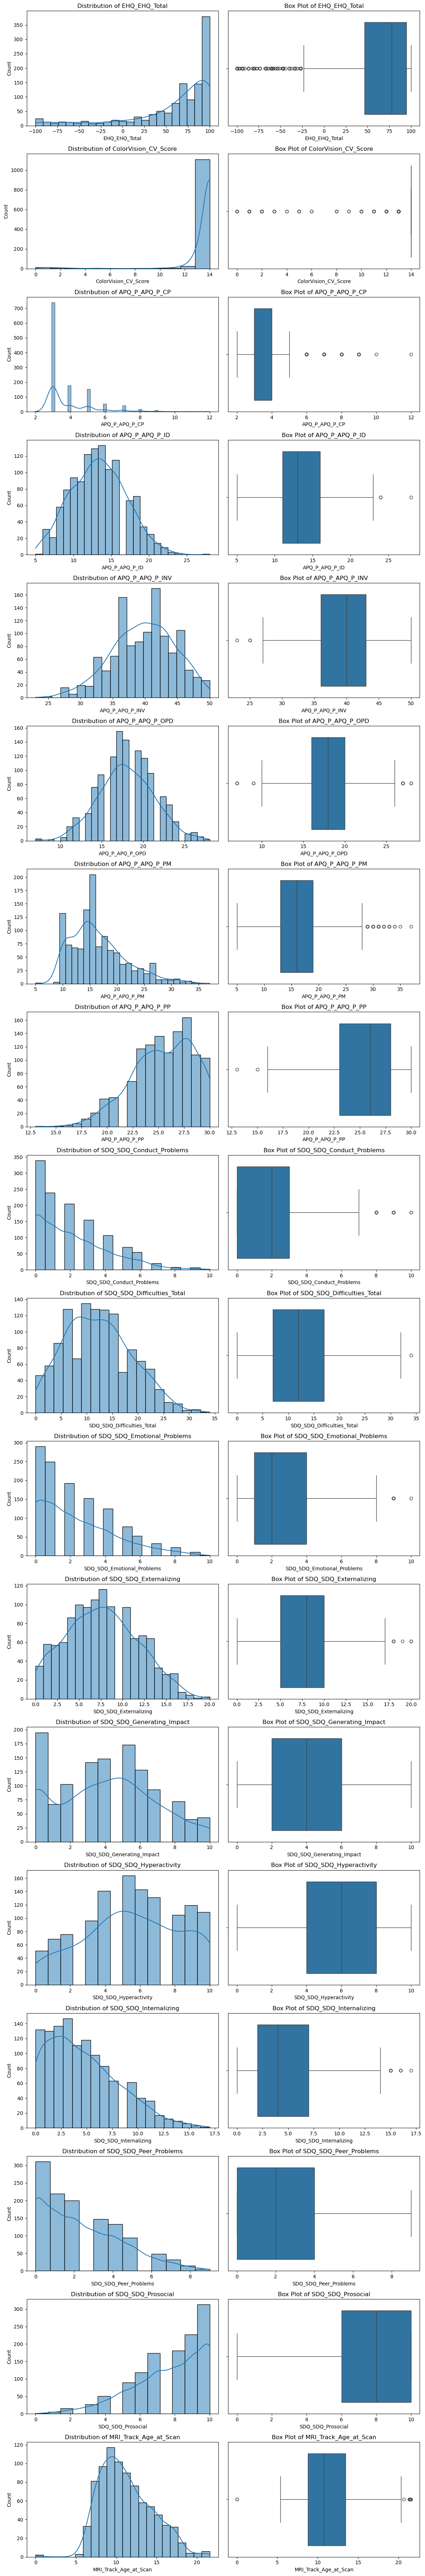

In [184]:
numeric_df = TRAIN_QUANTITATIVE.select_dtypes(include=['float64', 'int64'])
num_columns = len(numeric_df.columns)  
fig, axes = plt.subplots(num_columns, 2, figsize=(12, num_columns * 4))  # 2 subplots (distribution and boxplot) for each column

for i, column in enumerate(numeric_df.columns):
    # Distribution Plot
    sns.histplot(numeric_df[column], ax=axes[i, 0], kde=True)  # kde=True adds a kernel density estimate (smoothed curve)
    axes[i, 0].set_title(f'Distribution of {column}')

    # Box Plot
    sns.boxplot(x=numeric_df[column], ax=axes[i, 1])
    axes[i, 1].set_title(f'Box Plot of {column}')

# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()

# Pre-processing

## Missing data

### TRAIN_QUANTITATIVE

In [188]:
get_messing(TRAIN_QUANTITATIVE)

,Count,%
participant_id,0,0.00
EHQ_EHQ_Total,13,1.07
ColorVision_CV_Score,23,1.90
APQ_P_APQ_P_CP,12,0.99
APQ_P_APQ_P_ID,12,0.99
APQ_P_APQ_P_INV,12,0.99
APQ_P_APQ_P_OPD,12,0.99
APQ_P_APQ_P_PM,12,0.99
APQ_P_APQ_P_PP,12,0.99
SDQ_SDQ_Conduct_Problems,9,0.74


Those are only the columns with missing data

In [190]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
import pandas as pd

# Step 1: Separate participant_id
ids = TRAIN_QUANTITATIVE['participant_id']
data = TRAIN_QUANTITATIVE.drop(columns=['participant_id'])

# Step 2: Scale and Impute
scaler = StandardScaler()
scaled = scaler.fit_transform(data)

imputer = KNNImputer(n_neighbors=5)
filled = imputer.fit_transform(scaled)

# Step 3: Reconstruct the DataFrame
data_imputed = pd.DataFrame(scaler.inverse_transform(filled), columns=data.columns)

# Step 4: Add participant_id back
TRAIN_QUANTITATIVE_imputed = pd.concat([ids.reset_index(drop=True), data_imputed], axis=1)
TRAIN_QUANTITATIVE_imputed


,participant_id,EHQ_EHQ_Total,ColorVision_CV_Score,APQ_P_APQ_P_CP,APQ_P_APQ_P_ID,APQ_P_APQ_P_INV,APQ_P_APQ_P_OPD,APQ_P_APQ_P_PM,APQ_P_APQ_P_PP,SDQ_SDQ_Conduct_Problems,SDQ_SDQ_Difficulties_Total,SDQ_SDQ_Emotional_Problems,SDQ_SDQ_Externalizing,SDQ_SDQ_Generating_Impact,SDQ_SDQ_Hyperactivity,SDQ_SDQ_Internalizing,SDQ_SDQ_Peer_Problems,SDQ_SDQ_Prosocial,MRI_Track_Age_at_Scan
0,00aIpNTbG5uh,100.00,13.0,3.0,15.0,44.0,14.0,20.0,27.0,3.0,17.0,4.000000e+00,11.0,5.0,8.0,6.0,2.0,9.0,14.274127
1,00fV0OyyoLfw,92.27,14.0,3.0,12.0,35.0,25.0,28.0,30.0,5.0,20.0,4.000000e+00,13.0,5.0,8.0,7.0,3.0,8.0,13.340269
2,04X1eiS79T4B,86.67,14.0,3.0,21.0,37.0,18.0,26.0,28.0,3.0,24.0,7.000000e+00,10.0,10.0,7.0,14.0,7.0,7.0,13.463381
3,05ocQutkURd6,93.34,14.0,3.0,11.0,42.0,15.0,20.0,28.0,0.0,5.0,-4.440892e-16,3.0,0.0,3.0,2.0,2.0,6.0,9.572553
4,06YUNBA9ZRLq,0.00,14.0,8.0,12.0,35.0,22.0,12.0,24.0,6.0,23.0,7.000000e+00,15.0,8.0,9.0,8.0,1.0,4.0,6.654574
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1208,zpU7rEseBMH8,100.00,14.0,3.0,11.0,41.0,16.0,23.0,24.0,0.0,8.0,-4.440892e-16,6.0,6.0,6.0,2.0,2.0,8.0,12.669860
1209,zpr8w4jCfVPe,100.00,14.0,3.0,9.0,41.0,22.0,10.0,29.0,1.0,15.0,3.000000e+00,8.0,3.0,7.0,7.0,4.0,7.0,9.622815
1210,zwBG0rZ05Mcb,46.67,13.0,3.0,12.0,30.0,18.0,14.0,24.0,0.0,10.0,3.000000e+00,5.0,3.0,5.0,5.0,2.0,8.0,8.155258
1211,zwXD5v17Rx01,46.67,14.0,3.0,18.0,42.0,21.0,15.0,25.0,2.0,5.0,-4.440892e-16,5.0,0.0,3.0,0.0,0.0,7.0,7.364020


In [191]:
TRAIN_QUANTITATIVE

,participant_id,EHQ_EHQ_Total,ColorVision_CV_Score,APQ_P_APQ_P_CP,APQ_P_APQ_P_ID,APQ_P_APQ_P_INV,APQ_P_APQ_P_OPD,APQ_P_APQ_P_PM,APQ_P_APQ_P_PP,SDQ_SDQ_Conduct_Problems,SDQ_SDQ_Difficulties_Total,SDQ_SDQ_Emotional_Problems,SDQ_SDQ_Externalizing,SDQ_SDQ_Generating_Impact,SDQ_SDQ_Hyperactivity,SDQ_SDQ_Internalizing,SDQ_SDQ_Peer_Problems,SDQ_SDQ_Prosocial,MRI_Track_Age_at_Scan
0,00aIpNTbG5uh,100.00,13.0,3.0,15.0,44.0,14.0,20.0,27.0,3.0,17.0,4.0,11.0,5.0,8.0,6.0,2.0,9.0,14.274127
1,00fV0OyyoLfw,92.27,14.0,3.0,12.0,35.0,25.0,28.0,30.0,5.0,20.0,4.0,13.0,5.0,8.0,7.0,3.0,8.0,NaN
2,04X1eiS79T4B,86.67,14.0,3.0,21.0,37.0,18.0,26.0,28.0,3.0,24.0,7.0,10.0,10.0,7.0,14.0,7.0,7.0,13.463381
3,05ocQutkURd6,93.34,14.0,3.0,11.0,42.0,15.0,20.0,28.0,0.0,5.0,0.0,3.0,0.0,3.0,2.0,2.0,6.0,9.572553
4,06YUNBA9ZRLq,0.00,14.0,8.0,12.0,35.0,22.0,12.0,24.0,6.0,23.0,7.0,15.0,8.0,9.0,8.0,1.0,4.0,6.654574
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1208,zpU7rEseBMH8,100.00,14.0,3.0,11.0,41.0,16.0,23.0,24.0,0.0,8.0,0.0,6.0,6.0,6.0,2.0,2.0,8.0,12.669860
1209,zpr8w4jCfVPe,100.00,14.0,3.0,9.0,41.0,22.0,10.0,29.0,1.0,15.0,3.0,8.0,3.0,7.0,7.0,4.0,7.0,NaN
1210,zwBG0rZ05Mcb,46.67,13.0,3.0,12.0,30.0,18.0,14.0,24.0,0.0,10.0,3.0,5.0,3.0,5.0,5.0,2.0,8.0,8.155258
1211,zwXD5v17Rx01,46.67,14.0,3.0,18.0,42.0,21.0,15.0,25.0,2.0,5.0,0.0,5.0,0.0,3.0,0.0,0.0,7.0,7.364020


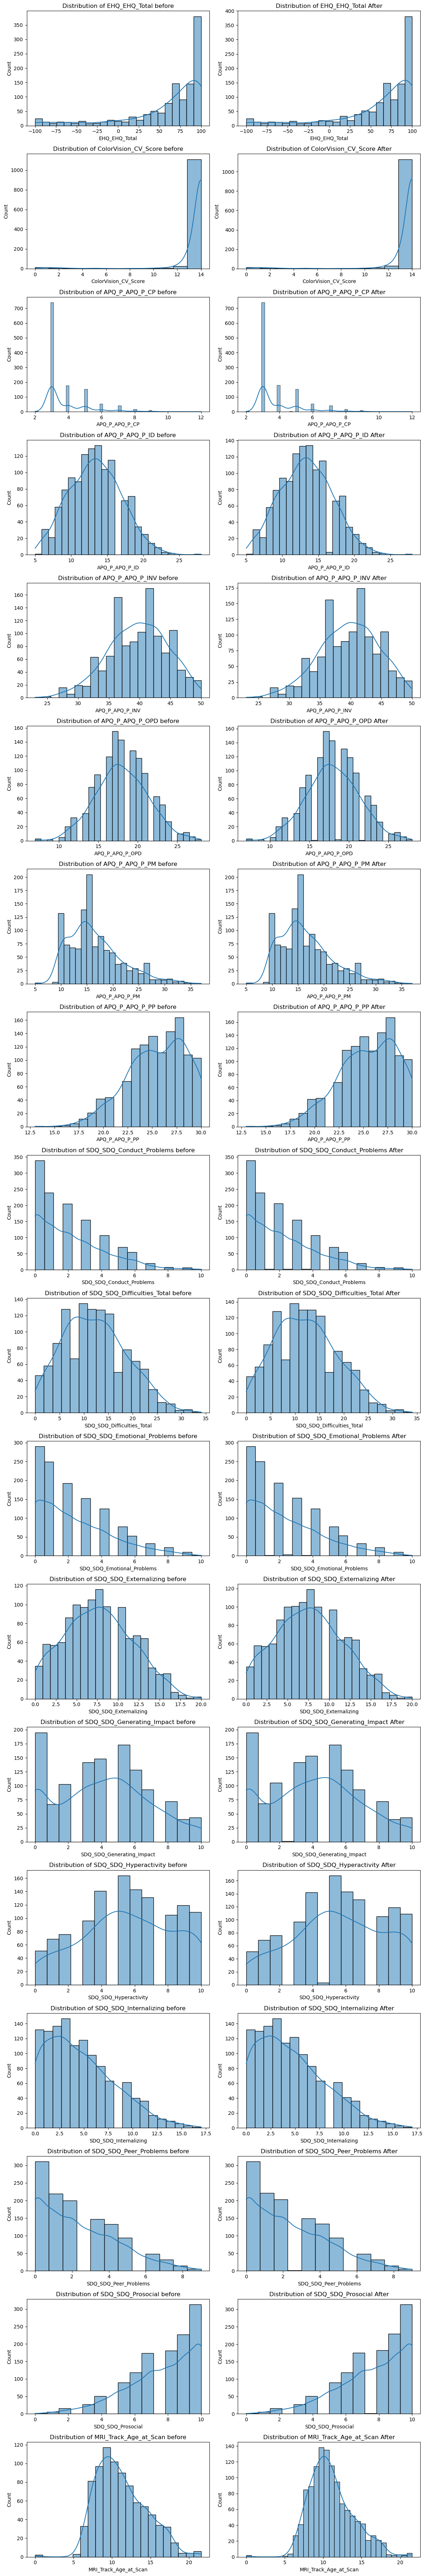

In [192]:
numeric_df = TRAIN_QUANTITATIVE.select_dtypes(include=['float64', 'int64'])
numeric_df_imputed = TRAIN_QUANTITATIVE_imputed.select_dtypes(include=['float64', 'int64'])

num_columns = len(numeric_df.columns)  
fig, axes = plt.subplots(num_columns, 2, figsize=(12, num_columns * 4))  # 2 subplots (distribution and boxplot) for each column

for i, column in enumerate(numeric_df.columns):
    # Distribution Plot before
    sns.histplot(numeric_df[column], ax=axes[i, 0], kde=True)  # kde=True adds a kernel density estimate (smoothed curve)
    axes[i, 0].set_title(f'Distribution of {column} before')

    # Distribution Plot After
    sns.histplot(numeric_df_imputed[column], ax=axes[i, 1], kde=True)  # kde=True adds a kernel density estimate (smoothed curve)
    axes[i, 1].set_title(f'Distribution of {column} After')

# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()

In [193]:
get_messing(TRAIN_QUANTITATIVE_imputed)

No Messing Data


### TRAIN_CATEGORICAL

In [195]:
get_messing(TRAIN_CATEGORICAL)

,Count,%
participant_id,0,0.00
Basic_Demos_Enroll_Year,0,0.00
Basic_Demos_Study_Site,0,0.00
PreInt_Demos_Fam_Child_Ethnicity,43,3.54
PreInt_Demos_Fam_Child_Race,54,4.45
MRI_Track_Scan_Location,3,0.25
Barratt_Barratt_P1_Edu,15,1.24
Barratt_Barratt_P1_Occ,31,2.56
Barratt_Barratt_P2_Edu,198,16.32
Barratt_Barratt_P2_Occ,222,18.30


In [196]:
TRAIN_CATEGORICAL.head()

,participant_id,Basic_Demos_Enroll_Year,Basic_Demos_Study_Site,PreInt_Demos_Fam_Child_Ethnicity,PreInt_Demos_Fam_Child_Race,MRI_Track_Scan_Location,Barratt_Barratt_P1_Edu,Barratt_Barratt_P1_Occ,Barratt_Barratt_P2_Edu,Barratt_Barratt_P2_Occ
0,00aIpNTbG5uh,2019,4,1.0,0.0,3.0,21.0,45.0,NaN,NaN
1,00fV0OyyoLfw,2017,1,0.0,9.0,2.0,21.0,0.0,21.0,45.0
2,04X1eiS79T4B,2017,1,1.0,2.0,2.0,9.0,0.0,NaN,NaN
3,05ocQutkURd6,2018,1,3.0,8.0,2.0,18.0,10.0,18.0,0.0
4,06YUNBA9ZRLq,2018,1,0.0,1.0,2.0,12.0,0.0,NaN,NaN


In [197]:
TRAIN_CATEGORICAL[['Basic_Demos_Study_Site','MRI_Track_Scan_Location']]

,Basic_Demos_Study_Site,MRI_Track_Scan_Location
0,4,3.0
1,1,2.0
2,1,2.0
3,1,2.0
4,1,2.0
...,...,...
1208,1,2.0
1209,3,3.0
1210,1,2.0
1211,1,3.0


In [198]:
TRAIN_CATEGORICAL[TRAIN_CATEGORICAL['MRI_Track_Scan_Location'].isna()]

,participant_id,Basic_Demos_Enroll_Year,Basic_Demos_Study_Site,PreInt_Demos_Fam_Child_Ethnicity,PreInt_Demos_Fam_Child_Race,MRI_Track_Scan_Location,Barratt_Barratt_P1_Edu,Barratt_Barratt_P1_Occ,Barratt_Barratt_P2_Edu,Barratt_Barratt_P2_Occ
585,UmN79UUheNpw,2016,1,0.0,0.0,NaN,21.0,25.0,18.0,45.0
1155,x0yuhCZiG4mU,2016,1,0.0,0.0,NaN,18.0,40.0,18.0,45.0
1201,zSOTbT8r7FQ2,2016,1,0.0,NaN,NaN,15.0,0.0,21.0,35.0


In [199]:
TRAIN_CATEGORICAL_imputed = TRAIN_CATEGORICAL.copy()
TRAIN_CATEGORICAL_imputed['MRI_Track_Scan_Location'] = TRAIN_CATEGORICAL.groupby(['Basic_Demos_Enroll_Year', 'Basic_Demos_Study_Site'])['MRI_Track_Scan_Location']\
        .transform(lambda x: x.fillna(x.mode()[0]))  
TRAIN_CATEGORICAL_imputed.iloc[[585, 1155, 1201]]

,participant_id,Basic_Demos_Enroll_Year,Basic_Demos_Study_Site,PreInt_Demos_Fam_Child_Ethnicity,PreInt_Demos_Fam_Child_Race,MRI_Track_Scan_Location,Barratt_Barratt_P1_Edu,Barratt_Barratt_P1_Occ,Barratt_Barratt_P2_Edu,Barratt_Barratt_P2_Occ
585,UmN79UUheNpw,2016,1,0.0,0.0,1.0,21.0,25.0,18.0,45.0
1155,x0yuhCZiG4mU,2016,1,0.0,0.0,1.0,18.0,40.0,18.0,45.0
1201,zSOTbT8r7FQ2,2016,1,0.0,NaN,1.0,15.0,0.0,21.0,35.0


In [200]:
get_messing(TRAIN_CATEGORICAL_imputed)

,Count,%
participant_id,0,0.00
Basic_Demos_Enroll_Year,0,0.00
Basic_Demos_Study_Site,0,0.00
PreInt_Demos_Fam_Child_Ethnicity,43,3.54
PreInt_Demos_Fam_Child_Race,54,4.45
MRI_Track_Scan_Location,0,0.00
Barratt_Barratt_P1_Edu,15,1.24
Barratt_Barratt_P1_Occ,31,2.56
Barratt_Barratt_P2_Edu,198,16.32
Barratt_Barratt_P2_Occ,222,18.30


In [201]:
col_to_impute = ['Barratt_Barratt_P1_Occ','Barratt_Barratt_P2_Edu','Barratt_Barratt_P2_Occ']
for col in col_to_impute:
    TRAIN_CATEGORICAL_imputed[col] = TRAIN_CATEGORICAL_imputed.groupby(
        ['Basic_Demos_Study_Site','Barratt_Barratt_P1_Edu']
    )[col].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
get_messing(TRAIN_CATEGORICAL_imputed,drop=True) 

,Count,%
PreInt_Demos_Fam_Child_Ethnicity,43.0,3.54
PreInt_Demos_Fam_Child_Race,54.0,4.45
Barratt_Barratt_P1_Edu,15.0,1.24
Barratt_Barratt_P1_Occ,15.0,1.24
Barratt_Barratt_P2_Edu,19.0,1.57
Barratt_Barratt_P2_Occ,19.0,1.57


In [202]:
from sklearn.impute import SimpleImputer
cols = get_messing(TRAIN_CATEGORICAL_imputed,drop=True).index.tolist()
imputer = SimpleImputer(strategy='most_frequent')
TRAIN_CATEGORICAL_imputed[cols] = imputer.fit_transform(TRAIN_CATEGORICAL_imputed[cols])
get_messing(TRAIN_CATEGORICAL_imputed,drop=True) 

No Messing Data


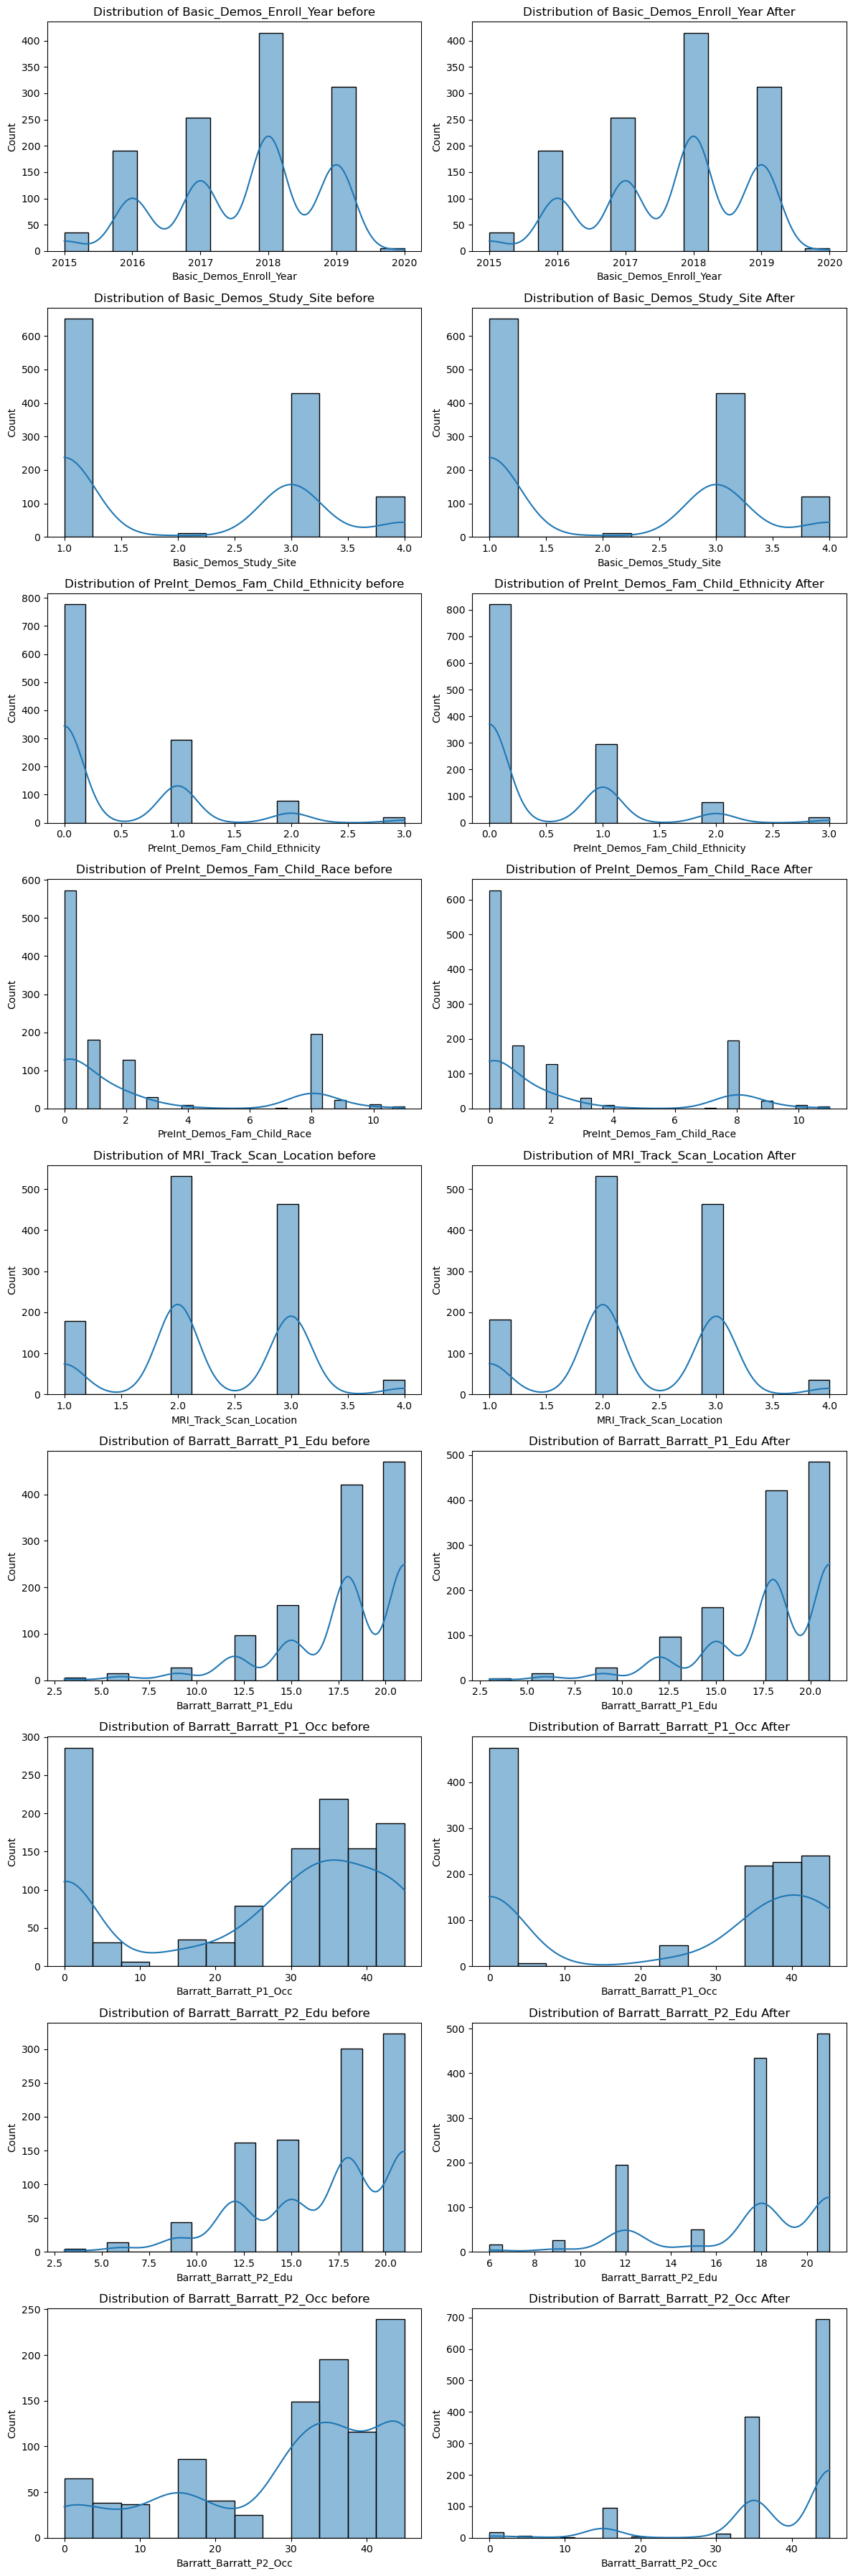

In [203]:
numeric_df = TRAIN_CATEGORICAL.select_dtypes(include=['float64', 'int64'])
numeric_df_imputed = TRAIN_CATEGORICAL_imputed.select_dtypes(include=['float64', 'int64'])

num_columns = len(numeric_df.columns)  
fig, axes = plt.subplots(num_columns, 2, figsize=(12, num_columns * 4))  # 2 subplots (distribution and boxplot) for each column

for i, column in enumerate(numeric_df.columns):
    # Distribution Plot before
    sns.histplot(numeric_df[column], ax=axes[i, 0], kde=True)  # kde=True adds a kernel density estimate (smoothed curve)
    axes[i, 0].set_title(f'Distribution of {column} before')

    # Distribution Plot After
    sns.histplot(numeric_df_imputed[column], ax=axes[i, 1], kde=True)  # kde=True adds a kernel density estimate (smoothed curve)
    axes[i, 1].set_title(f'Distribution of {column} After')

# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()

## Outliers

In [205]:
numeric_df=TRAIN_QUANTITATIVE_imputed.select_dtypes(include=['float64', 'int64'])
Outliers=numeric_df.columns.tolist()
print(len(Outliers))
Outliers

18


['EHQ_EHQ_Total',
 'ColorVision_CV_Score',
 'APQ_P_APQ_P_CP',
 'APQ_P_APQ_P_ID',
 'APQ_P_APQ_P_INV',
 'APQ_P_APQ_P_OPD',
 'APQ_P_APQ_P_PM',
 'APQ_P_APQ_P_PP',
 'SDQ_SDQ_Conduct_Problems',
 'SDQ_SDQ_Difficulties_Total',
 'SDQ_SDQ_Emotional_Problems',
 'SDQ_SDQ_Externalizing',
 'SDQ_SDQ_Generating_Impact',
 'SDQ_SDQ_Hyperactivity',
 'SDQ_SDQ_Internalizing',
 'SDQ_SDQ_Peer_Problems',
 'SDQ_SDQ_Prosocial',
 'MRI_Track_Age_at_Scan']

In [206]:
df = handel_Outliers(numeric_df,Outliers,handel=True)

EHQ_EHQ_Total  : 

IQR = 46.730000000000004
lower,upper bounds [-23.424999999999997,163.495]
Total number of outliers in EHQ_EHQ_Total are 110
ColorVision_CV_Score  : 

IQR = 0.0
lower,upper bounds [14.0,14.0]
Total number of outliers in ColorVision_CV_Score are 234
APQ_P_APQ_P_CP  : 

IQR = 1.0
lower,upper bounds [1.5,5.5]
Total number of outliers in APQ_P_APQ_P_CP are 128
APQ_P_APQ_P_ID  : 

IQR = 5.0
lower,upper bounds [3.5,23.5]
Total number of outliers in APQ_P_APQ_P_ID are 3
APQ_P_APQ_P_INV  : 

IQR = 7.0
lower,upper bounds [25.5,53.5]
Total number of outliers in APQ_P_APQ_P_INV are 3
APQ_P_APQ_P_OPD  : 

IQR = 4.0
lower,upper bounds [10.0,26.0]
Total number of outliers in APQ_P_APQ_P_OPD are 13
APQ_P_APQ_P_PM  : 

IQR = 6.0
lower,upper bounds [4.0,28.0]
Total number of outliers in APQ_P_APQ_P_PM are 37
APQ_P_APQ_P_PP  : 

IQR = 5.0
lower,upper bounds [15.5,35.5]
Total number of outliers in APQ_P_APQ_P_PP are 2
SDQ_SDQ_Conduct_Problems  : 

IQR = 3.0
lower,upper bounds [-4.5,7.5]

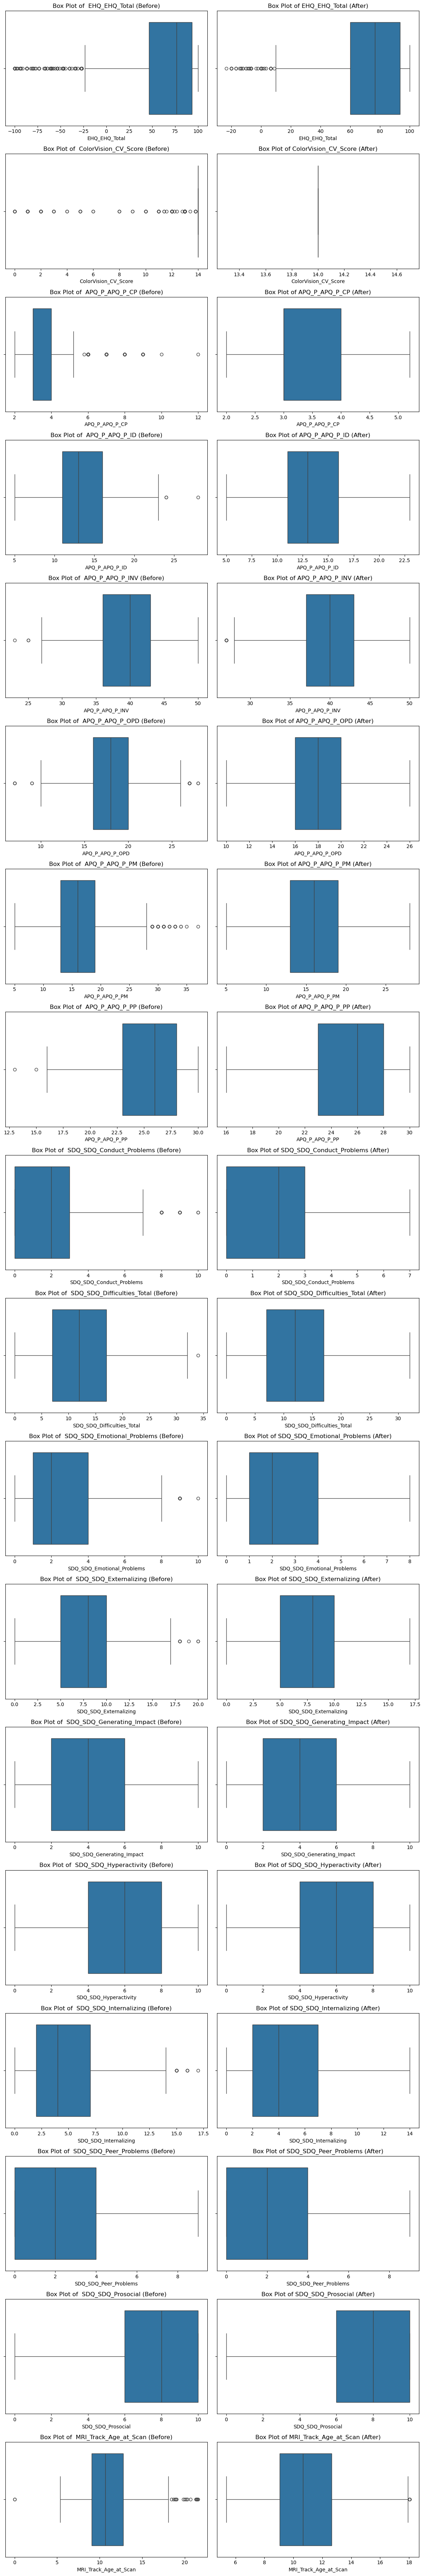

In [207]:
df_old = TRAIN_QUANTITATIVE_imputed.copy()
num_columns = len(Outliers)  # Number of columns in your DataFrame
fig, axes = plt.subplots(num_columns, 2, figsize=(12, num_columns * 4))  # 2 subplots (distribution and boxplot) for each column

# Loop through each column to create distribution and boxplot
for i, column in enumerate(Outliers):
    # Before
    sns.boxplot(x=df_old[column], ax=axes[i, 0])  # kde=True adds a kernel density estimate (smoothed curve)
    axes[i, 0].set_title(f'Box Plot of  {column} (Before)')

    # After
    sns.boxplot(x=df[column], ax=axes[i, 1])
    axes[i, 1].set_title(f'Box Plot of {column} (After)')

# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()

## Feature Reduction

### TRAIN_FUNCTIONAL_CONNECTOME_MATRICES

In [210]:
df = TRAIN_FUNCTIONAL_CONNECTOME_MATRICES.iloc[:,1:]
df

,0throw_1thcolumn,0throw_2thcolumn,0throw_3thcolumn,0throw_4thcolumn,0throw_5thcolumn,0throw_6thcolumn,0throw_7thcolumn,0throw_8thcolumn,0throw_9thcolumn,0throw_10thcolumn,...,195throw_196thcolumn,195throw_197thcolumn,195throw_198thcolumn,195throw_199thcolumn,196throw_197thcolumn,196throw_198thcolumn,196throw_199thcolumn,197throw_198thcolumn,197throw_199thcolumn,198throw_199thcolumn
0,0.361339,0.791402,0.530706,0.623133,0.845830,0.680234,0.537144,0.387455,0.498571,0.049068,...,-0.047477,-0.096450,-0.280312,0.037560,0.423037,0.242453,0.336213,0.402338,0.327915,0.539032
1,0.051430,0.613198,0.635255,0.391237,0.451225,0.600475,0.420935,0.234825,0.322048,0.181864,...,-0.143218,-0.276464,-0.332783,-0.332711,0.556939,0.475578,0.429196,0.457970,0.312571,0.595978
2,-0.305747,0.750316,-0.005342,0.458421,0.757530,0.756288,0.799046,0.622567,0.659165,0.519783,...,-0.133778,-0.108588,-0.002132,-0.175586,0.679183,0.290292,0.486680,0.255208,0.575017,0.605182
3,0.450442,0.731530,0.799147,0.701688,0.747468,0.523304,0.575033,0.187189,0.441150,-0.004607,...,-0.096647,-0.041420,-0.199576,-0.216457,0.519074,0.298586,0.415466,0.511607,0.361204,0.446613
4,0.415220,0.585700,0.355835,0.664142,0.683491,0.380201,0.375091,0.212314,0.445294,0.226854,...,-0.158995,-0.274017,-0.141012,-0.002865,0.515169,0.336139,0.316430,0.442230,0.177079,0.378278
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1208,-0.017270,0.856987,0.827741,0.548133,0.800407,0.574002,0.798349,0.284567,0.155855,0.435824,...,0.156577,-0.233931,-0.140041,-0.183657,0.253419,0.520024,0.337320,0.629728,0.678281,0.814656
1209,0.342895,0.653258,0.691103,0.271458,0.593868,0.516559,0.360994,0.140348,0.062568,-0.025561,...,-0.039988,-0.087121,-0.049484,-0.119850,0.610159,0.570343,0.303530,0.850718,0.725138,0.721350
1210,0.251472,0.692684,0.544077,0.622913,0.658320,0.481675,0.476222,0.293739,0.368002,0.236086,...,-0.126600,-0.393645,-0.074682,-0.204213,0.370247,0.238742,0.131456,0.472743,0.588147,0.418452
1211,-0.045660,0.207386,-0.140892,0.053852,0.204124,0.479489,0.333045,0.239930,0.314171,0.219034,...,0.343204,0.198827,0.253990,0.198741,0.648260,0.055241,0.491985,0.118676,0.404331,0.537121


**What is "Explained Variance" in PCA?**\
When you apply PCA, you're transforming your original data (maybe hundreds or thousands of features) into a new set of principal components (PCs).\
Each PC captures a portion of the total variance (i.e. the "spread" or information) in the data.

- Explained Variance = How much variation in the data is captured by a single principal component.

- Cumulative Explained Variance = The total variance captured up to that component (e.g. PC1 + PC2 + PC3...).

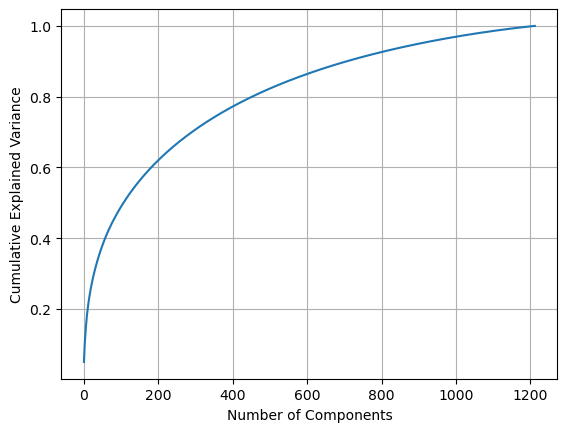

In [212]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

pca = PCA().fit(df)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()


In [135]:
pca = PCA(n_components=0.7)  # Keep 75% of the variance
reduced_data = pca.fit_transform(TRAIN_FUNCTIONAL_CONNECTOME_MATRICES.iloc[:,1:])
reduced_data.shape

(1213, 292)

In [78]:
pca_columns = [f'PC_{i+1}' for i in range(reduced_data.shape[1])]

# Convert to DataFrame
reduced_df = pd.DataFrame(reduced_data, columns=pca_columns)
reduced_df['participant_id'] = TRAIN_FUNCTIONAL_CONNECTOME_MATRICES['participant_id']
reduced_df

,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,PC_9,PC_10,...,PC_700,PC_701,PC_702,PC_703,PC_704,PC_705,PC_706,PC_707,PC_708,participant_id
0,-5.367968,-5.068500,1.508765,2.062678,0.697009,-0.371967,-2.574856,-1.824426,-2.881217,2.042189,...,-0.489485,-0.885926,-0.139877,-0.838073,0.221972,0.063530,-0.186907,0.787447,-0.134540,00aIpNTbG5uh
1,-4.108815,-3.920926,0.070828,1.683232,-1.204590,1.199795,-0.275150,0.007479,0.797247,-1.207645,...,-0.662983,0.497977,0.005155,-0.245164,-0.469853,-0.304255,-1.391458,0.073335,0.337728,00fV0OyyoLfw
2,-5.987513,-5.386339,2.510001,-3.763229,1.955189,-1.496322,-2.904989,2.163707,3.292545,-0.556093,...,0.107149,0.757717,0.999471,-0.093451,0.526037,-0.017413,-0.008086,0.640064,0.037636,04X1eiS79T4B
3,-3.775851,-6.756400,0.928621,3.646527,-3.212114,-0.677817,-2.633906,-0.383115,-0.332242,2.460489,...,0.637467,0.054950,-0.145480,-0.153771,0.006845,0.356799,1.287903,-0.416973,0.363878,05ocQutkURd6
4,1.979975,-4.088958,-3.459130,3.523769,-0.906082,-0.608358,-5.656954,3.202955,2.225541,1.825331,...,-0.986809,0.547674,-0.269254,0.718975,0.132122,-0.394970,0.328607,0.172136,-0.324686,06YUNBA9ZRLq
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1208,-6.437288,-6.021686,3.898046,1.085205,2.015552,-1.540975,1.796908,-1.266181,-2.146448,-0.011019,...,-0.229335,-0.249406,0.073153,-0.264653,0.586030,-0.051457,0.243260,0.742532,0.430341,zpU7rEseBMH8
1209,7.206823,-3.618114,6.848007,0.609650,0.508437,-1.183881,6.298111,-1.214415,3.531693,-3.756891,...,0.052502,0.190441,0.378359,0.418191,0.283857,-0.647356,-0.628950,0.387956,-0.037862,zpr8w4jCfVPe
1210,0.840310,-4.220060,-0.619828,0.337278,2.806762,0.060692,2.065328,0.877024,-1.137559,-0.081301,...,0.964064,0.113720,0.272256,-0.099461,0.332594,0.362978,-0.235831,-0.475076,-0.122371,zwBG0rZ05Mcb
1211,9.373537,4.577333,1.337234,-5.033227,1.456240,-1.564184,1.469079,-0.607567,-2.958979,-2.511220,...,-0.826670,-0.314266,-0.002824,0.008047,-0.121917,0.327537,0.127917,-0.221051,0.306661,zwXD5v17Rx01


## Merging

In [80]:
merged_df = pd.merge(TRAIN_QUANTITATIVE_imputed, TRAIN_CATEGORICAL_imputed, on='participant_id', how='inner')
tmp = pd.merge(merged_df, reduced_df, on='participant_id', how='inner')
data = pd.merge(tmp, TRAINING_SOLUTIONS, on='participant_id', how='inner')

In [81]:
data.head()

,participant_id,EHQ_EHQ_Total,ColorVision_CV_Score,APQ_P_APQ_P_CP,APQ_P_APQ_P_ID,APQ_P_APQ_P_INV,APQ_P_APQ_P_OPD,APQ_P_APQ_P_PM,APQ_P_APQ_P_PP,SDQ_SDQ_Conduct_Problems,...,PC_701,PC_702,PC_703,PC_704,PC_705,PC_706,PC_707,PC_708,ADHD_Outcome,Sex_F
0,00aIpNTbG5uh,100.00,13.0,3.0,15.0,44.0,14.0,20.0,27.0,3.0,...,-0.885926,-0.139877,-0.838073,0.221972,0.063530,-0.186907,0.787447,-0.134540,1,0
1,00fV0OyyoLfw,92.27,14.0,3.0,12.0,35.0,25.0,28.0,30.0,5.0,...,0.497977,0.005155,-0.245164,-0.469853,-0.304255,-1.391458,0.073335,0.337728,1,0
2,04X1eiS79T4B,86.67,14.0,3.0,21.0,37.0,18.0,26.0,28.0,3.0,...,0.757717,0.999471,-0.093451,0.526037,-0.017413,-0.008086,0.640064,0.037636,0,1
3,05ocQutkURd6,93.34,14.0,3.0,11.0,42.0,15.0,20.0,28.0,0.0,...,0.054950,-0.145480,-0.153771,0.006845,0.356799,1.287903,-0.416973,0.363878,0,1
4,06YUNBA9ZRLq,0.00,14.0,8.0,12.0,35.0,22.0,12.0,24.0,6.0,...,0.547674,-0.269254,0.718975,0.132122,-0.394970,0.328607,0.172136,-0.324686,1,0


## Re-indexing

In [83]:
data = data.set_index('participant_id').sort_index()
data.head()

,EHQ_EHQ_Total,ColorVision_CV_Score,APQ_P_APQ_P_CP,APQ_P_APQ_P_ID,APQ_P_APQ_P_INV,APQ_P_APQ_P_OPD,APQ_P_APQ_P_PM,APQ_P_APQ_P_PP,SDQ_SDQ_Conduct_Problems,SDQ_SDQ_Difficulties_Total,...,PC_701,PC_702,PC_703,PC_704,PC_705,PC_706,PC_707,PC_708,ADHD_Outcome,Sex_F
participant_id,,,,,,,,,,,,,,,,,,,,,
00aIpNTbG5uh,100.00,13.0,3.0,15.0,44.0,14.0,20.0,27.0,3.0,17.0,...,-0.885926,-0.139877,-0.838073,0.221972,0.063530,-0.186907,0.787447,-0.134540,1,0
00fV0OyyoLfw,92.27,14.0,3.0,12.0,35.0,25.0,28.0,30.0,5.0,20.0,...,0.497977,0.005155,-0.245164,-0.469853,-0.304255,-1.391458,0.073335,0.337728,1,0
04X1eiS79T4B,86.67,14.0,3.0,21.0,37.0,18.0,26.0,28.0,3.0,24.0,...,0.757717,0.999471,-0.093451,0.526037,-0.017413,-0.008086,0.640064,0.037636,0,1
05ocQutkURd6,93.34,14.0,3.0,11.0,42.0,15.0,20.0,28.0,0.0,5.0,...,0.054950,-0.145480,-0.153771,0.006845,0.356799,1.287903,-0.416973,0.363878,0,1
06YUNBA9ZRLq,0.00,14.0,8.0,12.0,35.0,22.0,12.0,24.0,6.0,23.0,...,0.547674,-0.269254,0.718975,0.132122,-0.394970,0.328607,0.172136,-0.324686,1,0


In [84]:
X = data.iloc[:,:-2]
X.head()

,EHQ_EHQ_Total,ColorVision_CV_Score,APQ_P_APQ_P_CP,APQ_P_APQ_P_ID,APQ_P_APQ_P_INV,APQ_P_APQ_P_OPD,APQ_P_APQ_P_PM,APQ_P_APQ_P_PP,SDQ_SDQ_Conduct_Problems,SDQ_SDQ_Difficulties_Total,...,PC_699,PC_700,PC_701,PC_702,PC_703,PC_704,PC_705,PC_706,PC_707,PC_708
participant_id,,,,,,,,,,,,,,,,,,,,,
00aIpNTbG5uh,100.00,13.0,3.0,15.0,44.0,14.0,20.0,27.0,3.0,17.0,...,-0.404643,-0.489485,-0.885926,-0.139877,-0.838073,0.221972,0.063530,-0.186907,0.787447,-0.134540
00fV0OyyoLfw,92.27,14.0,3.0,12.0,35.0,25.0,28.0,30.0,5.0,20.0,...,-1.034934,-0.662983,0.497977,0.005155,-0.245164,-0.469853,-0.304255,-1.391458,0.073335,0.337728
04X1eiS79T4B,86.67,14.0,3.0,21.0,37.0,18.0,26.0,28.0,3.0,24.0,...,0.382100,0.107149,0.757717,0.999471,-0.093451,0.526037,-0.017413,-0.008086,0.640064,0.037636
05ocQutkURd6,93.34,14.0,3.0,11.0,42.0,15.0,20.0,28.0,0.0,5.0,...,-0.087300,0.637467,0.054950,-0.145480,-0.153771,0.006845,0.356799,1.287903,-0.416973,0.363878
06YUNBA9ZRLq,0.00,14.0,8.0,12.0,35.0,22.0,12.0,24.0,6.0,23.0,...,-0.439174,-0.986809,0.547674,-0.269254,0.718975,0.132122,-0.394970,0.328607,0.172136,-0.324686


In [85]:
y = data.iloc[:,-2:]
y.head()

,ADHD_Outcome,Sex_F
participant_id,,
00aIpNTbG5uh,1,0
00fV0OyyoLfw,1,0
04X1eiS79T4B,0,1
05ocQutkURd6,0,1
06YUNBA9ZRLq,1,0


## Feature Selection

### Variance Threshold

In [88]:
X.var().describe()

count     735.000000
mean        5.203919
std        91.654830
min         0.217468
25%         0.310528
50%         0.473468
75%         0.880622
max      2453.546823
dtype: float64

In [89]:
threshold = 0.1

In [90]:
variances = X.var()
variances.sort_values(ascending=True)

PC_708                           0.217468
PC_707                           0.217931
PC_706                           0.218241
PC_705                           0.218661
PC_704                           0.218951
                                 ...     
PC_1                            35.770049
SDQ_SDQ_Difficulties_Total      42.199535
Barratt_Barratt_P2_Occ         100.852291
Barratt_Barratt_P1_Occ         384.670946
EHQ_EHQ_Total                 2453.546823
Length: 735, dtype: float64

In [91]:
variance_series = pd.Series(variances, index=X.columns)
low_variance_cols = variance_series[variance_series < threshold].index.tolist()

print("Low variance columns:", len(low_variance_cols))

Low variance columns: 0


### Univariate Feature Selection

In [93]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif

# 1. Select features for ADHD
selector_adhd = SelectKBest(score_func=mutual_info_classif, k=350)
selector_adhd.fit(X, y.iloc[:, 0])
features_adhd = X.columns[selector_adhd.get_support()]
scores_adhd = selector_adhd.scores_[selector_adhd.get_support()]
adhd_df = pd.DataFrame({'Feature': features_adhd, 'Score_ADHD': scores_adhd})

# 2. Select features for Sex
selector_sex = SelectKBest(score_func=mutual_info_classif, k=350)
selector_sex.fit(X, y.iloc[:, 1])
features_sex = X.columns[selector_sex.get_support()]
scores_sex = selector_sex.scores_[selector_sex.get_support()]
sex_df = pd.DataFrame({'Feature': features_sex, 'Score_Sex': scores_sex})


In [94]:
# 3. Find common features
common_features = set(features_adhd).intersection(set(features_sex))

# 4. Merge to show scores (variation 2)
common_df = pd.merge(adhd_df, sex_df, on='Feature')
print("Common Selected Features with Scores:")
print(common_df.sort_values(by=['Score_ADHD', 'Score_Sex'], ascending=False))

# 5. Show only feature names (variation 1)
print("\n Common Selected Feature Names:")
print(list(common_df['Feature']))
print(common_df.shape)

Common Selected Features with Scores:
                        Feature  Score_ADHD  Score_Sex
4         SDQ_SDQ_Hyperactivity    0.171587   0.010197
2         SDQ_SDQ_Externalizing    0.156755   0.008110
1    SDQ_SDQ_Difficulties_Total    0.120495   0.009365
3     SDQ_SDQ_Generating_Impact    0.108646   0.016213
0      SDQ_SDQ_Conduct_Problems    0.063773   0.014881
..                          ...         ...        ...
33                       PC_120    0.001370   0.012900
146                      PC_597    0.001293   0.023504
52                       PC_185    0.001222   0.010921
143                      PC_588    0.001212   0.008690
12                        PC_15    0.001181   0.008743

[171 rows x 3 columns]

 Common Selected Feature Names:
['SDQ_SDQ_Conduct_Problems', 'SDQ_SDQ_Difficulties_Total', 'SDQ_SDQ_Externalizing', 'SDQ_SDQ_Generating_Impact', 'SDQ_SDQ_Hyperactivity', 'SDQ_SDQ_Internalizing', 'SDQ_SDQ_Peer_Problems', 'SDQ_SDQ_Prosocial', 'Basic_Demos_Study_Site', 'MRI_Track

In [100]:
X_filtered = X[list(common_features)]
X_filtered

,PC_701,PC_277,PC_569,PC_506,PC_299,PC_681,PC_95,PC_319,PC_708,PC_120,...,PC_270,PC_608,PC_424,PC_586,SDQ_SDQ_Difficulties_Total,PC_548,PC_412,PC_156,SDQ_SDQ_Generating_Impact,PC_481
participant_id,,,,,,,,,,,,,,,,,,,,,
00aIpNTbG5uh,-0.885926,-0.516138,0.668147,-0.981937,0.401468,0.529713,0.495522,0.653002,-0.134540,-0.389222,...,0.901018,0.752034,0.833928,0.182658,17.0,-0.213999,-0.391421,1.066416,5.0,-0.115218
00fV0OyyoLfw,0.497977,-1.177365,-0.371995,0.433324,-0.193369,-0.436745,-1.140333,-0.661232,0.337728,-0.388142,...,-0.483971,-0.035371,-0.457536,0.135948,20.0,0.681074,1.422336,0.772472,5.0,0.209462
04X1eiS79T4B,0.757717,0.312571,-0.259811,-0.057170,-1.251554,-0.606238,-0.152809,0.499940,0.037636,-1.116080,...,-0.106919,-0.802347,0.677101,0.602827,24.0,-0.578763,-0.522436,-0.490823,10.0,0.753116
05ocQutkURd6,0.054950,0.251032,0.718920,-0.481879,0.056775,-0.261276,0.277905,0.123407,0.363878,-0.965560,...,0.257201,0.258233,-0.304691,-0.197279,5.0,0.096809,1.033389,0.291080,0.0,-0.721753
06YUNBA9ZRLq,0.547674,1.620974,-0.716660,0.323613,0.731091,-0.924931,-0.366564,0.140074,-0.324686,0.287860,...,1.369513,0.266904,1.193239,0.118456,23.0,-0.642111,0.123385,-1.295996,8.0,0.284133
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
zpU7rEseBMH8,-0.249406,0.919488,0.455074,0.256527,-0.328007,0.262779,-1.396686,-0.899611,0.430341,0.198835,...,-0.238826,0.656437,-1.356682,-0.166307,8.0,-0.740099,-1.115198,0.073811,6.0,0.325893
zpr8w4jCfVPe,0.190441,-0.080839,0.498044,0.221612,-0.547393,-1.093603,-0.722429,0.049094,-0.037862,1.523251,...,-0.365491,-0.080516,0.485095,-0.629223,15.0,-0.174393,0.999876,0.135354,3.0,-0.771119
zwBG0rZ05Mcb,0.113720,-0.340562,0.321016,-0.086916,0.017061,-0.477525,-0.861028,0.527487,-0.122371,-0.947304,...,0.029490,0.205248,-0.553610,0.369178,10.0,0.460728,0.193762,-1.661694,3.0,0.418423


### Recursive Feature Elimination (RFE)

In [611]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# Initialize the model
estimator = RandomForestClassifier(n_estimators=100, random_state=42)

# 1. Fit RFE on ADHD target
rfe_adhd = RFE(estimator=estimator, n_features_to_select=150)
rfe_adhd.fit(X_filtered, y.iloc[:, 0])
features_adhd = X_filtered.columns[rfe_adhd.get_support()]
ranks_adhd = rfe_adhd.ranking_[rfe_adhd.get_support()]
adhd_df = pd.DataFrame({'Feature': features_adhd, 'Rank_ADHD': ranks_adhd})

# 2. Fit RFE on Sex target
rfe_sex = RFE(estimator=estimator, n_features_to_select=150)
rfe_sex.fit(X_filtered, y.iloc[:, 1])
features_sex = X_filtered.columns[rfe_sex.get_support()]
ranks_sex = rfe_sex.ranking_[rfe_sex.get_support()]
sex_df = pd.DataFrame({'Feature': features_sex, 'Rank_Sex': ranks_sex})


In [612]:
# 3. Find common features
common_features_RFE = set(features_adhd).intersection(set(features_sex))

# 4. Merge and display scores (variation 2)
common_df = pd.merge(adhd_df, sex_df, on='Feature')
print(" Common Selected Features by RFE:")
print(common_df.sort_values(by=['Rank_ADHD', 'Rank_Sex']))

# 5. Only names (variation 1)
print("\n Common Feature Names:")
print(list(common_df['Feature']))
print(common_df.shape)

 Common Selected Features by RFE:
                        Feature  Rank_ADHD  Rank_Sex
0                        PC_701          1         1
1                        PC_569          1         1
2                        PC_506          1         1
3                         PC_95          1         1
4                        PC_319          1         1
..                          ...        ...       ...
129                      PC_586          1         1
130  SDQ_SDQ_Difficulties_Total          1         1
131                      PC_548          1         1
132                      PC_412          1         1
133                      PC_481          1         1

[134 rows x 3 columns]

 Common Feature Names:
['PC_701', 'PC_569', 'PC_506', 'PC_95', 'PC_319', 'PC_708', 'PC_120', 'PC_28', 'PC_184', 'PC_98', 'PC_275', 'PC_576', 'PC_177', 'PC_587', 'PC_65', 'PC_552', 'PC_141', 'PC_391', 'PC_338', 'PC_43', 'PC_392', 'PC_268', 'PC_396', 'PC_452', 'PC_8', 'PC_35', 'PC_78', 'PC_303', 'PC_519', 

In [613]:
X_filtered_RFE = X[list(common_features_RFE)]
X_filtered_RFE

,PC_701,PC_569,PC_506,PC_708,PC_95,PC_319,PC_120,PC_28,PC_184,PC_98,...,PC_699,PC_190,PC_270,PC_608,PC_424,PC_586,SDQ_SDQ_Difficulties_Total,PC_548,PC_412,PC_481
participant_id,,,,,,,,,,,,,,,,,,,,,
00aIpNTbG5uh,-0.885926,0.668147,-0.981937,-0.134540,0.495522,0.653002,-0.389222,-0.576976,0.346141,-1.324826,...,-0.404643,1.339054,0.901018,0.752034,0.833928,0.182658,17.0,-0.213999,-0.391421,-0.115218
00fV0OyyoLfw,0.497977,-0.371995,0.433324,0.337728,-1.140333,-0.661232,-0.388142,2.356136,-1.095743,-0.691694,...,-1.034934,1.253018,-0.483971,-0.035371,-0.457536,0.135948,20.0,0.681074,1.422336,0.209462
04X1eiS79T4B,0.757717,-0.259811,-0.057170,0.037636,-0.152809,0.499940,-1.116080,-0.356987,0.741482,-1.208859,...,0.382100,0.921249,-0.106919,-0.802347,0.677101,0.602827,24.0,-0.578763,-0.522436,0.753116
05ocQutkURd6,0.054950,0.718920,-0.481879,0.363878,0.277905,0.123407,-0.965560,-0.956340,0.608650,0.270865,...,-0.087300,0.784159,0.257201,0.258233,-0.304691,-0.197279,5.0,0.096809,1.033389,-0.721753
06YUNBA9ZRLq,0.547674,-0.716660,0.323613,-0.324686,-0.366564,0.140074,0.287860,1.822979,-1.034526,1.777805,...,-0.439174,-0.166389,1.369513,0.266904,1.193239,0.118456,23.0,-0.642111,0.123385,0.284133
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
zpU7rEseBMH8,-0.249406,0.455074,0.256527,0.430341,-1.396686,-0.899611,0.198835,1.623336,-1.344495,-0.044578,...,-0.576727,1.423130,-0.238826,0.656437,-1.356682,-0.166307,8.0,-0.740099,-1.115198,0.325893
zpr8w4jCfVPe,0.190441,0.498044,0.221612,-0.037862,-0.722429,0.049094,1.523251,-0.658448,-0.743944,-0.137535,...,0.644565,0.644973,-0.365491,-0.080516,0.485095,-0.629223,15.0,-0.174393,0.999876,-0.771119
zwBG0rZ05Mcb,0.113720,0.321016,-0.086916,-0.122371,-0.861028,0.527487,-0.947304,-0.748002,0.087103,0.010702,...,-0.254207,0.271796,0.029490,0.205248,-0.553610,0.369178,10.0,0.460728,0.193762,0.418423


In [619]:
intersection = set(common_features_RFE).intersection(set(common_features))
print(intersection)

{'PC_701', 'PC_569', 'PC_506', 'PC_708', 'PC_95', 'PC_319', 'PC_120', 'PC_28', 'PC_184', 'PC_98', 'PC_275', 'PC_576', 'PC_177', 'PC_587', 'PC_65', 'PC_552', 'PC_141', 'PC_391', 'PC_338', 'PC_43', 'PC_392', 'PC_268', 'PC_396', 'PC_452', 'PC_8', 'PC_35', 'PC_78', 'PC_303', 'PC_519', 'PC_149', 'PC_85', 'PC_619', 'PC_403', 'PC_178', 'PC_475', 'PC_507', 'PC_44', 'PC_664', 'PC_240', 'PC_135', 'PC_256', 'PC_333', 'PC_124', 'PC_233', 'PC_133', 'PC_166', 'PC_350', 'PC_597', 'PC_15', 'PC_502', 'PC_633', 'PC_429', 'PC_185', 'PC_239', 'PC_634', 'PC_33', 'PC_337', 'PC_360', 'PC_592', 'PC_549', 'PC_108', 'PC_626', 'PC_398', 'PC_524', 'PC_666', 'PC_22', 'PC_683', 'PC_210', 'PC_523', 'PC_109', 'PC_494', 'PC_226', 'PC_651', 'PC_492', 'PC_667', 'PC_581', 'PC_588', 'SDQ_SDQ_Externalizing', 'PC_600', 'PC_559', 'PC_142', 'PC_622', 'SDQ_SDQ_Hyperactivity', 'PC_433', 'PC_298', 'PC_680', 'PC_75', 'PC_349', 'PC_305', 'PC_674', 'PC_504', 'PC_232', 'PC_517', 'PC_604', 'PC_406', 'PC_182', 'PC_438', 'PC_237', 'PC_

### logestic reg

In [1014]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel

# L1 model
logreg = LogisticRegression(penalty='l1', solver='liblinear')

# ADHD target (y[:, 0])
sfm_adhd = SelectFromModel(logreg)
sfm_adhd.fit(X_filtered, y.iloc[:, 0])
mask_adhd = sfm_adhd.get_support()
features_adhd = X_filtered.columns[mask_adhd]

# SEX target (y[:, 1])
sfm_sex = SelectFromModel(logreg)
sfm_sex.fit(X_filtered, y.iloc[:, 1])
mask_sex = sfm_sex.get_support()
features_sex = X_filtered.columns[mask_sex]

In [1015]:
# 🟰 Common features
common_features = features_adhd.intersection(features_sex)

# Display
print("Number of common features:", len(common_features))
print("Common features:\n", common_features)


Number of common features: 147
Common features:
 Index(['PC_387', 'PC_257', 'PC_85', 'PC_167', 'PC_120', 'PC_394', 'PC_679',
       'PC_98', 'PC_421', 'PC_299',
       ...
       'PC_49', 'PC_33', 'PC_233', 'PC_524', 'PC_490', 'SDQ_SDQ_Peer_Problems',
       'PC_256', 'PC_588', 'PC_319', 'PC_504'],
      dtype='object', length=147)


In [ ]:
X_filtered_RFE = X[list(common_features_RFE)]
X_filtered_RFE

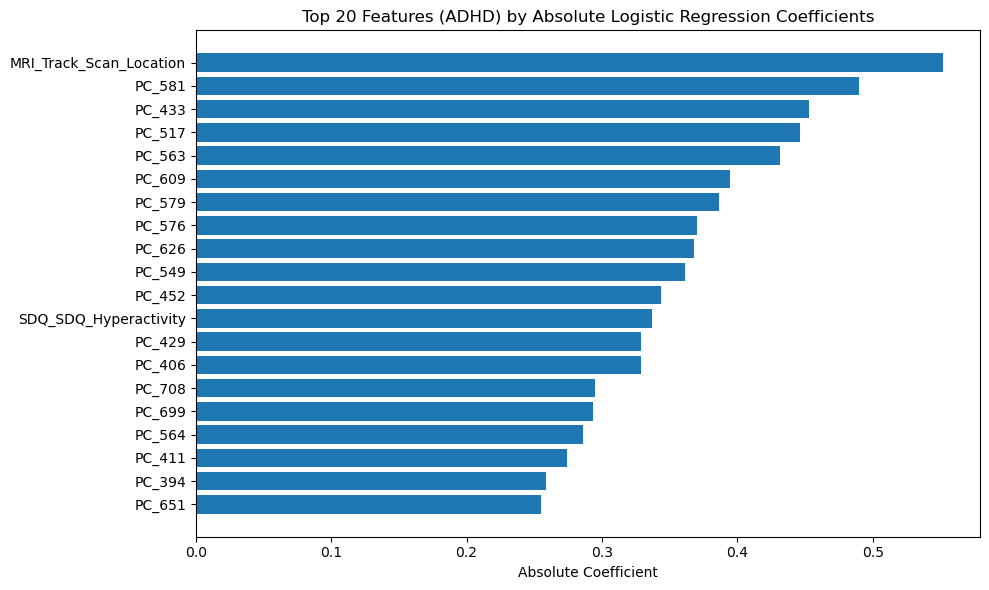

In [607]:
# Fit Logistic Regression model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(solver='liblinear', max_iter=1000)
model.fit(X_filtered, y.iloc[:, 0])  # ADHD target as example

# Get absolute coefficients and their feature names
coefficients = np.abs(model.coef_[0])
features = X_filtered.columns

# Create a DataFrame for easy sorting
coef_df = pd.DataFrame({'Feature': features, 'Absolute_Coefficient': coefficients})
top_coef_df = coef_df.sort_values(by='Absolute_Coefficient', ascending=False).head(20)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(top_coef_df['Feature'][::-1], top_coef_df['Absolute_Coefficient'][::-1])
plt.xlabel('Absolute Coefficient')
plt.title('Top 20 Features (ADHD) by Absolute Logistic Regression Coefficients')
plt.tight_layout()
plt.show()


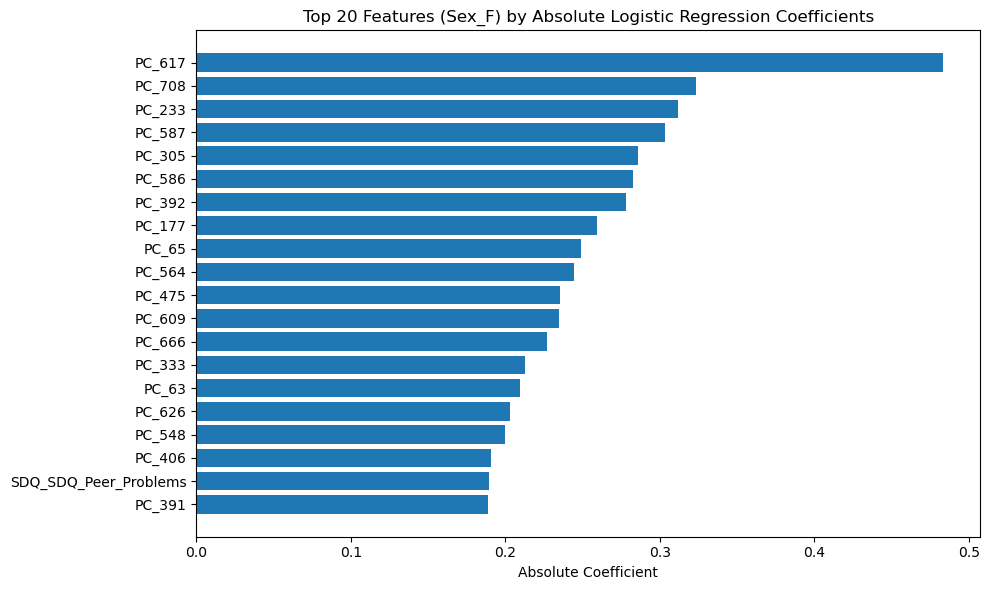

In [609]:
# Fit Logistic Regression model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(solver='liblinear', max_iter=1000)
model.fit(X_filtered, y.iloc[:, 1])  # SeX_F target as example

# Get absolute coefficients and their feature names
coefficients = np.abs(model.coef_[0])
features = X_filtered.columns

# Create a DataFrame for easy sorting
coef_df = pd.DataFrame({'Feature': features, 'Absolute_Coefficient': coefficients})
top_coef_df = coef_df.sort_values(by='Absolute_Coefficient', ascending=False).head(20)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(top_coef_df['Feature'][::-1], top_coef_df['Absolute_Coefficient'][::-1])
plt.xlabel('Absolute Coefficient')
plt.title('Top 20 Features (Sex_F) by Absolute Logistic Regression Coefficients')
plt.tight_layout()
plt.show()


In [621]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
import pandas as pd

# Initialize the model
estimator = LogisticRegression(solver='liblinear', penalty='l2', max_iter=1000)

# 1. Fit RFE on ADHD target
rfe_adhd = RFE(estimator=estimator, n_features_to_select=100)
rfe_adhd.fit(X_filtered, y.iloc[:, 0])
features_adhd = X_filtered.columns[rfe_adhd.get_support()]
ranks_adhd = rfe_adhd.ranking_[rfe_adhd.get_support()]
adhd_df = pd.DataFrame({'Feature': features_adhd, 'Rank_ADHD': ranks_adhd})

# 2. Fit RFE on Sex target
rfe_sex = RFE(estimator=estimator, n_features_to_select=100)
rfe_sex.fit(X_filtered, y.iloc[:, 1])
features_sex = X_filtered.columns[rfe_sex.get_support()]
ranks_sex = rfe_sex.ranking_[rfe_sex.get_support()]
sex_df = pd.DataFrame({'Feature': features_sex, 'Rank_Sex': ranks_sex})


In [622]:
# 3. Find common features
common_features_RFEl2 = set(features_adhd).intersection(set(features_sex))

# 4. Merge and display scores (variation 2)
common_df = pd.merge(adhd_df, sex_df, on='Feature')
print(" Common Selected Features by RFE:")
print(common_df.sort_values(by=['Rank_ADHD', 'Rank_Sex']))

# 5. Only names (variation 1)
print("\n Common Feature Names:")
print(list(common_df['Feature']))
print(common_df.shape)

 Common Selected Features by RFE:
                  Feature  Rank_ADHD  Rank_Sex
0                  PC_701          1         1
1                  PC_708          1         1
2                  PC_679          1         1
3                  PC_275          1         1
4                  PC_587          1         1
5                   PC_65          1         1
6                  PC_552          1         1
7                  PC_141          1         1
8                  PC_391          1         1
9                  PC_452          1         1
10                 PC_149          1         1
11                 PC_491          1         1
12                 PC_619          1         1
13                 PC_403          1         1
14                 PC_178          1         1
15                 PC_507          1         1
16                 PC_240          1         1
17                 PC_664          1         1
18                 PC_166          1         1
19                 PC_350 

In [625]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
import pandas as pd

# Initialize the model
estimator = LogisticRegression(solver='liblinear', penalty='l1', max_iter=1000)

# 1. Fit RFE on ADHD target
rfe_adhd = RFE(estimator=estimator, n_features_to_select=100)
rfe_adhd.fit(X_filtered, y.iloc[:, 0])
features_adhd = X_filtered.columns[rfe_adhd.get_support()]
ranks_adhd = rfe_adhd.ranking_[rfe_adhd.get_support()]
adhd_df = pd.DataFrame({'Feature': features_adhd, 'Rank_ADHD': ranks_adhd})

# 2. Fit RFE on Sex target
rfe_sex = RFE(estimator=estimator, n_features_to_select=100)
rfe_sex.fit(X_filtered, y.iloc[:, 1])
features_sex = X_filtered.columns[rfe_sex.get_support()]
ranks_sex = rfe_sex.ranking_[rfe_sex.get_support()]
sex_df = pd.DataFrame({'Feature': features_sex, 'Rank_Sex': ranks_sex})


In [626]:
# 3. Find common features
common_features_RFEl1 = set(features_adhd).intersection(set(features_sex))

# 4. Merge and display scores (variation 2)
common_df = pd.merge(adhd_df, sex_df, on='Feature')
print(" Common Selected Features by RFE:")
print(common_df.sort_values(by=['Rank_ADHD', 'Rank_Sex']))

# 5. Only names (variation 1)
print("\n Common Feature Names:")
print(list(common_df['Feature']))
print(common_df.shape)

 Common Selected Features by RFE:
   Feature  Rank_ADHD  Rank_Sex
0   PC_701          1         1
1   PC_708          1         1
2   PC_275          1         1
3    PC_65          1         1
4   PC_552          1         1
..     ...        ...       ...
57  PC_270          1         1
58  PC_586          1         1
59  PC_548          1         1
60  PC_412          1         1
61  PC_481          1         1

[62 rows x 3 columns]

 Common Feature Names:
['PC_701', 'PC_708', 'PC_275', 'PC_65', 'PC_552', 'PC_141', 'PC_391', 'PC_452', 'PC_149', 'PC_491', 'PC_619', 'PC_403', 'PC_178', 'PC_507', 'PC_240', 'PC_664', 'PC_333', 'PC_124', 'PC_166', 'PC_350', 'PC_633', 'PC_185', 'SDQ_SDQ_Peer_Problems', 'PC_626', 'PC_666', 'PC_609', 'PC_683', 'Basic_Demos_Study_Site', 'PC_226', 'PC_651', 'PC_581', 'PC_600', 'SDQ_SDQ_Hyperactivity', 'PC_433', 'PC_680', 'PC_305', 'PC_504', 'PC_232', 'PC_604', 'PC_406', 'PC_182', 'PC_438', 'PC_285', 'PC_158', 'PC_564', 'PC_243', 'PC_563', 'PC_125', 'PC_525',

## Scaling

In [130]:
scaler = StandardScaler()
X_scaled = StandardScaler().fit_transform(X_filtered)
X_scaled_df = pd.DataFrame(X_scaled, columns=X_filtered.columns)

# Train-Test-Split

In [166]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.3, random_state=42)
print(f"X_train.shape {X_train.shape}          y_train.shape {y_train.shape} ")
print(f"X_test.shape {X_test.shape}            y_test.shape {y_test.shape} ")

X_train.shape (849, 171)          y_train.shape (849, 2) 
X_test.shape (364, 171)            y_test.shape (364, 2) 


# Models

In [447]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import GridSearchCV
import joblib
import time
import os
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import KFold
from sklearn.metrics import RocCurveDisplay
from sklearn.ensemble import RandomForestClassifier


## KNN

In [324]:
knn = KNeighborsClassifier()
multi_knn = MultiOutputClassifier(knn)

In [325]:
k_values = list(range(1,20))
param_grid = {
    'estimator__n_neighbors': k_values,
    'estimator__weights': ['uniform', 'distance'],
    'estimator__p': [1, 2]  # p=1 for Manhattan, p=2 for Euclidean
}

### accuracy

In [327]:
grid_search = GridSearchCV(multi_knn, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=2)

In [328]:
# Specify the file path where the grid search results are saved
file_path = "Models/feature selection/(grid_search)multi_knn_scoring=accuracy.pkl"

# Check if the file exists
if os.path.exists(file_path):
    print("Model exists")
    # Load the saved GridSearchCV object from the file
    grid_search = joblib.load(file_path)
    print("Model loaded")
else:
    print("Model Does not exist")
    # Start time measurement
    start_time = time.time()

    grid_search.fit(X_train, y_train)
    # End time measurement
    end_time = time.time()
    # Save the GridSearchCV object to a file
    joblib.dump(grid_search, file_path)
    time_taken=end_time-start_time
    print("Model Saved")
    hours, remainder = divmod(time_taken, 3600)
    minutes, seconds = divmod(remainder, 60)

    # Print the result
    print("Time taken: {} hours, {} minutes, {} seconds".format(int(hours), int(minutes), int(seconds)))

Model Does not exist
Fitting 5 folds for each of 76 candidates, totalling 380 fits
Model Saved
Time taken: 0 hours, 0 minutes, 8 seconds


In [329]:
best_model = grid_search.best_estimator_
best_model

MultiOutputClassifier(estimator=KNeighborsClassifier(n_neighbors=19, p=1))

In [330]:
best_model.get_params()

{'estimator__algorithm': 'auto',
 'estimator__leaf_size': 30,
 'estimator__metric': 'minkowski',
 'estimator__metric_params': None,
 'estimator__n_jobs': None,
 'estimator__n_neighbors': 19,
 'estimator__p': 1,
 'estimator__weights': 'uniform',
 'estimator': KNeighborsClassifier(n_neighbors=19, p=1),
 'n_jobs': None}

In [331]:
print("Best score:", grid_search.best_score_)

Best score: 0.4499477897667942


In [332]:
# Predict
y_pred = best_model.predict(X_test)

# Loop over each target
for i, target_name in enumerate(y_test.columns):
    print(f"\n--- Classification Report for Target: {target_name} ---")
    print(classification_report(y_test.iloc[:, i], y_pred[:, i]))



--- Classification Report for Target: ADHD_Outcome ---
              precision    recall  f1-score   support

           0       0.53      0.73      0.62       121
           1       0.83      0.68      0.75       243

    accuracy                           0.70       364
   macro avg       0.68      0.71      0.68       364
weighted avg       0.73      0.70      0.71       364


--- Classification Report for Target: Sex_F ---
              precision    recall  f1-score   support

           0       0.70      0.95      0.80       254
           1       0.32      0.05      0.09       110

    accuracy                           0.68       364
   macro avg       0.51      0.50      0.45       364
weighted avg       0.58      0.68      0.59       364



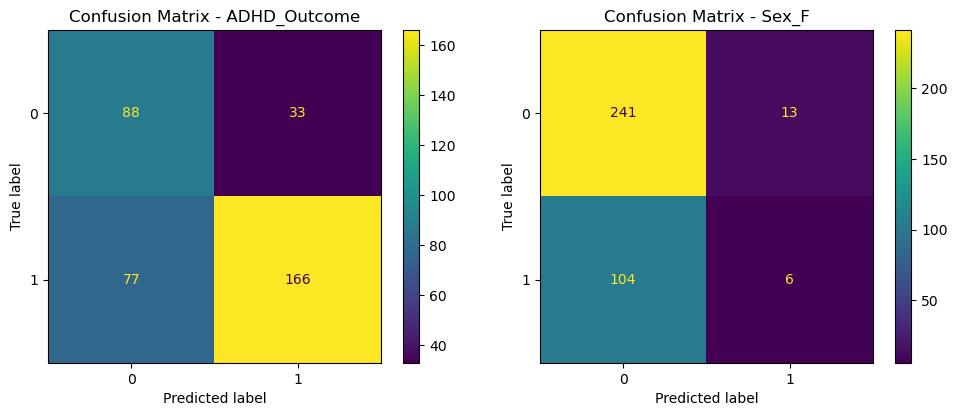

In [333]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

for i, (ax, target_name) in enumerate(zip(axes, y_test.columns)):
    ConfusionMatrixDisplay.from_predictions(
        y_test.iloc[:, i],
        y_pred[:, i],
        ax=ax,
    )
    ax.set_title(f"Confusion Matrix - {target_name}")
    ax.grid(False)

plt.tight_layout()
plt.show()

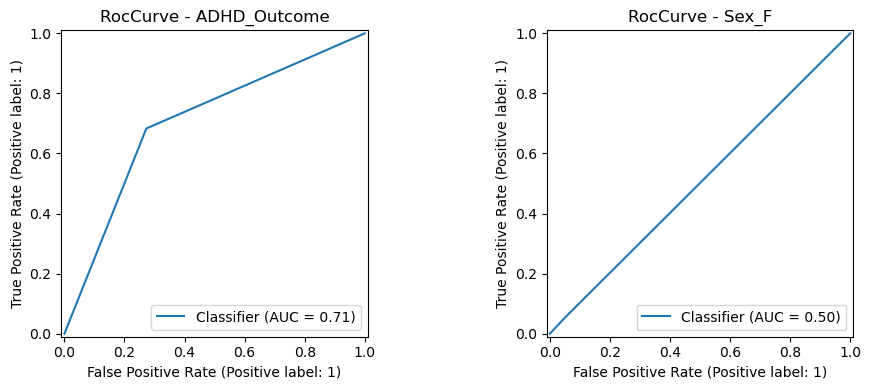

In [334]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

for i, (ax, target_name) in enumerate(zip(axes, y_test.columns)):
    RocCurveDisplay.from_predictions(
        y_test.iloc[:, i],
        y_pred[:, i],
        ax=ax,
    )
    ax.set_title(f"RocCurve - {target_name}")
    ax.grid(False)

plt.tight_layout()
plt.show()

### multi_output_scorer

In [336]:
grid_search = GridSearchCV(multi_knn, param_grid, cv=5, scoring=multi_output_scorer, n_jobs=-1, verbose=2)

In [337]:
# Specify the file path where the grid search results are saved
file_path = "Models/feature selection/(grid_search)multi_knn_scoring=multi_output_scorer.pkl"

# Check if the file exists
if os.path.exists(file_path):
    print("Model exists")
    # Load the saved GridSearchCV object from the file
    grid_search = joblib.load(file_path)
    print("Model loaded")
else:
    print("Model Does not exist")
    # Start time measurement
    start_time = time.time()

    grid_search.fit(X_train, y_train)
    # End time measurement
    end_time = time.time()
    # Save the GridSearchCV object to a file
    joblib.dump(grid_search, file_path)
    time_taken=end_time-start_time
    print("Model Saved")
    hours, remainder = divmod(time_taken, 3600)
    minutes, seconds = divmod(remainder, 60)

    # Print the result
    print("Time taken: {} hours, {} minutes, {} seconds".format(int(hours), int(minutes), int(seconds)))

Model Does not exist
Fitting 5 folds for each of 76 candidates, totalling 380 fits
Model Saved
Time taken: 0 hours, 0 minutes, 3 seconds


In [338]:
best_model = grid_search.best_estimator_
best_model

MultiOutputClassifier(estimator=KNeighborsClassifier(n_neighbors=19, p=1))

In [339]:
best_model.get_params()

{'estimator__algorithm': 'auto',
 'estimator__leaf_size': 30,
 'estimator__metric': 'minkowski',
 'estimator__metric_params': None,
 'estimator__n_jobs': None,
 'estimator__n_neighbors': 19,
 'estimator__p': 1,
 'estimator__weights': 'uniform',
 'estimator': KNeighborsClassifier(n_neighbors=19, p=1),
 'n_jobs': None}

In [340]:
print("Best score:", grid_search.best_score_)

Best score: 0.6725791855203621


In [341]:
# Predict
y_pred = best_model.predict(X_test)

# Loop over each target
for i, target_name in enumerate(y_test.columns):
    print(f"\n--- Classification Report for Target: {target_name} ---")
    print(classification_report(y_test.iloc[:, i], y_pred[:, i]))



--- Classification Report for Target: ADHD_Outcome ---
              precision    recall  f1-score   support

           0       0.53      0.73      0.62       121
           1       0.83      0.68      0.75       243

    accuracy                           0.70       364
   macro avg       0.68      0.71      0.68       364
weighted avg       0.73      0.70      0.71       364


--- Classification Report for Target: Sex_F ---
              precision    recall  f1-score   support

           0       0.70      0.95      0.80       254
           1       0.32      0.05      0.09       110

    accuracy                           0.68       364
   macro avg       0.51      0.50      0.45       364
weighted avg       0.58      0.68      0.59       364



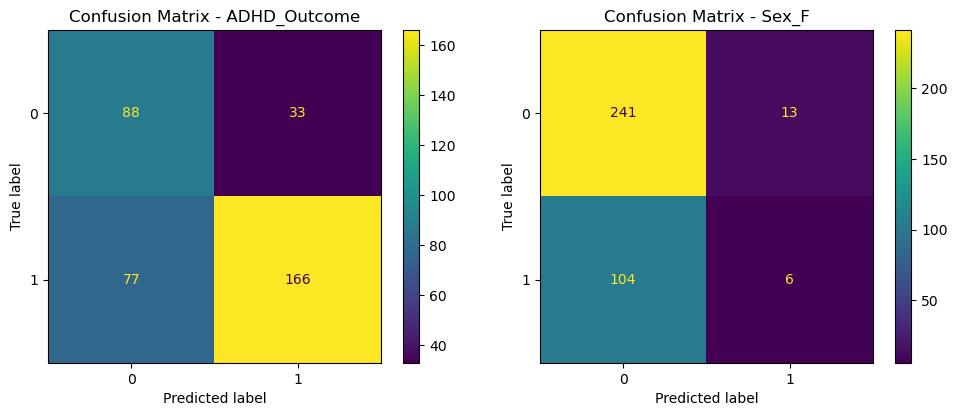

In [342]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

for i, (ax, target_name) in enumerate(zip(axes, y_test.columns)):
    ConfusionMatrixDisplay.from_predictions(
        y_test.iloc[:, i],
        y_pred[:, i],
        ax=ax,
    )
    ax.set_title(f"Confusion Matrix - {target_name}")
    ax.grid(False)

plt.tight_layout()
plt.show()

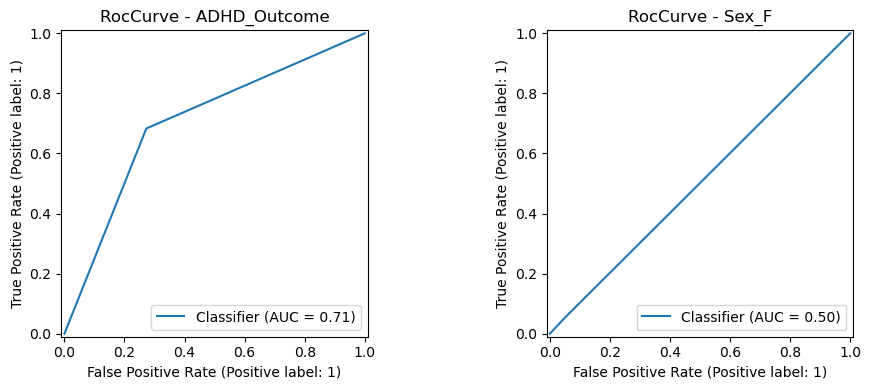

In [343]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

for i, (ax, target_name) in enumerate(zip(axes, y_test.columns)):
    RocCurveDisplay.from_predictions(
        y_test.iloc[:, i],
        y_pred[:, i],
        ax=ax,
    )
    ax.set_title(f"RocCurve - {target_name}")
    ax.grid(False)

plt.tight_layout()
plt.show()

### F1 Score

In [345]:
rid_search = GridSearchCV(multi_knn, param_grid, cv=5, scoring='f1_macro', n_jobs=-1, verbose=2)

In [346]:
# Specify the file path where the grid search results are saved
file_path = "Models/feature selection/(grid_search)multi_knn_scoring=f1_macro.pkl"

# Check if the file exists
if os.path.exists(file_path):
    print("Model exists")
    # Load the saved GridSearchCV object from the file
    grid_search = joblib.load(file_path)
    print("Model loaded")
else:
    print("Model Does not exist")
    # Start time measurement
    start_time = time.time()

    grid_search.fit(X_train, y_train)
    # End time measurement
    end_time = time.time()
    # Save the GridSearchCV object to a file
    joblib.dump(grid_search, file_path)
    time_taken=end_time-start_time
    print("Model Saved")
    hours, remainder = divmod(time_taken, 3600)
    minutes, seconds = divmod(remainder, 60)

    # Print the result
    print("Time taken: {} hours, {} minutes, {} seconds".format(int(hours), int(minutes), int(seconds)))

Model Does not exist
Fitting 5 folds for each of 76 candidates, totalling 380 fits
Model Saved
Time taken: 0 hours, 0 minutes, 3 seconds


In [347]:
best_model = grid_search.best_estimator_
best_model

MultiOutputClassifier(estimator=KNeighborsClassifier(n_neighbors=19, p=1))

In [348]:
best_model.get_params()

{'estimator__algorithm': 'auto',
 'estimator__leaf_size': 30,
 'estimator__metric': 'minkowski',
 'estimator__metric_params': None,
 'estimator__n_jobs': None,
 'estimator__n_neighbors': 19,
 'estimator__p': 1,
 'estimator__weights': 'uniform',
 'estimator': KNeighborsClassifier(n_neighbors=19, p=1),
 'n_jobs': None}

In [349]:
print("Best score:", grid_search.best_score_)

Best score: 0.6725791855203621


In [350]:
# Predict
y_pred = best_model.predict(X_test)

# Loop over each target
for i, target_name in enumerate(y_test.columns):
    print(f"\n--- Classification Report for Target: {target_name} ---")
    print(classification_report(y_test.iloc[:, i], y_pred[:, i]))



--- Classification Report for Target: ADHD_Outcome ---
              precision    recall  f1-score   support

           0       0.53      0.73      0.62       121
           1       0.83      0.68      0.75       243

    accuracy                           0.70       364
   macro avg       0.68      0.71      0.68       364
weighted avg       0.73      0.70      0.71       364


--- Classification Report for Target: Sex_F ---
              precision    recall  f1-score   support

           0       0.70      0.95      0.80       254
           1       0.32      0.05      0.09       110

    accuracy                           0.68       364
   macro avg       0.51      0.50      0.45       364
weighted avg       0.58      0.68      0.59       364



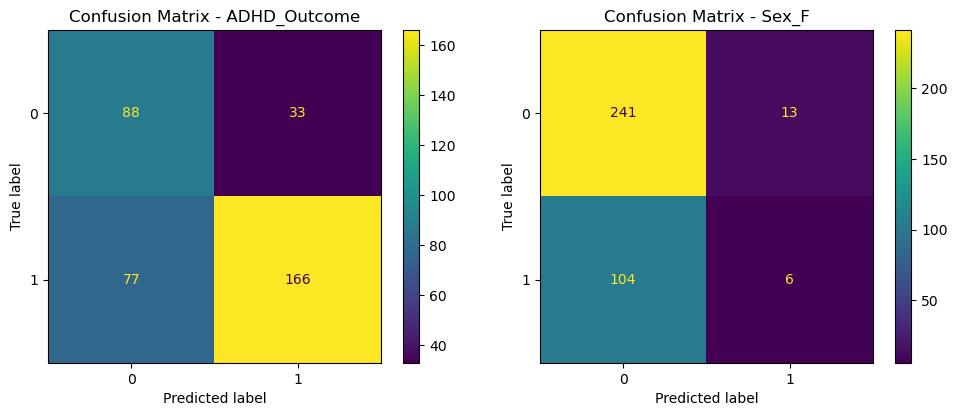

In [351]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

for i, (ax, target_name) in enumerate(zip(axes, y_test.columns)):
    ConfusionMatrixDisplay.from_predictions(
        y_test.iloc[:, i],
        y_pred[:, i],
        ax=ax,
    )
    ax.set_title(f"Confusion Matrix - {target_name}")
    ax.grid(False)

plt.tight_layout()
plt.show()

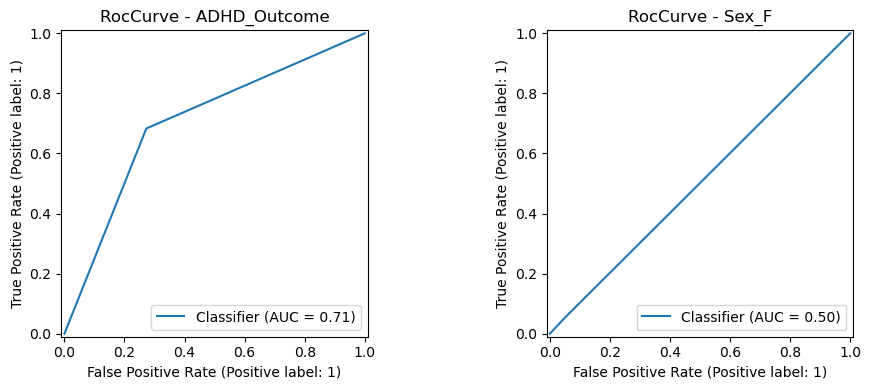

In [352]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

for i, (ax, target_name) in enumerate(zip(axes, y_test.columns)):
    RocCurveDisplay.from_predictions(
        y_test.iloc[:, i],
        y_pred[:, i],
        ax=ax,
    )
    ax.set_title(f"RocCurve - {target_name}")
    ax.grid(False)

plt.tight_layout()
plt.show()

## Decision Trees

In [354]:
model = DecisionTreeClassifier(random_state=42)
multi_DT = MultiOutputClassifier(model)

In [355]:
param_grid = {
    'estimator__max_depth': [3, 5, 10, None],
    'estimator__min_samples_split': [2, 5],
    'estimator__min_samples_leaf': [1, 2],
    'estimator__max_features': ['sqrt', 'log2', None],
    'estimator__criterion': ['gini', 'entropy'],
    'estimator__class_weight': [None, 'balanced'],
}


### accuracy

In [357]:
grid_search = GridSearchCV(multi_DT, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=2)

In [358]:
# Specify the file path where the grid search results are saved
file_path = "Models/feature selection/(grid_search)multi_DT_scoring=accuracy.pkl"

# Check if the file exists
if os.path.exists(file_path):
    print("Model exists")
    # Load the saved GridSearchCV object from the file
    grid_search = joblib.load(file_path)
    print("Model loaded")
else:
    print("Model Does not exist")
    # Start time measurement
    start_time = time.time()

    grid_search.fit(X_train, y_train)
    # End time measurement
    end_time = time.time()
    # Save the GridSearchCV object to a file
    joblib.dump(grid_search, file_path)
    time_taken=end_time-start_time
    print("Model Saved")
    hours, remainder = divmod(time_taken, 3600)
    minutes, seconds = divmod(remainder, 60)

    # Print the result
    print("Time taken: {} hours, {} minutes, {} seconds".format(int(hours), int(minutes), int(seconds)))

Model Does not exist
Fitting 5 folds for each of 192 candidates, totalling 960 fits
Model Saved
Time taken: 0 hours, 0 minutes, 8 seconds


In [359]:
best_model = grid_search.best_estimator_
best_model

MultiOutputClassifier(estimator=DecisionTreeClassifier(criterion='entropy',
                                                       max_depth=3,
                                                       max_features='sqrt',
                                                       random_state=42))

In [360]:
best_model.get_params()

{'estimator__ccp_alpha': 0.0,
 'estimator__class_weight': None,
 'estimator__criterion': 'entropy',
 'estimator__max_depth': 3,
 'estimator__max_features': 'sqrt',
 'estimator__max_leaf_nodes': None,
 'estimator__min_impurity_decrease': 0.0,
 'estimator__min_samples_leaf': 1,
 'estimator__min_samples_split': 2,
 'estimator__min_weight_fraction_leaf': 0.0,
 'estimator__monotonic_cst': None,
 'estimator__random_state': 42,
 'estimator__splitter': 'best',
 'estimator': DecisionTreeClassifier(criterion='entropy', max_depth=3, max_features='sqrt',
                        random_state=42),
 'n_jobs': None}

In [361]:
print("Best score:", grid_search.best_score_)

Best score: 0.47356073790462927


In [362]:
# Predict
y_pred = best_model.predict(X_test)

# Loop over each target
for i, target_name in enumerate(y_test.columns):
    print(f"\n--- Classification Report for Target: {target_name} ---")
    print(classification_report(y_test.iloc[:, i], y_pred[:, i]))



--- Classification Report for Target: ADHD_Outcome ---
              precision    recall  f1-score   support

           0       0.63      0.64      0.63       121
           1       0.82      0.81      0.81       243

    accuracy                           0.75       364
   macro avg       0.72      0.72      0.72       364
weighted avg       0.75      0.75      0.75       364


--- Classification Report for Target: Sex_F ---
              precision    recall  f1-score   support

           0       0.72      0.88      0.79       254
           1       0.42      0.20      0.27       110

    accuracy                           0.68       364
   macro avg       0.57      0.54      0.53       364
weighted avg       0.63      0.68      0.63       364



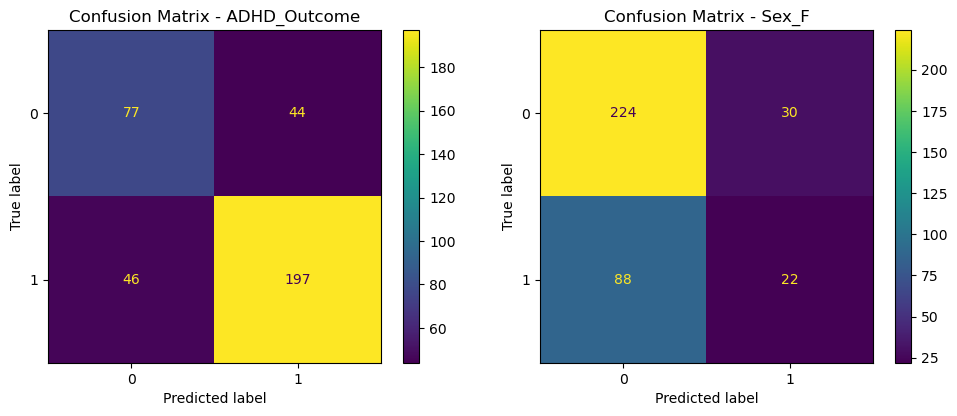

In [363]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

for i, (ax, target_name) in enumerate(zip(axes, y_test.columns)):
    ConfusionMatrixDisplay.from_predictions(
        y_test.iloc[:, i],
        y_pred[:, i],
        ax=ax,
    )
    ax.set_title(f"Confusion Matrix - {target_name}")
    ax.grid(False)

plt.tight_layout()
plt.show()

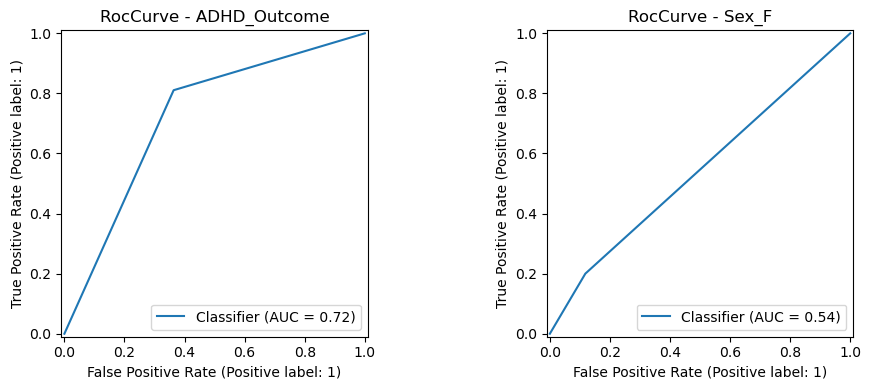

In [364]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

for i, (ax, target_name) in enumerate(zip(axes, y_test.columns)):
    RocCurveDisplay.from_predictions(
        y_test.iloc[:, i],
        y_pred[:, i],
        ax=ax,
    )
    ax.set_title(f"RocCurve - {target_name}")
    ax.grid(False)

plt.tight_layout()
plt.show()

### multi_output_scorer

In [366]:
grid_search = GridSearchCV(multi_DT, param_grid, cv=5, scoring=multi_output_scorer, n_jobs=-1, verbose=2)

In [367]:
# Specify the file path where the grid search results are saved
file_path = "Models/feature selection/(grid_search)multi_DT_scoring=multi_output_scorer.pkl"

# Check if the file exists
if os.path.exists(file_path):
    print("Model exists")
    # Load the saved GridSearchCV object from the file
    grid_search = joblib.load(file_path)
    print("Model loaded")
else:
    print("Model Does not exist")
    # Start time measurement
    start_time = time.time()

    grid_search.fit(X_train, y_train)
    # End time measurement
    end_time = time.time()
    # Save the GridSearchCV object to a file
    joblib.dump(grid_search, file_path)
    time_taken=end_time-start_time
    print("Model Saved")
    hours, remainder = divmod(time_taken, 3600)
    minutes, seconds = divmod(remainder, 60)

    # Print the result
    print("Time taken: {} hours, {} minutes, {} seconds".format(int(hours), int(minutes), int(seconds)))

Model Does not exist
Fitting 5 folds for each of 192 candidates, totalling 960 fits
Model Saved
Time taken: 0 hours, 0 minutes, 9 seconds


In [368]:
best_model = grid_search.best_estimator_
best_model

MultiOutputClassifier(estimator=DecisionTreeClassifier(criterion='entropy',
                                                       max_depth=3,
                                                       max_features='sqrt',
                                                       random_state=42))

In [369]:
best_model.get_params()

{'estimator__ccp_alpha': 0.0,
 'estimator__class_weight': None,
 'estimator__criterion': 'entropy',
 'estimator__max_depth': 3,
 'estimator__max_features': 'sqrt',
 'estimator__max_leaf_nodes': None,
 'estimator__min_impurity_decrease': 0.0,
 'estimator__min_samples_leaf': 1,
 'estimator__min_samples_split': 2,
 'estimator__min_weight_fraction_leaf': 0.0,
 'estimator__monotonic_cst': None,
 'estimator__random_state': 42,
 'estimator__splitter': 'best',
 'estimator': DecisionTreeClassifier(criterion='entropy', max_depth=3, max_features='sqrt',
                        random_state=42),
 'n_jobs': None}

In [370]:
print("Best score:", grid_search.best_score_)

Best score: 0.6849634528367561


In [371]:
# Predict
y_pred = best_model.predict(X_test)

# Loop over each target
for i, target_name in enumerate(y_test.columns):
    print(f"\n--- Classification Report for Target: {target_name} ---")
    print(classification_report(y_test.iloc[:, i], y_pred[:, i]))



--- Classification Report for Target: ADHD_Outcome ---
              precision    recall  f1-score   support

           0       0.63      0.64      0.63       121
           1       0.82      0.81      0.81       243

    accuracy                           0.75       364
   macro avg       0.72      0.72      0.72       364
weighted avg       0.75      0.75      0.75       364


--- Classification Report for Target: Sex_F ---
              precision    recall  f1-score   support

           0       0.72      0.88      0.79       254
           1       0.42      0.20      0.27       110

    accuracy                           0.68       364
   macro avg       0.57      0.54      0.53       364
weighted avg       0.63      0.68      0.63       364



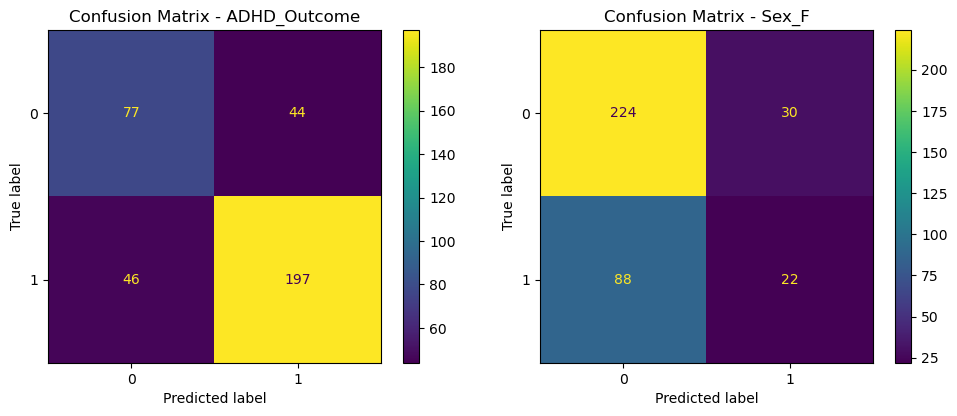

In [372]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

for i, (ax, target_name) in enumerate(zip(axes, y_test.columns)):
    ConfusionMatrixDisplay.from_predictions(
        y_test.iloc[:, i],
        y_pred[:, i],
        ax=ax,
    )
    ax.set_title(f"Confusion Matrix - {target_name}")
    ax.grid(False)

plt.tight_layout()
plt.show()

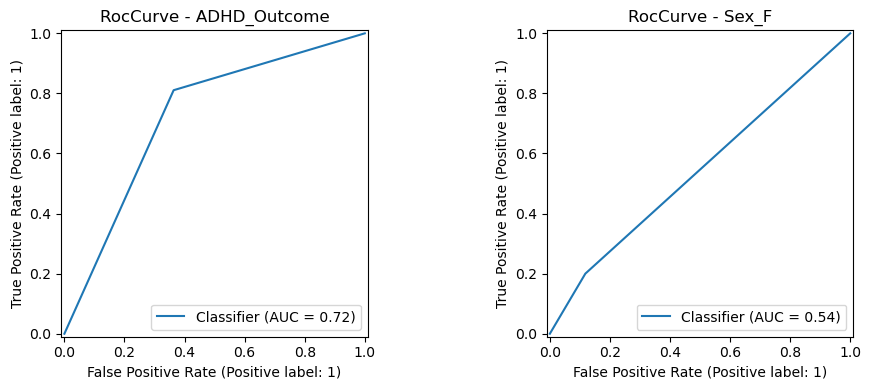

In [373]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

for i, (ax, target_name) in enumerate(zip(axes, y_test.columns)):
    RocCurveDisplay.from_predictions(
        y_test.iloc[:, i],
        y_pred[:, i],
        ax=ax,
    )
    ax.set_title(f"RocCurve - {target_name}")
    ax.grid(False)

plt.tight_layout()
plt.show()

### f1_macro

In [375]:
grid_search = GridSearchCV(multi_DT, param_grid, cv=5, scoring='f1_macro', n_jobs=-1, verbose=2)

In [376]:
# Specify the file path where the grid search results are saved
file_path = "Models/feature selection/(grid_search)multi_DT_scoring=f1_macro.pkl"

# Check if the file exists
if os.path.exists(file_path):
    print("Model exists")
    # Load the saved GridSearchCV object from the file
    grid_search = joblib.load(file_path)
    print("Model loaded")
else:
    print("Model Does not exist")
    # Start time measurement
    start_time = time.time()

    grid_search.fit(X_train, y_train)
    # End time measurement
    end_time = time.time()
    # Save the GridSearchCV object to a file
    joblib.dump(grid_search, file_path)
    time_taken=end_time-start_time
    print("Model Saved")
    hours, remainder = divmod(time_taken, 3600)
    minutes, seconds = divmod(remainder, 60)

    # Print the result
    print("Time taken: {} hours, {} minutes, {} seconds".format(int(hours), int(minutes), int(seconds)))

Model Does not exist
Fitting 5 folds for each of 192 candidates, totalling 960 fits
Model Saved
Time taken: 0 hours, 0 minutes, 8 seconds


In [377]:
best_model = grid_search.best_estimator_
best_model

MultiOutputClassifier(estimator=DecisionTreeClassifier(class_weight='balanced',
                                                       max_depth=3,
                                                       random_state=42))

In [378]:
best_model.get_params()

{'estimator__ccp_alpha': 0.0,
 'estimator__class_weight': 'balanced',
 'estimator__criterion': 'gini',
 'estimator__max_depth': 3,
 'estimator__max_features': None,
 'estimator__max_leaf_nodes': None,
 'estimator__min_impurity_decrease': 0.0,
 'estimator__min_samples_leaf': 1,
 'estimator__min_samples_split': 2,
 'estimator__min_weight_fraction_leaf': 0.0,
 'estimator__monotonic_cst': None,
 'estimator__random_state': 42,
 'estimator__splitter': 'best',
 'estimator': DecisionTreeClassifier(class_weight='balanced', max_depth=3, random_state=42),
 'n_jobs': None}

In [379]:
print("Best score:", grid_search.best_score_)

Best score: 0.6585016684141026


In [380]:
# Predict
y_pred = best_model.predict(X_test)

# Loop over each target
for i, target_name in enumerate(y_test.columns):
    print(f"\n--- Classification Report for Target: {target_name} ---")
    print(classification_report(y_test.iloc[:, i], y_pred[:, i]))



--- Classification Report for Target: ADHD_Outcome ---
              precision    recall  f1-score   support

           0       0.63      0.74      0.68       121
           1       0.86      0.79      0.82       243

    accuracy                           0.77       364
   macro avg       0.74      0.76      0.75       364
weighted avg       0.78      0.77      0.77       364


--- Classification Report for Target: Sex_F ---
              precision    recall  f1-score   support

           0       0.68      0.46      0.55       254
           1       0.29      0.51      0.37       110

    accuracy                           0.48       364
   macro avg       0.49      0.48      0.46       364
weighted avg       0.57      0.48      0.50       364



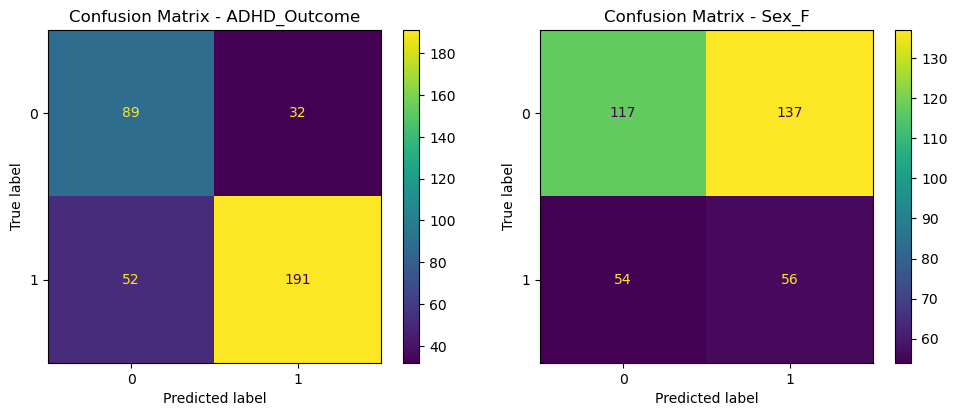

In [381]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

for i, (ax, target_name) in enumerate(zip(axes, y_test.columns)):
    ConfusionMatrixDisplay.from_predictions(
        y_test.iloc[:, i],
        y_pred[:, i],
        ax=ax,
    )
    ax.set_title(f"Confusion Matrix - {target_name}")
    ax.grid(False)

plt.tight_layout()
plt.show()

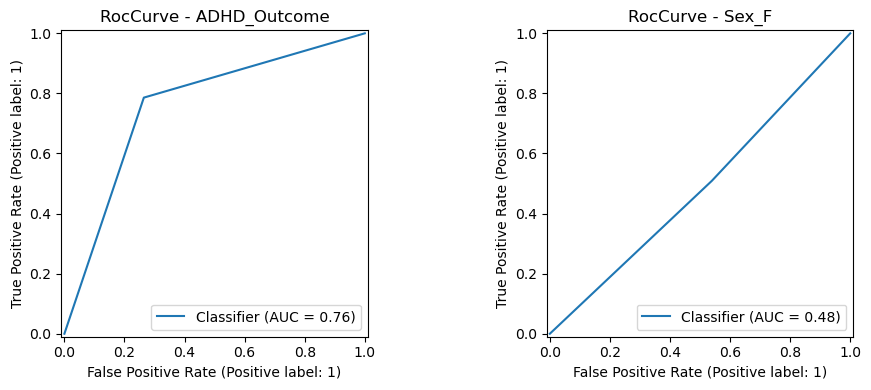

In [382]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

for i, (ax, target_name) in enumerate(zip(axes, y_test.columns)):
    RocCurveDisplay.from_predictions(
        y_test.iloc[:, i],
        y_pred[:, i],
        ax=ax,
    )
    ax.set_title(f"RocCurve - {target_name}")
    ax.grid(False)

plt.tight_layout()
plt.show()

## Random Forests

In [488]:
RF = RandomForestClassifier(random_state=42)
multi_RF = MultiOutputClassifier(RF)
# Create the parameter grid based on the results of random search 
param_grid = {
    'estimator__n_estimators': [50, 100, 150],
    'estimator__max_depth': [2, 3, 5, 10, 15, 20],
    'estimator__min_samples_leaf': [1, 2, 3, 4, 5],
    'estimator__min_samples_split': [2, 5, 10, 15, 20, 25],
    'estimator__criterion': ['gini', 'entropy']
}

### f1_macro

In [490]:
grid_search = GridSearchCV(multi_RF, param_grid, cv=5, scoring='f1_macro', n_jobs=-1, verbose=2)

In [491]:
# Specify the file path where the grid search results are saved
file_path = "Models/feature selection/(grid_search)multi_RF_scoring=f1_macro.pkl"

# Check if the file exists
if os.path.exists(file_path):
    print("Model exists")
    # Load the saved GridSearchCV object from the file
    grid_search = joblib.load(file_path)
    print("Model loaded")
else:
    print("Model Does not exist")
    # Start time measurement
    start_time = time.time()

    grid_search.fit(X_train, y_train)
    # End time measurement
    end_time = time.time()
    # Save the GridSearchCV object to a file
    joblib.dump(grid_search, file_path)
    time_taken=end_time-start_time
    print("Model Saved")
    hours, remainder = divmod(time_taken, 3600)
    minutes, seconds = divmod(remainder, 60)

    # Print the result
    print("Time taken: {} hours, {} minutes, {} seconds".format(int(hours), int(minutes), int(seconds)))

Model Does not exist
Fitting 5 folds for each of 1080 candidates, totalling 5400 fits
Model Saved
Time taken: 0 hours, 13 minutes, 29 seconds


In [492]:
best_model = grid_search.best_estimator_
best_model

MultiOutputClassifier(estimator=RandomForestClassifier(criterion='entropy',
                                                       max_depth=20,
                                                       min_samples_leaf=2,
                                                       min_samples_split=10,
                                                       n_estimators=50,
                                                       random_state=42))

In [493]:
best_model.get_params()

{'estimator__bootstrap': True,
 'estimator__ccp_alpha': 0.0,
 'estimator__class_weight': None,
 'estimator__criterion': 'entropy',
 'estimator__max_depth': 20,
 'estimator__max_features': 'sqrt',
 'estimator__max_leaf_nodes': None,
 'estimator__max_samples': None,
 'estimator__min_impurity_decrease': 0.0,
 'estimator__min_samples_leaf': 2,
 'estimator__min_samples_split': 10,
 'estimator__min_weight_fraction_leaf': 0.0,
 'estimator__monotonic_cst': None,
 'estimator__n_estimators': 50,
 'estimator__n_jobs': None,
 'estimator__oob_score': False,
 'estimator__random_state': 42,
 'estimator__verbose': 0,
 'estimator__warm_start': False,
 'estimator': RandomForestClassifier(criterion='entropy', max_depth=20, min_samples_leaf=2,
                        min_samples_split=10, n_estimators=50, random_state=42),
 'n_jobs': None}

In [494]:
print("Best score:", grid_search.best_score_)

Best score: 0.4933240691823929


In [495]:
# Predict
y_pred = best_model.predict(X_test)

# Loop over each target
for i, target_name in enumerate(y_test.columns):
    print(f"\n--- Classification Report for Target: {target_name} ---")
    print(classification_report(y_test.iloc[:, i], y_pred[:, i]))



--- Classification Report for Target: ADHD_Outcome ---
              precision    recall  f1-score   support

           0       0.78      0.42      0.55       121
           1       0.77      0.94      0.85       243

    accuracy                           0.77       364
   macro avg       0.78      0.68      0.70       364
weighted avg       0.77      0.77      0.75       364


--- Classification Report for Target: Sex_F ---
              precision    recall  f1-score   support

           0       0.70      1.00      0.82       254
           1       0.67      0.02      0.04       110

    accuracy                           0.70       364
   macro avg       0.68      0.51      0.43       364
weighted avg       0.69      0.70      0.58       364



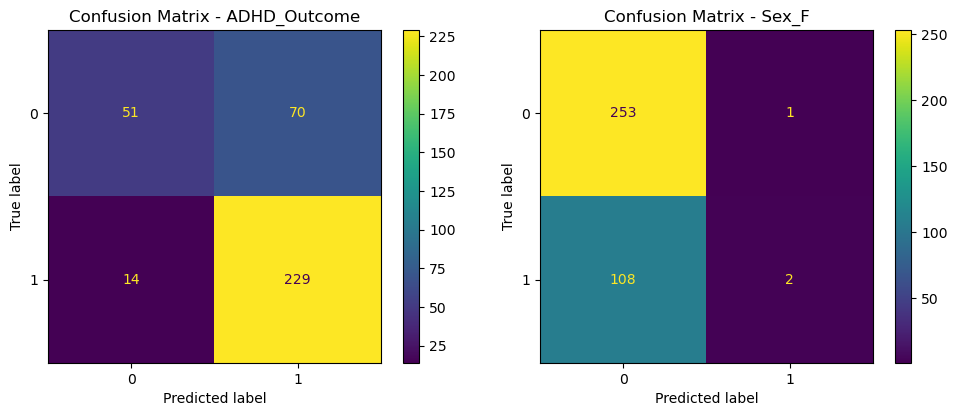

In [496]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

for i, (ax, target_name) in enumerate(zip(axes, y_test.columns)):
    ConfusionMatrixDisplay.from_predictions(
        y_test.iloc[:, i],
        y_pred[:, i],
        ax=ax,
    )
    ax.set_title(f"Confusion Matrix - {target_name}")
    ax.grid(False)

plt.tight_layout()
plt.show()

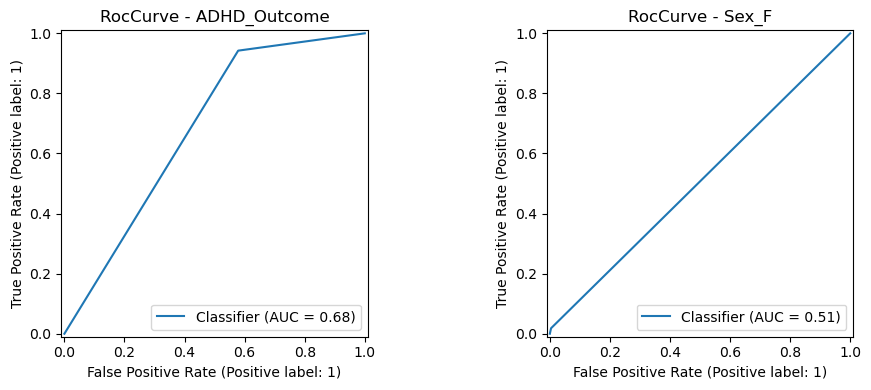

In [497]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

for i, (ax, target_name) in enumerate(zip(axes, y_test.columns)):
    RocCurveDisplay.from_predictions(
        y_test.iloc[:, i],
        y_pred[:, i],
        ax=ax,
    )
    ax.set_title(f"RocCurve - {target_name}")
    ax.grid(False)

plt.tight_layout()
plt.show()

## Logistic Regression

In [541]:
from sklearn.linear_model import LogisticRegression
# Define the model
log_reg = LogisticRegression(solver='liblinear', random_state=42)
multi_log = MultiOutputClassifier(log_reg)

# Define the parameter grid
param_grid = {
    'estimator__penalty': ['l1', 'l2'],
    'estimator__C': [0.001, 0.01, 0.1, 1, 10, 100],  # Regularization strength (lower means stronger regularization)
    'estimator__class_weight': [None, 'balanced']
}

### accuracy

In [543]:
grid_search = GridSearchCV(multi_log, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=2)

In [544]:
# Specify the file path where the grid search results are saved
file_path = "Models/feature selection/(grid_search)multi_log_scoring=accuracy.pkl"

# Check if the file exists
if os.path.exists(file_path):
    print("Model exists")
    # Load the saved GridSearchCV object from the file
    grid_search = joblib.load(file_path)
    print("Model loaded")
else:
    print("Model Does not exist")
    # Start time measurement
    start_time = time.time()

    grid_search.fit(X_train, y_train)
    # End time measurement
    end_time = time.time()
    # Save the GridSearchCV object to a file
    joblib.dump(grid_search, file_path)
    time_taken=end_time-start_time
    print("Model Saved")
    hours, remainder = divmod(time_taken, 3600)
    minutes, seconds = divmod(remainder, 60)

    # Print the result
    print("Time taken: {} hours, {} minutes, {} seconds".format(int(hours), int(minutes), int(seconds)))

Model Does not exist
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Model Saved
Time taken: 0 hours, 0 minutes, 8 seconds


In [545]:
best_model = grid_search.best_estimator_
best_model

MultiOutputClassifier(estimator=LogisticRegression(C=0.1, penalty='l1',
                                                   random_state=42,
                                                   solver='liblinear'))

In [546]:
best_model.get_params()

{'estimator__C': 0.1,
 'estimator__class_weight': None,
 'estimator__dual': False,
 'estimator__fit_intercept': True,
 'estimator__intercept_scaling': 1,
 'estimator__l1_ratio': None,
 'estimator__max_iter': 100,
 'estimator__multi_class': 'auto',
 'estimator__n_jobs': None,
 'estimator__penalty': 'l1',
 'estimator__random_state': 42,
 'estimator__solver': 'liblinear',
 'estimator__tol': 0.0001,
 'estimator__verbose': 0,
 'estimator__warm_start': False,
 'estimator': LogisticRegression(C=0.1, penalty='l1', random_state=42, solver='liblinear'),
 'n_jobs': None}

In [547]:
print("Best score:", grid_search.best_score_)

Best score: 0.5382805429864254


In [548]:
# Predict
y_pred = best_model.predict(X_test)

# Loop over each target
for i, target_name in enumerate(y_test.columns):
    print(f"\n--- Classification Report for Target: {target_name} ---")
    print(classification_report(y_test.iloc[:, i], y_pred[:, i]))



--- Classification Report for Target: ADHD_Outcome ---
              precision    recall  f1-score   support

           0       0.72      0.60      0.65       121
           1       0.82      0.88      0.85       243

    accuracy                           0.79       364
   macro avg       0.77      0.74      0.75       364
weighted avg       0.78      0.79      0.78       364


--- Classification Report for Target: Sex_F ---
              precision    recall  f1-score   support

           0       0.74      0.87      0.80       254
           1       0.50      0.31      0.38       110

    accuracy                           0.70       364
   macro avg       0.62      0.59      0.59       364
weighted avg       0.67      0.70      0.67       364



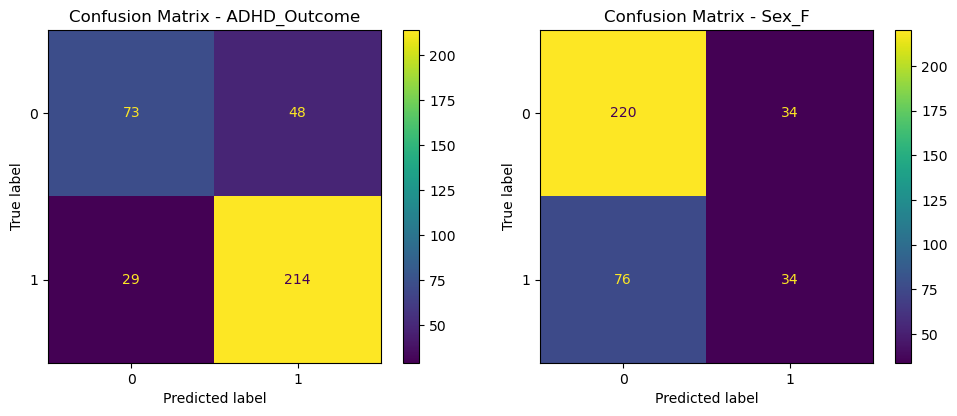

In [549]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

for i, (ax, target_name) in enumerate(zip(axes, y_test.columns)):
    ConfusionMatrixDisplay.from_predictions(
        y_test.iloc[:, i],
        y_pred[:, i],
        ax=ax,
    )
    ax.set_title(f"Confusion Matrix - {target_name}")
    ax.grid(False)

plt.tight_layout()
plt.show()

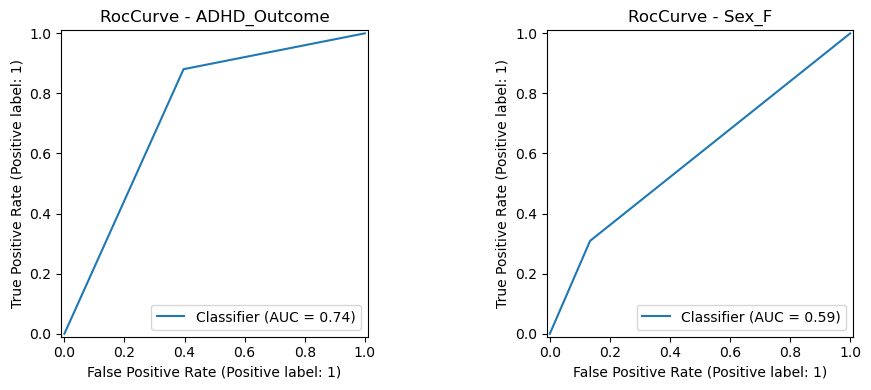

In [550]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

for i, (ax, target_name) in enumerate(zip(axes, y_test.columns)):
    RocCurveDisplay.from_predictions(
        y_test.iloc[:, i],
        y_pred[:, i],
        ax=ax,
    )
    ax.set_title(f"RocCurve - {target_name}")
    ax.grid(False)

plt.tight_layout()
plt.show()

### multi_output_scorer

In [552]:
grid_search = GridSearchCV(multi_log, param_grid, cv=5, scoring=multi_output_scorer, n_jobs=-1, verbose=2)

In [553]:
# Specify the file path where the grid search results are saved
file_path = "Models/feature selection/(grid_search)multi_log_scoring=multi_output_scorer.pkl"

# Check if the file exists
if os.path.exists(file_path):
    print("Model exists")
    # Load the saved GridSearchCV object from the file
    grid_search = joblib.load(file_path)
    print("Model loaded")
else:
    print("Model Does not exist")
    # Start time measurement
    start_time = time.time()

    grid_search.fit(X_train, y_train)
    # End time measurement
    end_time = time.time()
    # Save the GridSearchCV object to a file
    joblib.dump(grid_search, file_path)
    time_taken=end_time-start_time
    print("Model Saved")
    hours, remainder = divmod(time_taken, 3600)
    minutes, seconds = divmod(remainder, 60)

    # Print the result
    print("Time taken: {} hours, {} minutes, {} seconds".format(int(hours), int(minutes), int(seconds)))

Model Does not exist
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Model Saved
Time taken: 0 hours, 0 minutes, 2 seconds


In [554]:
best_model = grid_search.best_estimator_
best_model

MultiOutputClassifier(estimator=LogisticRegression(C=0.1, penalty='l1',
                                                   random_state=42,
                                                   solver='liblinear'))

In [555]:
best_model.get_params()

{'estimator__C': 0.1,
 'estimator__class_weight': None,
 'estimator__dual': False,
 'estimator__fit_intercept': True,
 'estimator__intercept_scaling': 1,
 'estimator__l1_ratio': None,
 'estimator__max_iter': 100,
 'estimator__multi_class': 'auto',
 'estimator__n_jobs': None,
 'estimator__penalty': 'l1',
 'estimator__random_state': 42,
 'estimator__solver': 'liblinear',
 'estimator__tol': 0.0001,
 'estimator__verbose': 0,
 'estimator__warm_start': False,
 'estimator': LogisticRegression(C=0.1, penalty='l1', random_state=42, solver='liblinear'),
 'n_jobs': None}

In [556]:
print("Best score:", grid_search.best_score_)

Best score: 0.7308806126000696


In [557]:
# Predict
y_pred = best_model.predict(X_test)

# Loop over each target
for i, target_name in enumerate(y_test.columns):
    print(f"\n--- Classification Report for Target: {target_name} ---")
    print(classification_report(y_test.iloc[:, i], y_pred[:, i]))



--- Classification Report for Target: ADHD_Outcome ---
              precision    recall  f1-score   support

           0       0.72      0.60      0.65       121
           1       0.82      0.88      0.85       243

    accuracy                           0.79       364
   macro avg       0.77      0.74      0.75       364
weighted avg       0.78      0.79      0.78       364


--- Classification Report for Target: Sex_F ---
              precision    recall  f1-score   support

           0       0.74      0.87      0.80       254
           1       0.50      0.31      0.38       110

    accuracy                           0.70       364
   macro avg       0.62      0.59      0.59       364
weighted avg       0.67      0.70      0.67       364



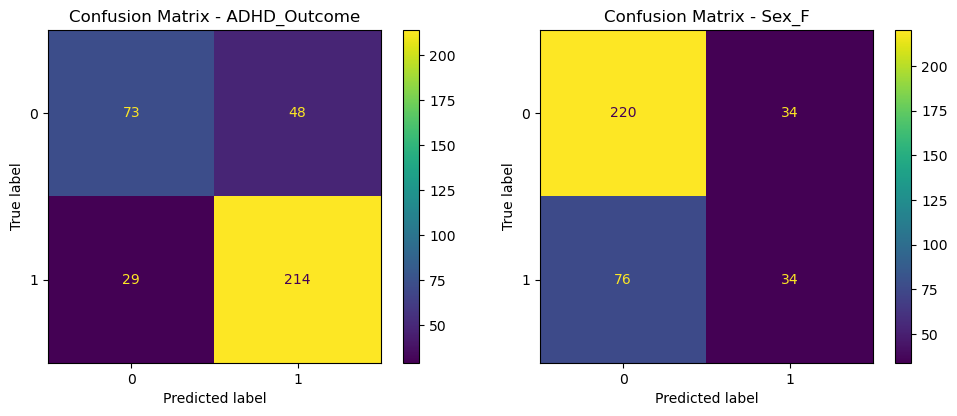

In [558]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

for i, (ax, target_name) in enumerate(zip(axes, y_test.columns)):
    ConfusionMatrixDisplay.from_predictions(
        y_test.iloc[:, i],
        y_pred[:, i],
        ax=ax,
    )
    ax.set_title(f"Confusion Matrix - {target_name}")
    ax.grid(False)

plt.tight_layout()
plt.show()

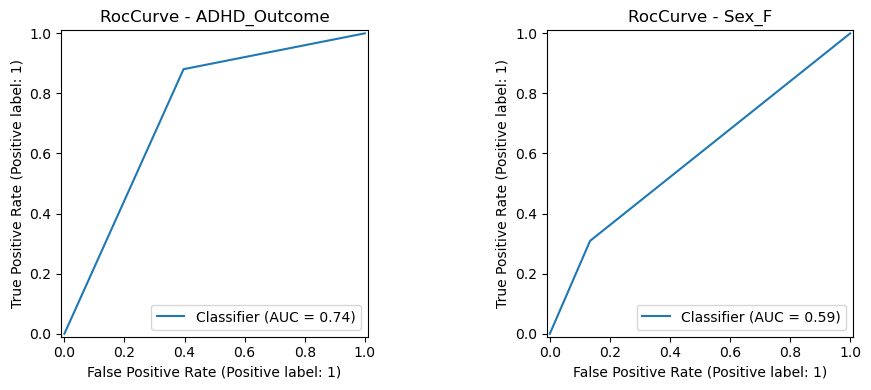

In [559]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

for i, (ax, target_name) in enumerate(zip(axes, y_test.columns)):
    RocCurveDisplay.from_predictions(
        y_test.iloc[:, i],
        y_pred[:, i],
        ax=ax,
    )
    ax.set_title(f"RocCurve - {target_name}")
    ax.grid(False)

plt.tight_layout()
plt.show()

### f1_macro

In [561]:
grid_search = GridSearchCV(multi_log, param_grid, cv=5, scoring='f1_macro', n_jobs=-1, verbose=2)

In [562]:
# Specify the file path where the grid search results are saved
file_path = "Models/feature selection/(grid_search)multi_log_scoring=f1_macro.pkl"

# Check if the file exists
if os.path.exists(file_path):
    print("Model exists")
    # Load the saved GridSearchCV object from the file
    grid_search = joblib.load(file_path)
    print("Model loaded")
else:
    print("Model Does not exist")
    # Start time measurement
    start_time = time.time()

    grid_search.fit(X_train, y_train)
    # End time measurement
    end_time = time.time()
    # Save the GridSearchCV object to a file
    joblib.dump(grid_search, file_path)
    time_taken=end_time-start_time
    print("Model Saved")
    hours, remainder = divmod(time_taken, 3600)
    minutes, seconds = divmod(remainder, 60)

    # Print the result
    print("Time taken: {} hours, {} minutes, {} seconds".format(int(hours), int(minutes), int(seconds)))

Model exists
Model loaded


In [563]:
best_model = grid_search.best_estimator_
best_model

MultiOutputClassifier(estimator=LogisticRegression(C=0.1,
                                                   class_weight='balanced',
                                                   penalty='l1',
                                                   random_state=42,
                                                   solver='liblinear'))

In [564]:
best_model.get_params()

{'estimator__C': 0.1,
 'estimator__class_weight': 'balanced',
 'estimator__dual': False,
 'estimator__fit_intercept': True,
 'estimator__intercept_scaling': 1,
 'estimator__l1_ratio': None,
 'estimator__max_iter': 100,
 'estimator__multi_class': 'auto',
 'estimator__n_jobs': None,
 'estimator__penalty': 'l1',
 'estimator__random_state': 42,
 'estimator__solver': 'liblinear',
 'estimator__tol': 0.0001,
 'estimator__verbose': 0,
 'estimator__warm_start': False,
 'estimator': LogisticRegression(C=0.1, class_weight='balanced', penalty='l1',
                    random_state=42, solver='liblinear'),
 'n_jobs': None}

In [565]:
print("Best score:", grid_search.best_score_)

Best score: 0.665191933025555


In [566]:
# Predict
y_pred = best_model.predict(X_test)

# Loop over each target
for i, target_name in enumerate(y_test.columns):
    print(f"\n--- Classification Report for Target: {target_name} ---")
    print(classification_report(y_test.iloc[:, i], y_pred[:, i]))



--- Classification Report for Target: ADHD_Outcome ---
              precision    recall  f1-score   support

           0       0.59      0.75      0.66       121
           1       0.86      0.74      0.79       243

    accuracy                           0.74       364
   macro avg       0.72      0.75      0.73       364
weighted avg       0.77      0.74      0.75       364


--- Classification Report for Target: Sex_F ---
              precision    recall  f1-score   support

           0       0.78      0.64      0.70       254
           1       0.41      0.58      0.48       110

    accuracy                           0.62       364
   macro avg       0.59      0.61      0.59       364
weighted avg       0.67      0.62      0.63       364



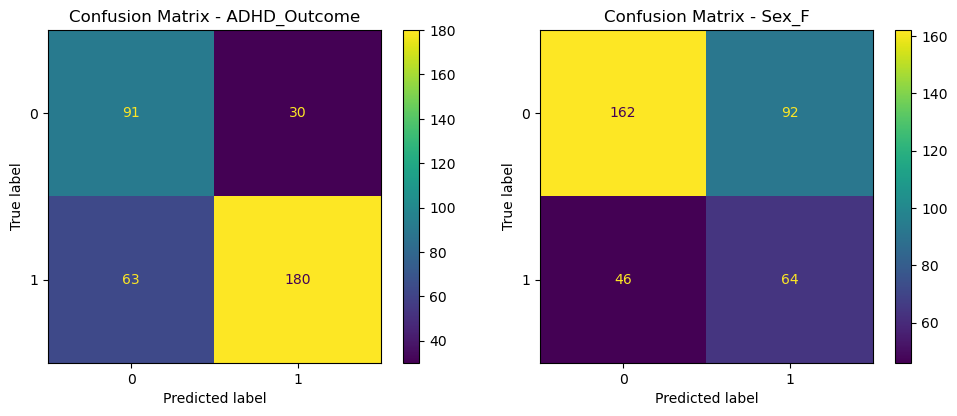

In [567]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

for i, (ax, target_name) in enumerate(zip(axes, y_test.columns)):
    ConfusionMatrixDisplay.from_predictions(
        y_test.iloc[:, i],
        y_pred[:, i],
        ax=ax,
    )
    ax.set_title(f"Confusion Matrix - {target_name}")
    ax.grid(False)

plt.tight_layout()
plt.show()

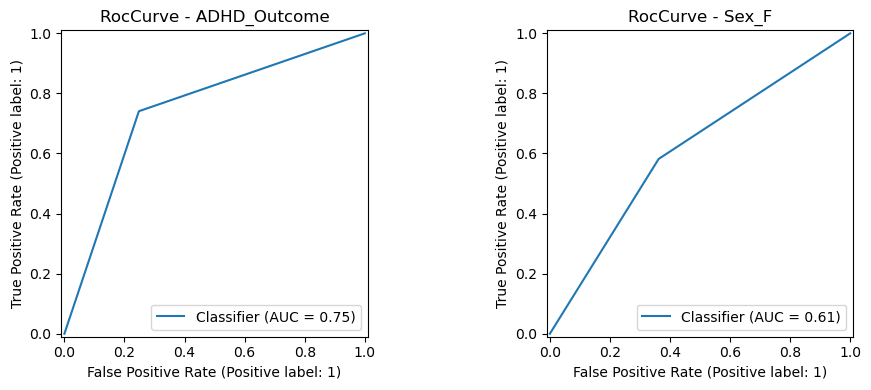

In [568]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

for i, (ax, target_name) in enumerate(zip(axes, y_test.columns)):
    RocCurveDisplay.from_predictions(
        y_test.iloc[:, i],
        y_pred[:, i],
        ax=ax,
    )
    ax.set_title(f"RocCurve - {target_name}")
    ax.grid(False)

plt.tight_layout()
plt.show()

## Neural Networks

- After multiple testing with different metrics (accuracy, multi_output_scorer and f1_macro ) it was decided to continue with only metric which is f1 score. This was based on confusion matrix and ROC curve.

# Testing stuff

## more feaure selection (l2 vs l1)

Retaining the Logestic model on the data after :
1. Filtering using Uinvariate Feature selection.
2. RFE Selection (n_features_to_select=100) using logiestic regression with l2 penality on each label.
3. getting the common features.

In [706]:
Selected_features_l2 = ['PC_701', 'PC_708', 'PC_679', 'PC_275', 'PC_587', 'PC_65', 'PC_552', 'PC_141', 'PC_391', 'PC_452', 'PC_149',
                        'PC_491', 'PC_619', 'PC_403', 'PC_178', 'PC_507', 'PC_240', 'PC_664', 'PC_166', 'PC_350', 'PC_633', 'PC_185',
                        'SDQ_SDQ_Peer_Problems', 'PC_626', 'PC_666', 'PC_609', 'PC_683', 'PC_226', 'PC_651', 'PC_581', 'PC_600',
                        'SDQ_SDQ_Hyperactivity', 'PC_433', 'PC_680', 'PC_305', 'PC_504', 'PC_232', 'PC_604', 'PC_406', 'PC_438',
                        'PC_237', 'PC_285', 'PC_158', 'PC_564', 'PC_563', 'PC_525', 'PC_594', 'PC_411', 'PC_394', 'PC_646', 'PC_422',
                        'PC_181', 'PC_421', 'PC_699', 'PC_270', 'PC_586', 'PC_548', 'PC_412', 'PC_481']

X_filtered_l2 = X_filtered[Selected_features_l2]

In [708]:
len(Selected_features_l2)

59

In [709]:
scaler = StandardScaler()
X_scaled = StandardScaler().fit_transform(X_filtered_l2)
X_scaled_df = pd.DataFrame(X_scaled, columns=X_filtered_l2.columns)

In [710]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.3, random_state=42)
print(f"X_train.shape {X_train.shape}          y_train.shape {y_train.shape} ")
print(f"X_test.shape {X_test.shape}            y_test.shape {y_test.shape} ")

X_train.shape (849, 59)          y_train.shape (849, 2) 
X_test.shape (364, 59)            y_test.shape (364, 2) 


In [711]:
from sklearn.linear_model import LogisticRegression
# Define the model
log_reg = LogisticRegression(solver='liblinear', random_state=42)
multi_log = MultiOutputClassifier(log_reg)

# Define the parameter grid
param_grid = {
    'estimator__penalty': ['l1', 'l2'],
    'estimator__C': [0.001, 0.01, 0.1, 1, 10, 100],  # Regularization strength (lower means stronger regularization)
    'estimator__class_weight': [None, 'balanced']
}
grid_search = GridSearchCV(multi_log, param_grid, cv=5, scoring='f1_macro', n_jobs=-1, verbose=2)

In [716]:
# Specify the file path where the grid search results are saved
file_path = "Models/TEST/(grid_search)multi_log_scoring=f1_macro.pkl"

# Check if the file exists
if os.path.exists(file_path):
    print("Model exists")
    # Load the saved GridSearchCV object from the file
    grid_search = joblib.load(file_path)
    print("Model loaded")
else:
    print("Model Does not exist")
    # Start time measurement
    start_time = time.time()

    grid_search.fit(X_train, y_train)
    # End time measurement
    end_time = time.time()
    # Save the GridSearchCV object to a file
    joblib.dump(grid_search, file_path)
    time_taken=end_time-start_time
    print("Model Saved")
    hours, remainder = divmod(time_taken, 3600)
    minutes, seconds = divmod(remainder, 60)

    # Print the result
    print("Time taken: {} hours, {} minutes, {} seconds".format(int(hours), int(minutes), int(seconds)))

Model Does not exist
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Model Saved
Time taken: 0 hours, 0 minutes, 6 seconds


In [717]:
best_model = grid_search.best_estimator_
best_model

MultiOutputClassifier(estimator=LogisticRegression(C=0.01,
                                                   class_weight='balanced',
                                                   random_state=42,
                                                   solver='liblinear'))

In [718]:
best_model.get_params()

{'estimator__C': 0.01,
 'estimator__class_weight': 'balanced',
 'estimator__dual': False,
 'estimator__fit_intercept': True,
 'estimator__intercept_scaling': 1,
 'estimator__l1_ratio': None,
 'estimator__max_iter': 100,
 'estimator__multi_class': 'auto',
 'estimator__n_jobs': None,
 'estimator__penalty': 'l2',
 'estimator__random_state': 42,
 'estimator__solver': 'liblinear',
 'estimator__tol': 0.0001,
 'estimator__verbose': 0,
 'estimator__warm_start': False,
 'estimator': LogisticRegression(C=0.01, class_weight='balanced', random_state=42,
                    solver='liblinear'),
 'n_jobs': None}

In [719]:
print("Best score:", grid_search.best_score_)

Best score: 0.6421602247015767


In [720]:
# Predict
y_pred = best_model.predict(X_test)

# Loop over each target
for i, target_name in enumerate(y_test.columns):
    print(f"\n--- Classification Report for Target: {target_name} ---")
    print(classification_report(y_test.iloc[:, i], y_pred[:, i]))



--- Classification Report for Target: ADHD_Outcome ---
              precision    recall  f1-score   support

           0       0.56      0.79      0.65       121
           1       0.87      0.69      0.77       243

    accuracy                           0.72       364
   macro avg       0.71      0.74      0.71       364
weighted avg       0.76      0.72      0.73       364


--- Classification Report for Target: Sex_F ---
              precision    recall  f1-score   support

           0       0.73      0.56      0.63       254
           1       0.34      0.53      0.41       110

    accuracy                           0.55       364
   macro avg       0.53      0.54      0.52       364
weighted avg       0.61      0.55      0.56       364



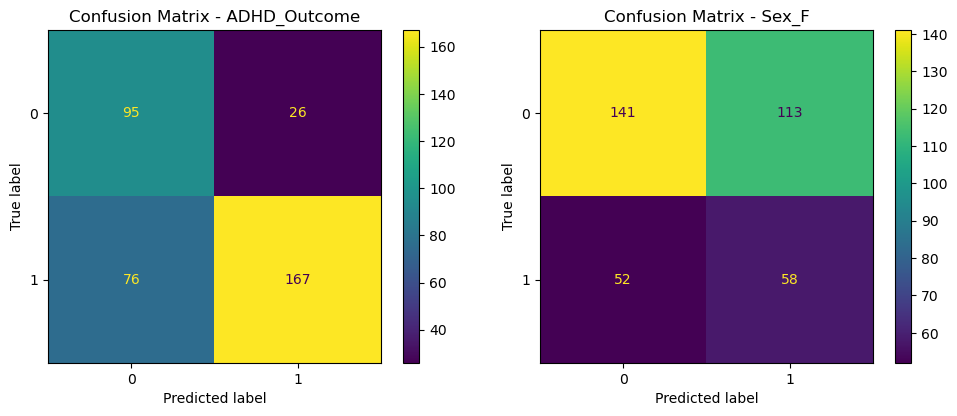

In [721]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

for i, (ax, target_name) in enumerate(zip(axes, y_test.columns)):
    ConfusionMatrixDisplay.from_predictions(
        y_test.iloc[:, i],
        y_pred[:, i],
        ax=ax,
    )
    ax.set_title(f"Confusion Matrix - {target_name}")
    ax.grid(False)

plt.tight_layout()
plt.show()

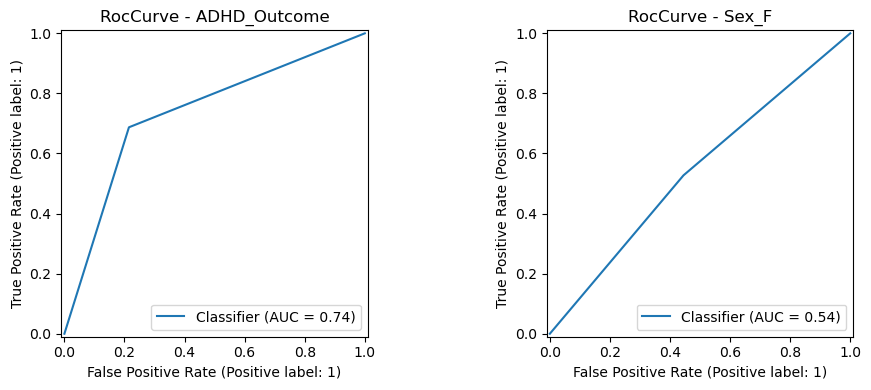

In [722]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

for i, (ax, target_name) in enumerate(zip(axes, y_test.columns)):
    RocCurveDisplay.from_predictions(
        y_test.iloc[:, i],
        y_pred[:, i],
        ax=ax,
    )
    ax.set_title(f"RocCurve - {target_name}")
    ax.grid(False)

plt.tight_layout()
plt.show()

- It gave worse results we will try the features optained from the l1 variation

In [724]:
Selected_features_l1 = ['PC_701', 'PC_708', 'PC_275', 'PC_65', 'PC_552', 'PC_141', 'PC_391', 'PC_452', 'PC_149', 'PC_491',
                        'PC_619', 'PC_403', 'PC_178', 'PC_507', 'PC_240', 'PC_664', 'PC_333', 'PC_124', 'PC_166', 'PC_350',
                        'PC_633', 'PC_185', 'SDQ_SDQ_Peer_Problems', 'PC_626', 'PC_666', 'PC_609', 'PC_683', 'Basic_Demos_Study_Site',
                        'PC_226', 'PC_651', 'PC_581', 'PC_600', 'SDQ_SDQ_Hyperactivity', 'PC_433', 'PC_680', 'PC_305', 'PC_504', 'PC_232',
                        'PC_604', 'PC_406', 'PC_182', 'PC_438', 'PC_285', 'PC_158', 'PC_564', 'PC_243', 'PC_563', 'PC_125', 'PC_525',
                        'PC_594', 'PC_411', 'PC_394', 'PC_646', 'PC_422', 'PC_181', 'PC_421', 'PC_699', 'PC_270', 'PC_586', 'PC_548', 'PC_412', 'PC_481']

X_filtered_l1 = X_filtered[Selected_features_l1]

In [725]:
len(Selected_features_l1)

62

In [726]:
scaler = StandardScaler()
X_scaled = StandardScaler().fit_transform(X_filtered_l1)
X_scaled_df = pd.DataFrame(X_scaled, columns=X_filtered_l1.columns)

In [727]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.3, random_state=42)
print(f"X_train.shape {X_train.shape}          y_train.shape {y_train.shape} ")
print(f"X_test.shape {X_test.shape}            y_test.shape {y_test.shape} ")

X_train.shape (849, 62)          y_train.shape (849, 2) 
X_test.shape (364, 62)            y_test.shape (364, 2) 


In [728]:
from sklearn.linear_model import LogisticRegression
# Define the model
log_reg = LogisticRegression(solver='liblinear', random_state=42)
multi_log = MultiOutputClassifier(log_reg)

# Define the parameter grid
param_grid = {
    'estimator__penalty': ['l1', 'l2'],
    'estimator__C': [0.001, 0.01, 0.1, 1, 10, 100],  # Regularization strength (lower means stronger regularization)
    'estimator__class_weight': [None, 'balanced']
}
grid_search = GridSearchCV(multi_log, param_grid, cv=5, scoring='f1_macro', n_jobs=-1, verbose=2)

In [729]:
# Specify the file path where the grid search results are saved
file_path = "Models/TEST/l1(grid_search)multi_log_scoring=f1_macro.pkl"

# Check if the file exists
if os.path.exists(file_path):
    print("Model exists")
    # Load the saved GridSearchCV object from the file
    grid_search = joblib.load(file_path)
    print("Model loaded")
else:
    print("Model Does not exist")
    # Start time measurement
    start_time = time.time()

    grid_search.fit(X_train, y_train)
    # End time measurement
    end_time = time.time()
    # Save the GridSearchCV object to a file
    joblib.dump(grid_search, file_path)
    time_taken=end_time-start_time
    print("Model Saved")
    hours, remainder = divmod(time_taken, 3600)
    minutes, seconds = divmod(remainder, 60)

    # Print the result
    print("Time taken: {} hours, {} minutes, {} seconds".format(int(hours), int(minutes), int(seconds)))

Model Does not exist
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Model Saved
Time taken: 0 hours, 0 minutes, 0 seconds


In [730]:
best_model = grid_search.best_estimator_
best_model

MultiOutputClassifier(estimator=LogisticRegression(C=0.1,
                                                   class_weight='balanced',
                                                   penalty='l1',
                                                   random_state=42,
                                                   solver='liblinear'))

In [731]:
best_model.get_params()

{'estimator__C': 0.1,
 'estimator__class_weight': 'balanced',
 'estimator__dual': False,
 'estimator__fit_intercept': True,
 'estimator__intercept_scaling': 1,
 'estimator__l1_ratio': None,
 'estimator__max_iter': 100,
 'estimator__multi_class': 'auto',
 'estimator__n_jobs': None,
 'estimator__penalty': 'l1',
 'estimator__random_state': 42,
 'estimator__solver': 'liblinear',
 'estimator__tol': 0.0001,
 'estimator__verbose': 0,
 'estimator__warm_start': False,
 'estimator': LogisticRegression(C=0.1, class_weight='balanced', penalty='l1',
                    random_state=42, solver='liblinear'),
 'n_jobs': None}

In [732]:
print("Best score:", grid_search.best_score_)

Best score: 0.6457620793478589


In [733]:
# Predict
y_pred = best_model.predict(X_test)

# Loop over each target
for i, target_name in enumerate(y_test.columns):
    print(f"\n--- Classification Report for Target: {target_name} ---")
    print(classification_report(y_test.iloc[:, i], y_pred[:, i]))



--- Classification Report for Target: ADHD_Outcome ---
              precision    recall  f1-score   support

           0       0.58      0.79      0.67       121
           1       0.87      0.72      0.79       243

    accuracy                           0.74       364
   macro avg       0.73      0.75      0.73       364
weighted avg       0.78      0.74      0.75       364


--- Classification Report for Target: Sex_F ---
              precision    recall  f1-score   support

           0       0.74      0.55      0.63       254
           1       0.34      0.55      0.42       110

    accuracy                           0.55       364
   macro avg       0.54      0.55      0.52       364
weighted avg       0.62      0.55      0.57       364



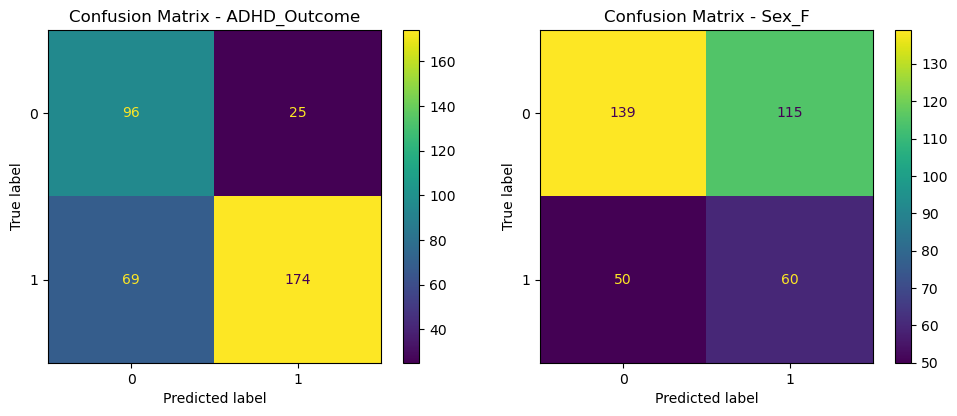

In [734]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

for i, (ax, target_name) in enumerate(zip(axes, y_test.columns)):
    ConfusionMatrixDisplay.from_predictions(
        y_test.iloc[:, i],
        y_pred[:, i],
        ax=ax,
    )
    ax.set_title(f"Confusion Matrix - {target_name}")
    ax.grid(False)

plt.tight_layout()
plt.show()

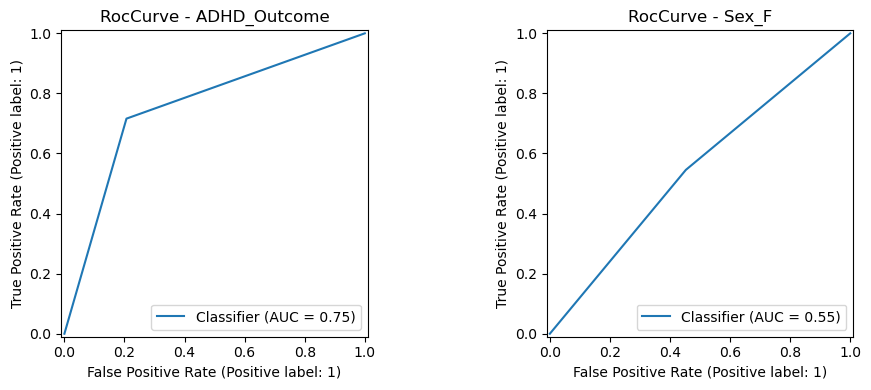

In [735]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

for i, (ax, target_name) in enumerate(zip(axes, y_test.columns)):
    RocCurveDisplay.from_predictions(
        y_test.iloc[:, i],
        y_pred[:, i],
        ax=ax,
    )
    ax.set_title(f"RocCurve - {target_name}")
    ax.grid(False)

plt.tight_layout()
plt.show()

- Almost the same as l2 which are both bad compared to the higher number of feature case in section 6.4

## Using PCA on l1 
To further decrease it into 20 (or more) features

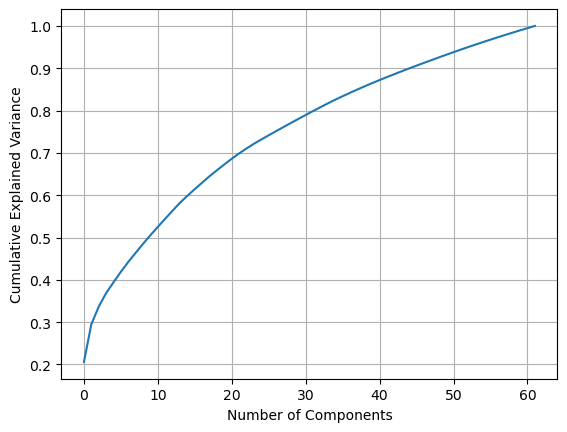

In [755]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

pcal1 = PCA().fit(X_filtered_l1)
plt.plot(np.cumsum(pcal1.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()


In [756]:
pcal1 = PCA(n_components=0.7)  # Keep 75% of the variance
reduced_datal1 = pcal1.fit_transform(X_filtered_l1)
reduced_datal1.shape

(1213, 23)

In [757]:
pca_columns = [f'PC_{i+1}' for i in range(reduced_datal1.shape[1])]

# Convert to DataFrame
reduced_df_l1 = pd.DataFrame(reduced_datal1, columns=pca_columns)
reduced_df_l1

,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,PC_9,PC_10,...,PC_14,PC_15,PC_16,PC_17,PC_18,PC_19,PC_20,PC_21,PC_22,PC_23
0,2.248344,-1.388193,0.381834,1.535272,-0.340566,-0.921497,-0.380419,-0.506140,-0.127379,-0.091261,...,-1.583356,-0.141064,0.206644,-0.545351,-1.507110,0.943138,-0.452443,0.768423,-0.890176,1.042498
1,2.607973,-0.214027,0.171720,-1.012047,-0.705207,-0.013094,1.089705,-0.593721,1.846107,0.142906,...,-0.667019,0.370218,-1.041563,0.719497,-0.586497,-0.472010,-0.851408,0.494090,1.450123,-0.431920
2,3.147391,3.904301,0.334167,-0.823333,-0.739185,-0.272499,0.450397,-0.552380,-0.154507,-0.952851,...,0.666955,-0.197511,0.248083,-1.563225,0.559882,-0.119233,-1.025651,0.342192,-1.336209,-0.649850
3,-2.463011,0.730263,1.148566,-0.600966,0.514570,1.428756,1.009487,0.575715,0.838174,-0.621860,...,0.596581,-0.698733,0.024174,0.713483,-0.115099,0.229267,1.103057,-0.902513,-0.068719,-0.847236
4,2.787892,-2.365106,0.293078,-1.199595,-0.923496,0.446017,0.233799,-0.494275,0.305445,1.106758,...,-0.299868,-0.369007,1.282265,1.027947,1.289219,1.363531,0.539307,-0.414920,1.316174,0.201489
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1208,0.319501,-0.297437,1.746924,-1.225791,0.071918,2.350520,-2.544215,-0.098815,-0.682861,-0.453658,...,-2.294655,-1.081666,0.232654,0.082404,0.279939,-0.256400,0.318323,0.519740,-0.729730,-0.532872
1209,2.048610,0.938613,-0.521314,1.508774,0.148350,1.140147,0.282898,0.158013,-0.319782,-0.085894,...,-0.208938,-1.252042,-0.585277,-0.066854,0.456089,-0.364370,-1.023622,-0.021953,0.408436,0.760971
1210,-0.562848,-0.012257,-0.383651,-0.864344,-1.313019,-0.042653,-0.072391,-0.754579,0.915990,-0.380306,...,-1.627365,0.637786,-0.602077,-0.181036,1.158182,-0.012241,1.174908,0.273285,-0.719726,0.016233
1211,-3.261122,-1.004197,-1.961684,-1.053730,-1.085164,0.136789,0.112580,-1.083440,-1.502446,0.090782,...,-1.679846,0.463239,-0.782417,-0.224849,-0.092717,1.191398,0.745202,0.958442,0.103418,-0.465002


In [758]:
scaler = StandardScaler()
X_scaled = StandardScaler().fit_transform(reduced_df_l1)
X_scaled_df = pd.DataFrame(X_scaled, columns=reduced_df_l1.columns)

In [759]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.3, random_state=42)
print(f"X_train.shape {X_train.shape}          y_train.shape {y_train.shape} ")
print(f"X_test.shape {X_test.shape}            y_test.shape {y_test.shape} ")

X_train.shape (849, 23)          y_train.shape (849, 2) 
X_test.shape (364, 23)            y_test.shape (364, 2) 


In [760]:
from sklearn.linear_model import LogisticRegression
# Define the model
log_reg = LogisticRegression(solver='liblinear', random_state=42)
multi_log = MultiOutputClassifier(log_reg)

# Define the parameter grid
param_grid = {
    'estimator__penalty': ['l1', 'l2'],
    'estimator__C': [0.001, 0.01, 0.1, 1, 10, 100],  # Regularization strength (lower means stronger regularization)
    'estimator__class_weight': [None, 'balanced']
}
grid_search = GridSearchCV(multi_log, param_grid, cv=5, scoring='f1_macro', n_jobs=-1, verbose=2)

In [761]:
# Specify the file path where the grid search results are saved
file_path = "Models/TEST/PCA(grid_search)multi_log_scoring=f1_macro.pkl"

# Check if the file exists
if os.path.exists(file_path):
    print("Model exists")
    # Load the saved GridSearchCV object from the file
    grid_search = joblib.load(file_path)
    print("Model loaded")
else:
    print("Model Does not exist")
    # Start time measurement
    start_time = time.time()

    grid_search.fit(X_train, y_train)
    # End time measurement
    end_time = time.time()
    # Save the GridSearchCV object to a file
    joblib.dump(grid_search, file_path)
    time_taken=end_time-start_time
    print("Model Saved")
    hours, remainder = divmod(time_taken, 3600)
    minutes, seconds = divmod(remainder, 60)

    # Print the result
    print("Time taken: {} hours, {} minutes, {} seconds".format(int(hours), int(minutes), int(seconds)))

Model Does not exist
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Model Saved
Time taken: 0 hours, 0 minutes, 7 seconds


In [762]:
best_model = grid_search.best_estimator_
best_model

MultiOutputClassifier(estimator=LogisticRegression(C=0.1,
                                                   class_weight='balanced',
                                                   penalty='l1',
                                                   random_state=42,
                                                   solver='liblinear'))

In [763]:
best_model.get_params()

{'estimator__C': 0.1,
 'estimator__class_weight': 'balanced',
 'estimator__dual': False,
 'estimator__fit_intercept': True,
 'estimator__intercept_scaling': 1,
 'estimator__l1_ratio': None,
 'estimator__max_iter': 100,
 'estimator__multi_class': 'auto',
 'estimator__n_jobs': None,
 'estimator__penalty': 'l1',
 'estimator__random_state': 42,
 'estimator__solver': 'liblinear',
 'estimator__tol': 0.0001,
 'estimator__verbose': 0,
 'estimator__warm_start': False,
 'estimator': LogisticRegression(C=0.1, class_weight='balanced', penalty='l1',
                    random_state=42, solver='liblinear'),
 'n_jobs': None}

In [764]:
print("Best score:", grid_search.best_score_)

Best score: 0.6536807698781355


In [765]:
# Predict
y_pred = best_model.predict(X_test)

# Loop over each target
for i, target_name in enumerate(y_test.columns):
    print(f"\n--- Classification Report for Target: {target_name} ---")
    print(classification_report(y_test.iloc[:, i], y_pred[:, i]))



--- Classification Report for Target: ADHD_Outcome ---
              precision    recall  f1-score   support

           0       0.56      0.77      0.65       121
           1       0.86      0.70      0.77       243

    accuracy                           0.73       364
   macro avg       0.71      0.74      0.71       364
weighted avg       0.76      0.73      0.73       364


--- Classification Report for Target: Sex_F ---
              precision    recall  f1-score   support

           0       0.76      0.58      0.66       254
           1       0.37      0.57      0.45       110

    accuracy                           0.58       364
   macro avg       0.57      0.58      0.56       364
weighted avg       0.64      0.58      0.60       364



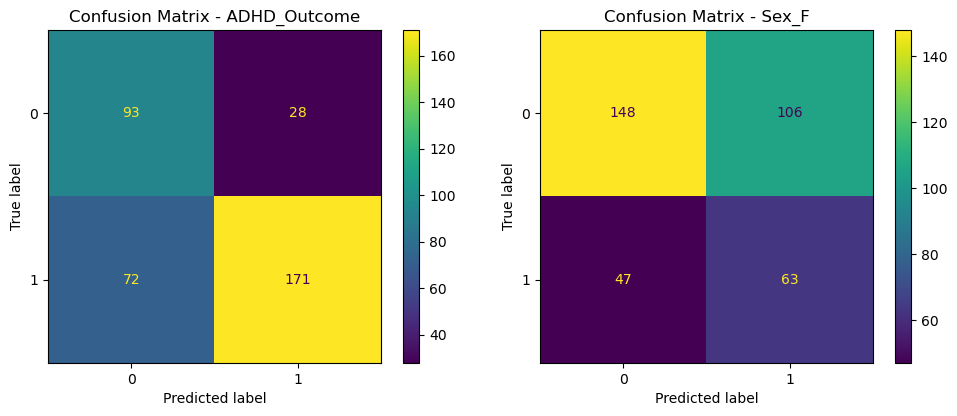

In [766]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

for i, (ax, target_name) in enumerate(zip(axes, y_test.columns)):
    ConfusionMatrixDisplay.from_predictions(
        y_test.iloc[:, i],
        y_pred[:, i],
        ax=ax,
    )
    ax.set_title(f"Confusion Matrix - {target_name}")
    ax.grid(False)

plt.tight_layout()
plt.show()

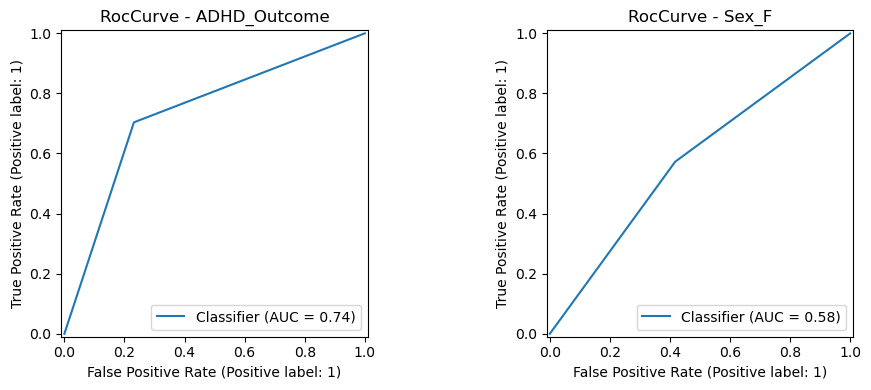

In [767]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

for i, (ax, target_name) in enumerate(zip(axes, y_test.columns)):
    RocCurveDisplay.from_predictions(
        y_test.iloc[:, i],
        y_pred[:, i],
        ax=ax,
    )
    ax.set_title(f"RocCurve - {target_name}")
    ax.grid(False)

plt.tight_layout()
plt.show()

- slight improvement on using l1 only but still worse that sec 6.4 which had more features with less layers of selections

## Using PCA on log_model of section 6.4.3

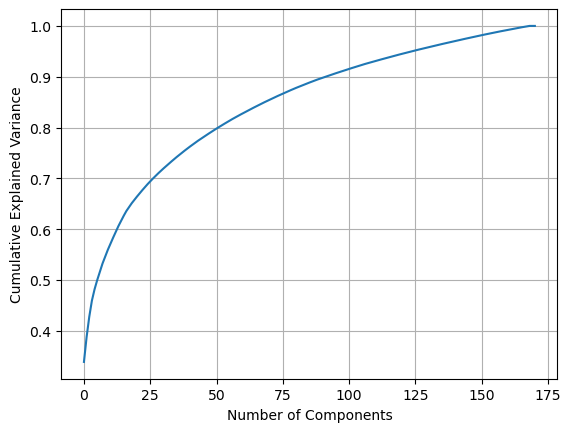

In [784]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

pcal1 = PCA().fit(X_filtered)
plt.plot(np.cumsum(pcal1.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()


In [786]:
pcal1 = PCA(n_components=0.8)  # Keep 75% of the variance
reduced_datal1 = pcal1.fit_transform(X_filtered)
reduced_datal1.shape

(1213, 52)

In [790]:
pca_columns = [f'PC_{i+1}' for i in range(reduced_datal1.shape[1])]

# Convert to DataFrame
reduced_df_l1 = pd.DataFrame(reduced_datal1, columns=pca_columns)
reduced_df_l1

,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,PC_9,PC_10,...,PC_43,PC_44,PC_45,PC_46,PC_47,PC_48,PC_49,PC_50,PC_51,PC_52
0,6.167711,-1.663607,-2.079897,-2.638991,-1.676415,-3.279053,-0.500845,-0.343436,-0.527396,-3.775461,...,-0.073160,-0.307388,-0.653487,-0.049035,1.154426,-2.035602,0.314404,-1.032680,0.863394,-0.976992
1,10.164292,-1.563765,-0.046359,1.092563,1.148533,-0.510116,-1.198562,-1.125034,-2.271198,1.032373,...,1.919629,0.196442,0.350067,-0.123031,0.913274,-0.372673,-0.535407,-0.500489,1.162337,0.522916
2,15.409946,7.556787,2.505819,1.887743,-2.631706,-0.069211,3.000613,-0.979409,1.016139,1.172335,...,-0.285524,-0.841102,0.793153,0.978151,-0.335502,-1.035185,1.360330,0.855953,0.141559,0.398789
3,-9.861136,1.126196,-0.061913,-0.440868,0.332109,0.843398,-3.353536,3.852892,1.342937,1.277529,...,0.510742,-0.722645,-1.110635,1.072076,-0.399872,0.068031,0.871367,0.424805,0.854789,1.065983
4,14.801841,-2.548281,2.898113,2.504928,0.329693,-0.768474,-1.239427,4.627050,-2.156091,0.251017,...,0.395265,1.423326,-0.554601,0.174592,0.552059,-0.891532,-1.627685,0.438174,1.235583,0.301164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1208,-4.421312,-1.341851,-1.521828,-1.874698,0.822164,-0.585464,2.285890,0.044411,-1.158242,0.989938,...,-0.372329,-0.172797,1.951359,1.203527,0.362750,-1.360329,-0.985750,-1.515021,1.287408,-1.419843
1209,3.219112,2.411971,-0.931155,3.253925,-4.367298,0.922521,0.621711,-1.228268,2.326274,2.738593,...,-0.351911,-0.335631,0.228138,-0.539007,1.244770,-0.045156,-0.412252,-0.451004,0.845980,1.459608
1210,-3.356666,1.406577,1.041994,-1.280299,4.001024,-0.962677,-1.645929,0.185012,0.858866,0.229391,...,0.607932,-0.412428,0.548075,-0.589698,1.230056,-0.434745,0.217659,-1.884331,-0.109834,-0.171403
1211,-9.769141,-2.768411,-0.649303,-2.496308,-0.955611,3.001717,-0.796399,-0.067072,-1.336521,1.782543,...,-1.060113,0.468759,0.869333,-0.790076,-0.293849,-1.112704,0.706907,-1.884186,-0.946016,0.176016


In [791]:
scaler = StandardScaler()
X_scaled = StandardScaler().fit_transform(reduced_df_l1)
X_scaled_df = pd.DataFrame(X_scaled, columns=reduced_df_l1.columns)

In [792]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.3, random_state=42)
print(f"X_train.shape {X_train.shape}          y_train.shape {y_train.shape} ")
print(f"X_test.shape {X_test.shape}            y_test.shape {y_test.shape} ")

X_train.shape (849, 52)          y_train.shape (849, 2) 
X_test.shape (364, 52)            y_test.shape (364, 2) 


In [793]:
grid_search = GridSearchCV(multi_log, param_grid, cv=5, scoring='f1_macro', n_jobs=-1, verbose=2)

In [794]:
# Specify the file path where the grid search results are saved
file_path = "Models/TEST/PCA on best model (sec.6.4.3)(grid_search)multi_log_scoring=f1_macro.pkl"

# Check if the file exists
if os.path.exists(file_path):
    print("Model exists")
    # Load the saved GridSearchCV object from the file
    grid_search = joblib.load(file_path)
    print("Model loaded")
else:
    print("Model Does not exist")
    # Start time measurement
    start_time = time.time()

    grid_search.fit(X_train, y_train)
    # End time measurement
    end_time = time.time()
    # Save the GridSearchCV object to a file
    joblib.dump(grid_search, file_path)
    time_taken=end_time-start_time
    print("Model Saved")
    hours, remainder = divmod(time_taken, 3600)
    minutes, seconds = divmod(remainder, 60)

    # Print the result
    print("Time taken: {} hours, {} minutes, {} seconds".format(int(hours), int(minutes), int(seconds)))

Model Does not exist
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Model Saved
Time taken: 0 hours, 0 minutes, 5 seconds


In [795]:
best_model = grid_search.best_estimator_
best_model

MultiOutputClassifier(estimator=LogisticRegression(C=1, class_weight='balanced',
                                                   penalty='l1',
                                                   random_state=42,
                                                   solver='liblinear'))

In [796]:
best_model.get_params()

{'estimator__C': 1,
 'estimator__class_weight': 'balanced',
 'estimator__dual': False,
 'estimator__fit_intercept': True,
 'estimator__intercept_scaling': 1,
 'estimator__l1_ratio': None,
 'estimator__max_iter': 100,
 'estimator__multi_class': 'auto',
 'estimator__n_jobs': None,
 'estimator__penalty': 'l1',
 'estimator__random_state': 42,
 'estimator__solver': 'liblinear',
 'estimator__tol': 0.0001,
 'estimator__verbose': 0,
 'estimator__warm_start': False,
 'estimator': LogisticRegression(C=1, class_weight='balanced', penalty='l1', random_state=42,
                    solver='liblinear'),
 'n_jobs': None}

In [797]:
print("Best score:", grid_search.best_score_)

Best score: 0.6770384653994767


In [798]:
# Predict
y_pred = best_model.predict(X_test)

# Loop over each target
for i, target_name in enumerate(y_test.columns):
    print(f"\n--- Classification Report for Target: {target_name} ---")
    print(classification_report(y_test.iloc[:, i], y_pred[:, i]))



--- Classification Report for Target: ADHD_Outcome ---
              precision    recall  f1-score   support

           0       0.58      0.73      0.64       121
           1       0.84      0.74      0.79       243

    accuracy                           0.73       364
   macro avg       0.71      0.73      0.72       364
weighted avg       0.76      0.73      0.74       364


--- Classification Report for Target: Sex_F ---
              precision    recall  f1-score   support

           0       0.78      0.65      0.71       254
           1       0.42      0.58      0.49       110

    accuracy                           0.63       364
   macro avg       0.60      0.62      0.60       364
weighted avg       0.67      0.63      0.64       364



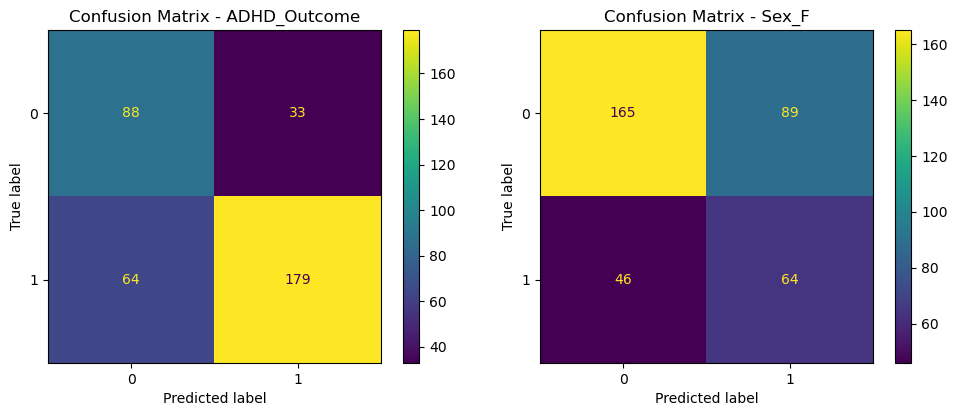

In [799]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

for i, (ax, target_name) in enumerate(zip(axes, y_test.columns)):
    ConfusionMatrixDisplay.from_predictions(
        y_test.iloc[:, i],
        y_pred[:, i],
        ax=ax,
    )
    ax.set_title(f"Confusion Matrix - {target_name}")
    ax.grid(False)

plt.tight_layout()
plt.show()

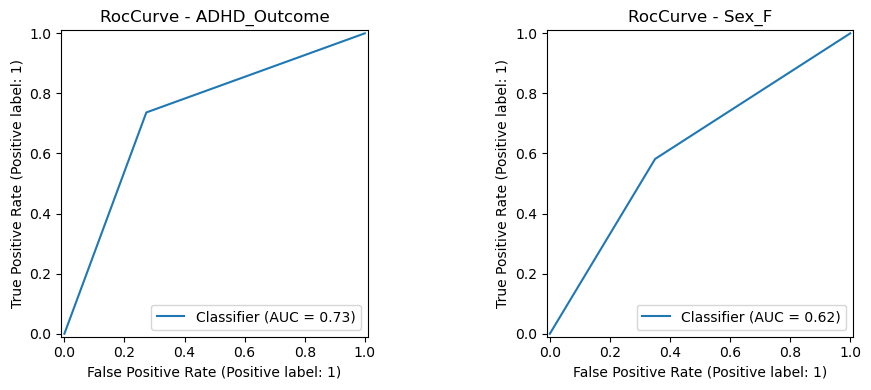

In [800]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

for i, (ax, target_name) in enumerate(zip(axes, y_test.columns)):
    RocCurveDisplay.from_predictions(
        y_test.iloc[:, i],
        y_pred[:, i],
        ax=ax,
    )
    ax.set_title(f"RocCurve - {target_name}")
    ax.grid(False)

plt.tight_layout()
plt.show()

##### PCA =0.7

In [813]:
pcal1 = PCA(n_components=0.7)  # Keep 75% of the variance
reduced_datal1 = pcal1.fit_transform(X_filtered)
reduced_datal1.shape

(1213, 28)

In [814]:
pca_columns = [f'PC_{i+1}' for i in range(reduced_datal1.shape[1])]

# Convert to DataFrame
reduced_df_l1 = pd.DataFrame(reduced_datal1, columns=pca_columns)
reduced_df_l1

,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,PC_9,PC_10,...,PC_19,PC_20,PC_21,PC_22,PC_23,PC_24,PC_25,PC_26,PC_27,PC_28
0,6.167711,-1.663607,-2.079897,-2.638991,-1.676415,-3.279053,-0.500845,-0.343436,-0.527396,-3.775461,...,0.534486,1.807585,-0.493593,-1.205908,1.092036,-0.391575,-0.719957,-0.763381,0.966333,-1.121249
1,10.164292,-1.563765,-0.046359,1.092563,1.148533,-0.510116,-1.198562,-1.125034,-2.271198,1.032373,...,0.319590,-0.472803,0.787796,1.902254,-1.119889,0.343297,0.128715,-0.893874,0.014653,-0.425753
2,15.409946,7.556787,2.505819,1.887743,-2.631706,-0.069211,3.000613,-0.979409,1.016139,1.172335,...,0.326551,-1.390356,-0.154037,-0.806575,0.372175,0.165622,-0.883338,-1.093204,0.043828,1.104003
3,-9.861136,1.126196,-0.061913,-0.440868,0.332109,0.843398,-3.353536,3.852892,1.342937,1.277529,...,0.936256,0.102062,-1.215954,0.482264,-0.110955,-0.036072,1.652543,-0.002034,0.786883,1.143162
4,14.801841,-2.548281,2.898113,2.504928,0.329693,-0.768474,-1.239427,4.627050,-2.156091,0.251017,...,0.502299,-0.425396,-0.789571,0.140041,1.028933,-0.435729,0.360280,0.148884,-1.728554,2.212387
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1208,-4.421312,-1.341851,-1.521828,-1.874698,0.822164,-0.585464,2.285890,0.044411,-1.158242,0.989938,...,1.591719,-0.850692,0.083950,2.948491,0.308008,0.161166,-0.033583,-0.267833,-0.151716,-0.881599
1209,3.219112,2.411971,-0.931155,3.253925,-4.367298,0.922521,0.621711,-1.228268,2.326274,2.738593,...,-0.781088,-0.572631,-1.244258,1.970205,1.623629,-0.179705,-1.158747,-0.072076,0.133823,-1.839339
1210,-3.356666,1.406577,1.041994,-1.280299,4.001024,-0.962677,-1.645929,0.185012,0.858866,0.229391,...,-0.388837,-0.590146,1.382710,1.104712,0.187788,1.631878,-0.363479,-0.577821,-0.610925,0.081721
1211,-9.769141,-2.768411,-0.649303,-2.496308,-0.955611,3.001717,-0.796399,-0.067072,-1.336521,1.782543,...,-1.860883,0.245935,-2.377710,1.280032,1.325126,1.599946,-0.237230,0.218382,-0.116266,1.369070


In [815]:
scaler = StandardScaler()
X_scaled = StandardScaler().fit_transform(reduced_df_l1)
X_scaled_df = pd.DataFrame(X_scaled, columns=reduced_df_l1.columns)

In [816]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.3, random_state=42)
print(f"X_train.shape {X_train.shape}          y_train.shape {y_train.shape} ")
print(f"X_test.shape {X_test.shape}            y_test.shape {y_test.shape} ")

X_train.shape (849, 28)          y_train.shape (849, 2) 
X_test.shape (364, 28)            y_test.shape (364, 2) 


In [817]:
grid_search = GridSearchCV(multi_log, param_grid, cv=5, scoring='f1_macro', n_jobs=-1, verbose=2)

In [818]:
# Specify the file path where the grid search results are saved
file_path = "Models/TEST/PCA=0.7 on best model (sec.6.4.3)(grid_search)multi_log_scoring=f1_macro.pkl"

# Check if the file exists
if os.path.exists(file_path):
    print("Model exists")
    # Load the saved GridSearchCV object from the file
    grid_search = joblib.load(file_path)
    print("Model loaded")
else:
    print("Model Does not exist")
    # Start time measurement
    start_time = time.time()

    grid_search.fit(X_train, y_train)
    # End time measurement
    end_time = time.time()
    # Save the GridSearchCV object to a file
    joblib.dump(grid_search, file_path)
    time_taken=end_time-start_time
    print("Model Saved")
    hours, remainder = divmod(time_taken, 3600)
    minutes, seconds = divmod(remainder, 60)

    # Print the result
    print("Time taken: {} hours, {} minutes, {} seconds".format(int(hours), int(minutes), int(seconds)))

Model Does not exist
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Model Saved
Time taken: 0 hours, 0 minutes, 6 seconds


In [819]:
best_model = grid_search.best_estimator_
best_model

MultiOutputClassifier(estimator=LogisticRegression(C=0.1,
                                                   class_weight='balanced',
                                                   random_state=42,
                                                   solver='liblinear'))

In [820]:
best_model.get_params()

{'estimator__C': 0.1,
 'estimator__class_weight': 'balanced',
 'estimator__dual': False,
 'estimator__fit_intercept': True,
 'estimator__intercept_scaling': 1,
 'estimator__l1_ratio': None,
 'estimator__max_iter': 100,
 'estimator__multi_class': 'auto',
 'estimator__n_jobs': None,
 'estimator__penalty': 'l2',
 'estimator__random_state': 42,
 'estimator__solver': 'liblinear',
 'estimator__tol': 0.0001,
 'estimator__verbose': 0,
 'estimator__warm_start': False,
 'estimator': LogisticRegression(C=0.1, class_weight='balanced', random_state=42,
                    solver='liblinear'),
 'n_jobs': None}

In [821]:
print("Best score:", grid_search.best_score_)

Best score: 0.6664016339787912


In [822]:
# Predict
y_pred = best_model.predict(X_test)

# Loop over each target
for i, target_name in enumerate(y_test.columns):
    print(f"\n--- Classification Report for Target: {target_name} ---")
    print(classification_report(y_test.iloc[:, i], y_pred[:, i]))



--- Classification Report for Target: ADHD_Outcome ---
              precision    recall  f1-score   support

           0       0.59      0.74      0.66       121
           1       0.85      0.74      0.80       243

    accuracy                           0.74       364
   macro avg       0.72      0.74      0.73       364
weighted avg       0.77      0.74      0.75       364


--- Classification Report for Target: Sex_F ---
              precision    recall  f1-score   support

           0       0.80      0.67      0.73       254
           1       0.44      0.62      0.52       110

    accuracy                           0.65       364
   macro avg       0.62      0.64      0.62       364
weighted avg       0.69      0.65      0.66       364



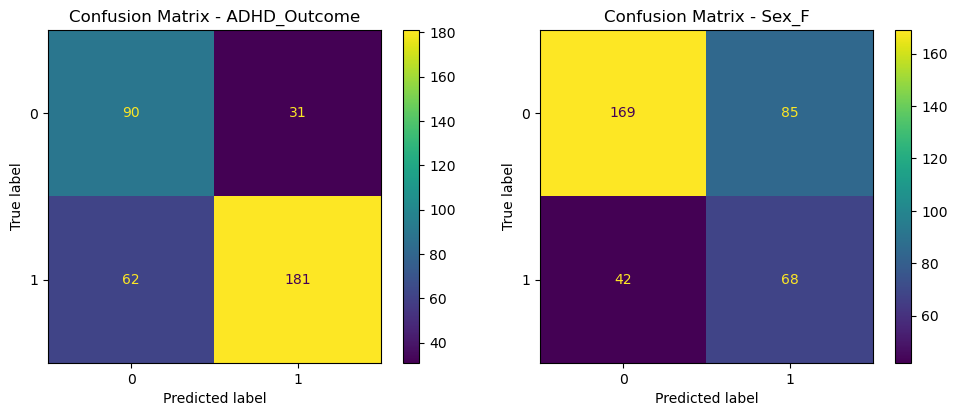

In [823]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

for i, (ax, target_name) in enumerate(zip(axes, y_test.columns)):
    ConfusionMatrixDisplay.from_predictions(
        y_test.iloc[:, i],
        y_pred[:, i],
        ax=ax,
    )
    ax.set_title(f"Confusion Matrix - {target_name}")
    ax.grid(False)

plt.tight_layout()
plt.show()

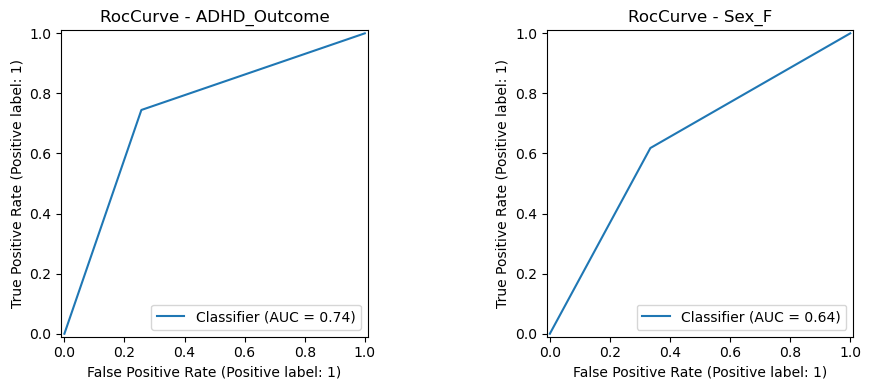

In [824]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

for i, (ax, target_name) in enumerate(zip(axes, y_test.columns)):
    RocCurveDisplay.from_predictions(
        y_test.iloc[:, i],
        y_pred[:, i],
        ax=ax,
    )
    ax.set_title(f"RocCurve - {target_name}")
    ax.grid(False)

plt.tight_layout()
plt.show()